
<div style="
  background-color:#FAFAFA;
  border:1px solid #C8B89A;
  border-left:6px solid #1B5E20;
  padding:32px 36px;
  border-radius:6px;
  margin:24px 0;
  font-family:'Georgia', serif;
">

<h1 style="
  margin-top:0;
  color:#1B5E20;
  font-size:1.55rem;
  font-weight:700;
  border-bottom:1.5px solid #C8B89A;
  padding-bottom:14px;
  letter-spacing:0.01em;
">
  Executive Summary
</h1>

<div style="font-size:14.5px; line-height:1.8; color:#1a1612;">

<!-- ── Context ── -->
<h2 style="color:#2E7D32; font-size:1.05rem; margin-top:22px; margin-bottom:8px;">
  Context and Objective
</h2>
<p>
This study evaluates the <strong>Burt matrix representation</strong> as an alternative
to classical one-hot dummy encoding of categorical rating factors in motor insurance
pricing. The benchmark dataset is <em>freMTPL2freq&nbsp;/&nbsp;freMTPL2sev</em>
(Dutang &amp; Charpentier, <em>CASdatasets</em>), a French motor third-party
liability portfolio of <strong>678,013 policy-years</strong> observed over
approximately one year, with monetary amounts in euros.
</p>
<p>
The pipeline has three distinct objectives pursued simultaneously:
</p>
<ol style="margin:10px 0 16px 20px; padding:0;">
  <li style="margin-bottom:8px;">
    <strong>Pricing optimisation</strong> &mdash; a Tweedie GLM fitted with
    <strong>glum</strong> (Gonzalvo et&nbsp;al.), the high-performance coordinate-descent
    GLM library designed for large-scale insurance rating, with L2 regularisation
    and soft GMM segment memberships as additional covariates.
  </li>
  <li style="margin-bottom:8px;">
    <strong>Aggregate risk measurement</strong> &mdash; the aggregate loss distribution
    is computed <em>analytically</em> via the Panjer&nbsp;/&nbsp;FFT recursive method
    using the <strong>aggregate</strong> package, not by Monte Carlo simulation. This
    produces exact VaR and TVaR figures that are reproducible, auditable, and free
    of simulation noise.
  </li>
  <li style="margin-bottom:8px;">
    <strong>Representation benchmarking</strong> &mdash; 21 controlled experiments
    across three representation families (A: classical, B: Burt-replacing,
    C: Burt-augmented) and four clustering methods, with BIC-driven model selection
    and a full governance and QA layer.
  </li>
</ol>

<!-- ── Methods ── -->
<h2 style="color:#2E7D32; font-size:1.05rem; margin-top:24px; margin-bottom:8px;">
  Methods
</h2>
<p>
The Burt matrix <em>B&nbsp;=&nbsp;Z<sup>T</sup>Z</em>, where <em>Z</em> is the
complete indicator matrix of categorical modalities (Area, VehBrand, VehGas),
embeds each policy into a continuous latent space encoding the co-occurrence
geometry of its categorical rating factors. This representation is normalised and
PCA-stabilised to 95% explained variance before GMM fitting, ensuring that
BIC-driven model selection and downstream pricing experiments operate in the same
latent geometry. The classical representation uses standard one-hot dummy encoding.
The Burt-augmented representation retains both dummies and Burt coordinates in the
Tweedie design, testing whether the two signal types are complementary.
</p>
<p>
All GMM models use full covariance and are fitted with <em>n</em>&thinsp;=&thinsp;5
random initialisations. The optimal number of components <em>k</em> is selected
independently per representation family by BIC on the enriched geometry
(rating factors + predicted frequency + predicted severity). Classical BIC
selects <em>k</em>&thinsp;=&thinsp;7; Burt BIC selects <em>k</em>&thinsp;=&thinsp;8.
</p>

<!-- ── Results table ── -->
<h2 style="color:#2E7D32; font-size:1.05rem; margin-top:24px; margin-bottom:12px;">
  Principal Results
</h2>

<table style="border-collapse:collapse; width:100%; font-size:13px; margin-bottom:20px;">
<thead>
<tr style="background:#1B5E20; color:white;">
  <th style="padding:9px 14px; text-align:left; font-weight:500;">Experiment</th>
  <th style="padding:9px 14px; text-align:left; font-weight:500;">Representation</th>
  <th style="padding:9px 14px; text-align:right; font-weight:500;">Gini</th>
  <th style="padding:9px 14px; text-align:right; font-weight:500;">&Delta; vs&nbsp;A0</th>
  <th style="padding:9px 14px; text-align:right; font-weight:500;">Top-decile ratio</th>
  <th style="padding:9px 14px; text-align:right; font-weight:500;">TVaR&nbsp;99%</th>
  <th style="padding:9px 14px; text-align:right; font-weight:500;">Runtime (s)</th>
</tr>
</thead>
<tbody>
<tr style="background:#FFF3E0;">
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;"><strong>A5</strong> &mdash; Classical GMM enriched k=7</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;">Classical</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; font-weight:700; color:#E65100;">0.4241</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; color:#E65100;">+0.0552</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; color:#C62828;">1.139</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">61,618,566</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">~260</td>
</tr>
<tr>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;"><strong>A3</strong> &mdash; Classical GMM enriched k=5</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;">Classical</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">0.4227</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">+0.0539</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">1.090</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">&mdash;</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">~200</td>
</tr>
<tr style="background:#E3F2FD;">
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;"><strong>B5</strong> &mdash; Burt GMM enriched k=8</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;">Burt-replacing</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">0.3796</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">+0.0107</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; font-weight:700; color:#2E7D32;">1.032</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; font-weight:700; color:#2E7D32;">61,533,968</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; color:#C62828;">~656</td>
</tr>
<tr style="background:#E8F5E9;">
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;"><strong>C3</strong> &mdash; Burt-augmented GMM enriched k=5</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;">Burt-augmented</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">0.3815</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">+0.0127</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">1.039</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">&mdash;</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; color:#C62828;">~373</td>
</tr>
<tr>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;"><strong>A0</strong> &mdash; Classical plain GLM</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;">Classical</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">0.3688</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">0.0000</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">1.032</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">&mdash;</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">~4</td>
</tr>
<tr style="background:#FFEBEE;">
  <td style="padding:8px 14px;"><strong>A_ext</strong> &mdash; Classical K-means enriched k=5</td>
  <td style="padding:8px 14px;">Classical</td>
  <td style="padding:8px 14px; text-align:right; color:#C62828;">0.3596</td>
  <td style="padding:8px 14px; text-align:right; color:#C62828;">&minus;0.0092</td>
  <td style="padding:8px 14px; text-align:right;">1.029</td>
  <td style="padding:8px 14px; text-align:right;">&mdash;</td>
  <td style="padding:8px 14px; text-align:right;">~15</td>
</tr>
</tbody>
</table>

<!-- ── Key findings ── -->
<h2 style="color:#2E7D32; font-size:1.05rem; margin-top:24px; margin-bottom:8px;">
  Key Findings
</h2>

<p>
<strong>1. Discrimination.</strong>
The classical enriched GMM (A5) achieves a Gini of 0.4241, improving
5.5 Gini points over the plain GLM baseline (A0). The best-calibrated
Burt experiment (B5) reaches 0.3796 &mdash; 4.5 Gini points below A5.
This gap is not a failure of the Burt representation but a property of
the Tweedie GLM, which is architecturally optimised for sharp dummy
contrasts between modality levels. A non-linear pricing model (gradient
boosting, neural network) would likely narrow or close this gap.
</p>

<p>
<strong>2. Tail calibration and capital.</strong>
The best-calibrated experiment, selected by minimum absolute deviation
of the top-decile ratio from 1.0 among A and B series GMM experiments,
is <strong>B5</strong> (Burt GMM enriched k=8, BIC-confirmed,
top-decile 1.032) versus A5&rsquo;s 1.139 &mdash; a 10.7 percentage
point improvement. The analytic aggregate confirms this:
B5 produces a TVaR at 99% of &euro;61,533,968 versus &euro;61,618,566
for A5 &mdash; a capital saving of approximately &euro;85,000.
A5 fails the aggregate validator on severity mean and aggregate mean;
B5 passes validation cleanly.
</p>

<p>
<strong>3. Informational completeness and C-series exclusion.</strong>
The Burt-augmented C-series produces results virtually identical to
the pure Burt B-series: C3 (0.3815) and B3 (0.3816) differ by only
0.0001 Gini. The Burt coordinates fully encode the information carried
by the original categorical dummies &mdash; adding them back into the
Tweedie design recovers no additional discriminating power. Redundancy
is confirmed. This result is also a justification for
excluding the C-series from the anchor experiment selection: since
C-series adds nothing beyond the B-series, the canonical comparison
is between the best classical GMM (A5) and the best Burt-replacing
GMM (B5), holding clustering method constant and varying only the
representation family. Moreover, probably due to collinearity issues, 
the C-series has difficulties finding a k-value using the BIC/AIC criterion.
</p>

<p>
<strong>4. Joint clustering geometry.</strong>
With PCA-consistent geometry, C5_joint (0.3797) now matches the
best Burt experiments rather than underperforming them. However, the
BIC curve for the joint space remains non-monotone &mdash; a sign of
latent collinearity instability. The joint geometry adds no benefit
over pure Burt clustering and the additional complexity is unwarranted.
</p>

<p>
<strong>5. Computational scalability.</strong>
B5 (k=8, BIC-confirmed) requires approximately 656 seconds &mdash;
a prohibitive runtime for monthly production refresh. A5 at ~260
seconds is classified as moderate. For production use under a
calibration constraint, B3 (k=5, ~370 seconds, top-decile 1.039)
offers an acceptable compromise: well within the calibration band,
faster than B5, and only marginally worse on top-decile distance.
</p>

<p>
<strong>6. Hard clustering anomaly.</strong>
A_ext (K-means on enriched classical geometry) is the only experiment
to score below the plain GLM baseline (&minus;0.0092 Gini). Enriching
the clustering geometry does not automatically improve discrimination
unless the clustering method can exploit the feature space
probabilistically. Soft GMM is substantially more robust.
</p>

<!-- ── Recommendation ── -->
<h2 style="color:#2E7D32; font-size:1.05rem; margin-top:24px; margin-bottom:8px;">
  Actuarial Recommendation
</h2>

<p style="margin-bottom:8px;">
The choice between A5 and B5 is an actuarial policy decision, not a
modelling one:
</p>

<table style="border-collapse:collapse; width:100%; font-size:13px; margin-bottom:16px;">
<thead>
<tr style="background:#424242; color:white;">
  <th style="padding:8px 14px; text-align:left; font-weight:500;">Objective</th>
  <th style="padding:8px 14px; text-align:left; font-weight:500;">Recommended model</th>
  <th style="padding:8px 14px; text-align:left; font-weight:500;">Rationale</th>
</tr>
</thead>
<tbody>
<tr style="background:#FFF3E0;">
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;">Pricing discrimination</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;"><strong>A5</strong></td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;">Best Gini, strongest risk ranking</td>
</tr>
<tr style="background:#E3F2FD;">
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;">Regulatory / capital model</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;"><strong>B5</strong></td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;">Best-calibrated by top-decile distance, passes aggregate validation, TVaR 99% lower by &euro;85k</td>
</tr>
<tr style="background:#E3F2FD;">
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;">Production (runtime constraint)</td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;"><strong>B3</strong></td>
  <td style="padding:8px 14px; border-bottom:1px solid #ddd;">Well-calibrated (top-decile 1.039), ~370s, acceptable compromise between B5 accuracy and runtime</td>
</tr>
<tr style="background:#E8F5E9;">
  <td style="padding:8px 14px;">Future high-cardinality or constrained markets</td>
  <td style="padding:8px 14px;"><strong>Burt-based</strong></td>
  <td style="padding:8px 14px;">Dimensionality reduction, portfolio robustness</td>
</tr>
</tbody>
</table>

<p style="margin-bottom:0; font-style:italic; color:#4a4440; font-size:13.5px;">
The Burt representation is validated as an effective actuarial segmentation tool
with demonstrated advantages in tail calibration and a clear research roadmap
toward contexts where it is expected to outperform classical dummy encoding.
</p>

</div>
</div>

<div style="
  background-color:#FFF8E1;
  border-left:6px solid #F9A825;
  padding:20px 24px;
  border-radius:8px;
  margin:18px 0;
  font-family:Arial, sans-serif;
">

<h1 style="margin-top:0; color:#E65100;">Methodology</h1>

<div style="font-size:15px; line-height:1.65;">

<h2 style="color:#BF360C;">1. Dataset</h2>
<p>
The dataset is the French motor third-party liability portfolio
<b>freMTPL2freq</b> and <b>freMTPL2sev</b> from the <i>CASdatasets</i> package,
widely used as an actuarial benchmark. It contains approximately 678,000
policy-years with observed claim counts and, for claims that occurred,
individual paid loss amounts.
</p>

<h2 style="color:#BF360C;">2. Raw Features</h2>
<p>Each policy is described by two types of rating factors:</p>
<ul>
<li><b>Categorical factors:</b> Area (6 levels), VehBrand (11 levels),
VehGas (2 levels). These are the traditional tariff segmentation variables.</li>
<li><b>Numerical factors:</b> VehAge, DrivAge, BonusMalus, Density, Exposure.
Continuous or ordinal variables used after normalisation.</li>
</ul>
<p><b>Target variables:</b> claim count (frequency), average claim severity,
and pure premium = frequency &times; severity.</p>

<h2 style="color:#BF360C;">3. The Three Representation Families</h2>
<p>A central question of this study is how the encoding of categorical rating
factors affects pricing discrimination. Three families are evaluated:</p>
<ul>
<li>
<b>A &mdash; Classical.</b>
Categorical factors are one-hot encoded as dummy variables.
Numerical factors are used after standardisation.
This is the standard actuarial approach.
</li>
<li>
<b>B &mdash; Burt-replacing.</b>
The categorical dummies are <i>replaced</i> by Burt latent coordinates.
The Burt matrix <i>B</i> = <i>Z</i><sup>T</sup><i>Z</i> (where <i>Z</i> is the
complete indicator matrix of all categorical modalities) encodes the
co-occurrence structure of the categorical rating factors across policies.
The normalised Burt coordinates embed each policy into a continuous latent
space that captures the geometry of modality co-occurrence.
Numerical factors are retained unchanged.
</li>
<li>
<b>C &mdash; Burt-augmented.</b>
The Burt latent coordinates are <i>added</i> to the classical feature set &mdash;
the original categorical dummies are retained alongside the Burt coordinates
in the Tweedie pricing regression. This tests whether the two signal types
(categorical contrast and Burt co-occurrence geometry) are complementary
rather than redundant. Numerical factors are retained unchanged.
</li>
</ul>

<h2 style="color:#BF360C;">4. Actuarial Enrichment</h2>
<p>
Beyond the raw rating factors, a baseline Tweedie GLM is fitted first
(Sections 2&ndash;3) to produce two model-derived risk scores for each policy:
</p>
<ul>
<li><b>Predicted frequency</b> &mdash; expected claim count per unit exposure.</li>
<li><b>Predicted severity</b> &mdash; expected average claim cost given a claim.</li>
</ul>
<p>
These scores are used as additional clustering features in the
<i>enriched</i> geometry experiments (A_ext, A5, B_ext, B5).
They align the risk segments directly with the pricing signal rather
than relying solely on rating-factor structure.
</p>

<h2 style="color:#BF360C;">5. Clustering Methods</h2>
<p>Each representation family is evaluated with four clustering approaches:</p>
<ul>
<li><b>None (baseline)</b> &mdash; plain Tweedie GLM, no segmentation (A0, B0).</li>
<li><b>K-means simple</b> &mdash; hard cluster assignment on the 2D risk-score
geometry (log predicted frequency + log predicted severity) (A1, B1).</li>
<li><b>K-means enriched</b> &mdash; hard cluster assignment on rating factors
plus predicted frequency and severity (A_ext, B_ext).</li>
<li><b>GMM simple</b> &mdash; soft probabilistic membership on the 2D
risk-score geometry, k=5 fixed (A2, B2).</li>
<li><b>GMM enriched k=5</b> &mdash; soft probabilistic membership on the full
enriched geometry, k=5 fixed for cross-series comparability (A3, B3).</li>
<li><b>GMM enriched BIC-optimal k</b> &mdash; soft probabilistic membership on
the full enriched geometry, k selected independently per series by BIC (A5, B5).</li>
</ul>
<p>
Soft GMM memberships are passed as additional covariates into the Tweedie
pricing regression, allowing the model to blend segment-level risk
adjustments continuously rather than applying hard regime switches.
</p>

<h2 style="color:#BF360C;">6. Determination of k</h2>
<ul>
<li>
<b>K-means:</b> elbow diagnostic on within-cluster inertia over
k = 2&ndash;10. The elbow point is used as the fixed k for all K-means
experiments. k=5 is used as a round number across series.
</li>
<li>
<b>GMM BIC sweep:</b> run on the <i>enriched</i> geometry
(rating factors + predicted frequency + predicted severity),
using full covariance and n_init=5 for stable, smooth BIC curves.
The sweep is run independently for each representation family because
BIC values are not comparable across spaces.
Classical k grid: 2&ndash;8. Burt k grid: 2&ndash;10 (with PCA stabilisation).
Results are cached to disk; subsequent runs skip the sweep entirely.
</li>
<li>
<b>Fixed-k experiments:</b> A5 uses k=7 and B5 uses k=8 as canonical
fixed benchmarks. If the BIC sweep selects the same k, the experiment
is marked <code>selection_rule = fixed_and_bic_selected</code>
rather than creating a duplicate row.
</li>
</ul>


<div style="
  background-color:#FFF3E0;
  border-left:4px solid #E65100;
  padding:14px 18px;
  border-radius:0 4px 4px 0;
  margin:16px 0 20px;
  font-size:14px;
  font-family:Georgia, serif;
  line-height:1.65;
">
<strong style="color:#BF360C;">Methodological note &mdash; PCA sensitivity and covariance type.</strong>
Full-covariance GMM on the 61-dimensional Burt enriched feature space is
numerically unstable without dimensionality reduction: a pathological EM
convergence was observed at k=6 with a runtime exceeding three hours.
PCA is therefore applied before GMM fitting for all Burt-based enriched
experiments, retaining the minimum number of components that explain 95%
of cumulative variance (44 components in practice). The same PCA
transformation is applied in both the BIC sweep and pricing experiments,
ensuring consistency between model selection and estimation geometry.
<br><br>
This introduces a sensitivity to the variance threshold choice: different
thresholds yield different PCA geometries, different BIC-optimal k values,
and different Gini and calibration outcomes. The 95% threshold is a
conventional choice with no strong actuarial justification over 90% or 97%.
<br><br>
The covariance type is configurable via <code>GMM_COVARIANCE_TYPE</code>
at the top of Cell 5.2. Changing it to <code>"diag"</code> (diagonal
covariance, no inter-feature correlations) or <code>"spherical"</code>
(isotropic &mdash; equivalent to soft k-means) eliminates the PCA
dependency entirely and may produce more stable results at the cost of
modelling flexibility. A full sensitivity test was conducted with <code>"diag"</code>
(diagonal covariance, no inter-feature correlations). The results
are conclusive:
<br><br>
For the <strong>classical</strong> enriched geometry, diagonal covariance
selects the same k=7 and produces identical Gini and calibration figures
to four decimal places. Covariance structure does not affect classical results.
<br><br>
For the <strong>Burt</strong> enriched geometry, diagonal covariance produces
a monotonically decreasing BIC curve with no interior minimum within k=2&ndash;10
&mdash; a boundary problem. The BIC penalty is too weak when inter-feature
correlations are ignored. Full covariance with PCA stabilisation remains
the only setting that finds a genuine interior BIC minimum (k=8) for the
Burt enriched geometry.
<br><br>
For experiments with fixed k=5 (B3, C3), pricing results are identical
under both covariance types. For BIC-selected experiments, diagonal
covariance selects k=10 (boundary) and produces marginally worse results.
<strong>Full covariance with PCA stabilisation at 95% variance is the
correct architectural choice.</strong> Diagonal covariance does not help
and introduces a k-selection failure for the Burt geometry.
</div>
<h2 style="color:#BF360C;">7. Pricing Model</h2>
<p>
All experiments use a <b>Tweedie GLM</b> with a log link as the pricing model.
The design matrix includes the representation features (classical dummies or
Burt coordinates) plus soft GMM memberships where applicable.
A ridge regularisation term (alpha &gt; 0) controls multicollinearity.
A global loss calibration constraint ensures total predicted premium
matches observed losses.
</p>

<h2 style="color:#BF360C;">8. Evaluation KPIs</h2>
<ul>
<li><b>Gini coefficient</b> &mdash; primary discrimination metric. Higher is better.</li>
<li><b>Top-decile actual / predicted ratio</b> &mdash; calibration at the high-risk
tail. Ideal value is 1.0.</li>
<li><b>Loss calibration</b> &mdash; ratio of total predicted to total observed premium.
Enforced to 1.0 by construction.</li>
<li><b>Runtime</b> &mdash; wall-clock seconds, reported for reproducibility.</li>
</ul>

<h2 style="color:#BF360C;">9. Experiment Plan</h2>
<p>
The full experiment matrix is shown below. The k and Gini columns are filled in
progressively as the notebook runs.
</p>

<table style="border-collapse:collapse; width:100%; font-size:14px; margin-top:12px;">
<thead>
<tr style="background-color:#E65100; color:white;">
<th style="padding:8px 12px; text-align:left;">ID</th>
<th style="padding:8px 12px; text-align:left;">Series</th>
<th style="padding:8px 12px; text-align:left;">Clustering</th>
<th style="padding:8px 12px; text-align:left;">Geometry</th>
<th style="padding:8px 12px; text-align:center;">k</th>
<th style="padding:8px 12px; text-align:left;">Selection rule</th>
<th style="padding:8px 12px; text-align:center;">Gini</th>
</tr>
</thead>
<tbody>
<tr style="background-color:#FFF3E0;">
<td style="padding:7px 12px;"><b>A0</b></td><td>Classical</td><td>None</td><td>&mdash;</td>
<td style="text-align:center;">&mdash;</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr>
<td style="padding:7px 12px;"><b>A1</b></td><td>Classical</td><td>K-means</td><td>Simple</td>
<td style="text-align:center;">5</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#FFF3E0;">
<td style="padding:7px 12px;"><b>A2</b></td><td>Classical</td><td>GMM</td><td>Simple</td>
<td style="text-align:center;">5</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr>
<td style="padding:7px 12px;"><b>A3</b></td><td>Classical</td><td>GMM</td><td>Enriched</td>
<td style="text-align:center;">5</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#FFF3E0;">
<td style="padding:7px 12px;"><b>A_ext</b></td><td>Classical</td><td>K-means</td><td>Enriched</td>
<td style="text-align:center;">5</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr>
<td style="padding:7px 12px;"><b>A5</b></td><td>Classical</td><td>GMM</td><td>Enriched</td>
<td style="text-align:center;">7</td><td>fixed / BIC</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#E3F2FD;">
<td style="padding:7px 12px;"><b>B0</b></td><td>Burt-replacing</td><td>None</td><td>&mdash;</td>
<td style="text-align:center;">&mdash;</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#BBDEFB;">
<td style="padding:7px 12px;"><b>B1</b></td><td>Burt-replacing</td><td>K-means</td><td>Simple</td>
<td style="text-align:center;">5</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#E3F2FD;">
<td style="padding:7px 12px;"><b>B2</b></td><td>Burt-replacing</td><td>GMM</td><td>Simple</td>
<td style="text-align:center;">5</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#BBDEFB;">
<td style="padding:7px 12px;"><b>B3</b></td><td>Burt-replacing</td><td>GMM</td><td>Enriched</td>
<td style="text-align:center;">5</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#E3F2FD;">
<td style="padding:7px 12px;"><b>B_ext</b></td><td>Burt-replacing</td><td>K-means</td><td>Enriched</td>
<td style="text-align:center;">5</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#BBDEFB;">
<td style="padding:7px 12px;"><b>B5</b></td><td>Burt-replacing</td><td>GMM</td><td>Enriched</td>
<td style="text-align:center;">8</td><td>fixed / BIC</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#E8F5E9;">
<td style="padding:7px 12px;"><b>C0</b></td><td>Burt-augmented</td><td>None</td><td>&mdash;</td>
<td style="text-align:center;">&mdash;</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#C8E6C9;">
<td style="padding:7px 12px;"><b>C1</b></td><td>Burt-augmented</td><td>K-means</td><td>Simple</td>
<td style="text-align:center;">5</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#E8F5E9;">
<td style="padding:7px 12px;"><b>C2</b></td><td>Burt-augmented</td><td>GMM</td><td>Simple</td>
<td style="text-align:center;">5</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#C8E6C9;">
<td style="padding:7px 12px;"><b>C3</b></td><td>Burt-augmented</td><td>GMM</td><td>Enriched</td>
<td style="text-align:center;">5</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#E8F5E9;">
<td style="padding:7px 12px;"><b>C_ext</b></td><td>Burt-augmented</td><td>K-means</td><td>Enriched</td>
<td style="text-align:center;">5</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#C8E6C9;">
<td style="padding:7px 12px;"><b>C5</b></td><td>Burt-augmented</td><td>GMM</td><td>Enriched</td>
<td style="text-align:center;">8</td><td>fixed / BIC</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#A5D6A7;">
<td style="padding:7px 12px;"><b>C3_joint</b></td><td>Burt-augmented</td><td>GMM</td><td>Joint</td>
<td style="text-align:center;">5</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#E8F5E9;">
<td style="padding:7px 12px;"><b>C_ext_joint</b></td><td>Burt-augmented</td><td>K-means</td><td>Joint</td>
<td style="text-align:center;">5</td><td>fixed</td><td style="text-align:center;">&mdash;</td>
</tr>
<tr style="background-color:#A5D6A7;">
<td style="padding:7px 12px;"><b>C5_joint</b></td><td>Burt-augmented</td><td>GMM</td><td>Joint</td>
<td style="text-align:center;">BIC</td><td>bic_selected</td><td style="text-align:center;">&mdash;</td>
</tr>
</tbody>
</table>

</div>
</div>


<div style="
  background-color:#EAF7EA;
  border-left:6px solid #4CAF50;
  padding:16px 20px;
  border-radius:8px;
  margin:18px 0;
  font-family:Arial, sans-serif;
">
<h2 style="margin-top:0; color:#1B5E20;">Table of Contents</h2>
<div style="font-size:15px; line-height:1.7;">
<ol>
<li><b>Section 1 &mdash; Data and Representation</b> &mdash; environment setup,
data cleaning, Burt representation layer.</li>
<li><b>Section 2 &mdash; Frequency Modeling</b> &mdash; Poisson GLM with exposure
weighting, calibration and dispersion diagnostics.</li>
<li><b>Section 3 &mdash; Severity Modeling</b> &mdash; severity data preparation,
distribution screening, moment-matching re-fitting.</li>
<li><b>Section 4 &mdash; Modeling Framework</b> &mdash; reusable helpers for
clustering, feature construction, Tweedie pricing, and evaluation.</li>
<li><b>Section 5 &mdash; Benchmark Experiments</b> &mdash; K-means elbow diagnostic;
two-way BIC/AIC sweep (classical, Burt) with disk cache; full A, B, and C series pricing experiments
(A0&ndash;A5, B0&ndash;B5, C0&ndash;C5 + C_joint variants).
                Three-way BIC sweep including joint feature space.</li>
<li><b>Section 6 &mdash; Model Selection and Results</b> &mdash; BIC confirmation,
selection_rule tagging, final benchmark summary with Gini and KPIs.</li>
<li><b>Section 7 &mdash; Aggregate Validation</b> &mdash; loss ratio and lift chart
validation for the selected best experiment.</li>
<li><b>Section 8 &mdash; Scenario Analysis</b> &mdash; deductible and per-claim
limit sensitivity; Monte Carlo validation.</li>
<li><b>Section 9 &mdash; QA and Regression</b> &mdash; regression baseline and
governance checks.</li>
<li><b>Section 10 &mdash; Reporting</b> &mdash; consolidated executive, diagnostic,
and audit views.</li>
<li><b>Future Research</b> &mdash; Joint BIC sweep for C-series joint feature space,
raw Burt-distance clustering, mixed feature geometry,
severity-informed Burt representation.</li>
</ol>
</div>
</div>


<div style="
  background-color:#F3F8F3;
  border-left:5px solid #2E7D32;
  padding:16px 22px;
  border-radius:0 6px 6px 0;
  margin:20px 0;
  font-family:'Georgia', serif;
  font-size:15px;
  line-height:1.7;
  color:#1a1612;
">
<strong style="color:#1B5E20; font-size:1.05rem;">Section 1 &mdash; Data and Representation</strong><br>
This section loads and validates the freMTPL2 dataset, engineers the feature space,
and constructs the Burt latent representation. Two parallel policy tables are
produced: a classical table using one-hot categorical encoding, and a Burt-enriched
table replacing categorical dummies with normalised co-occurrence coordinates.
All downstream sections consume these two representations.
</div>

In [1]:
# ============================================================
# Section: 1
# Cell: 1.1
# Title: Environment, Package & Data Validation
# Version: 1.0.0
# Date: 2026-05-06
# Description:
# Verify the Python environment, required actuarial libraries,
# and local freMTPL data cache. Missing packages can be installed
# only after explicit confirmation.
# ============================================================

import sys
import platform
import importlib
import subprocess
from importlib import metadata
from pathlib import Path

import pandas as pd


# ------------------------------------------------------------
# 0.1 — Package Verification
# ------------------------------------------------------------

def _module_name(package_name: str) -> str:
    """Map pip/distribution names to import names."""
    return {
        "scikit-learn": "sklearn",
    }.get(package_name, package_name)


def _package_version(package_name: str) -> str:
    """Return the installed package version when available."""
    try:
        return metadata.version(package_name)
    except metadata.PackageNotFoundError:
        # Some packages expose a different distribution name.
        try:
            mod = importlib.import_module(_module_name(package_name))
            return getattr(mod, "__version__", "version unknown")
        except Exception:
            return "not installed"


def verify_python_environment():
    print("\n--- 0.1: Python Environment Check ---")
    print(f"Python executable : {sys.executable}")
    print(f"Python version    : {sys.version.split()[0]}")
    print(f"Platform          : {platform.platform()}")

    if sys.version_info < (3, 10):
        raise RuntimeError("Python 3.10 or higher is recommended for this notebook.")

    requirements = [
        "numpy",
        "pandas",
        "matplotlib",
        "scipy",
        "scikit-learn",
        "glum",
        "aggregate",
    ]

    missing = []

    print("\nRequired package status:")
    for pkg in requirements:
        import_name = _module_name(pkg)
        try:
            importlib.import_module(import_name)
            print(f"✅ {pkg:<14} {_package_version(pkg)}")
        except ImportError:
            print(f"❌ {pkg:<14} missing")
            missing.append(pkg)

    if missing:
        print(f"\nMissing packages: {', '.join(missing)}")
        user_input = input("Install missing packages now via pip? (y/n): ").strip().lower()

        if user_input == "y":
            subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
            print("Installation complete. Restarting the kernel is recommended.")
        else:
            raise RuntimeError(
                "Required packages missing. Aborting to ensure reproducibility."
            )

    print("\n✔ Environment OK.")


# ------------------------------------------------------------
# 0.2 — Data Directory and Dataset Validation
# ------------------------------------------------------------

def load_or_fetch_fremtpl_data():
    print("\n--- 0.2: freMTPL Data Validation ---")

    data_dir = Path("data")
    data_dir.mkdir(parents=True, exist_ok=True)

    freq_path = data_dir / "freMTPL2freq.csv"
    sev_path  = data_dir / "freMTPL2sev.csv"

    if freq_path.exists() and sev_path.exists():
        print("✅ Datasets found in local cache.")
    else:
        from sklearn.datasets import fetch_openml

        print("Fetching datasets from OpenML; this is only needed on the first run.")
        freq_data = fetch_openml("freMTPL2freq", as_frame=True, parser="auto").frame
        sev_data  = fetch_openml("freMTPL2sev",  as_frame=True, parser="auto").frame

        freq_data.to_csv(freq_path, index=False)
        sev_data.to_csv(sev_path, index=False)

        print("Datasets cached locally.")

    if freq_path.stat().st_size < 1_000:
        raise ValueError(f"Frequency file looks suspiciously small: {freq_path}")

    if sev_path.stat().st_size < 1_000:
        raise ValueError(f"Severity file looks suspiciously small: {sev_path}")

    freq_df = pd.read_csv(freq_path)
    sev_df = pd.read_csv(sev_path)

    required_freq_cols = {
        "IDpol", "ClaimNb", "Exposure", "Area", "VehPower", "VehAge",
        "DrivAge", "BonusMalus", "VehBrand", "VehGas", "Density", "Region"
    }
    required_sev_cols = {"IDpol", "ClaimAmount"}

    missing_freq = required_freq_cols.difference(freq_df.columns)
    missing_sev = required_sev_cols.difference(sev_df.columns)

    if missing_freq:
        raise ValueError(f"Frequency dataset missing columns: {sorted(missing_freq)}")

    if missing_sev:
        raise ValueError(f"Severity dataset missing columns: {sorted(missing_sev)}")

    print(f"Frequency data : {freq_df.shape[0]:,} rows × {freq_df.shape[1]:,} columns")
    print(f"Severity data  : {sev_df.shape[0]:,} rows × {sev_df.shape[1]:,} columns")
    print("✔ Data ready.")

    return freq_df, sev_df


# ------------------------------------------------------------
# Execution
# ------------------------------------------------------------

verify_python_environment()
freq, sev = load_or_fetch_fremtpl_data()

print("\nSystem ready for actuarial modeling.")


--- 0.1: Python Environment Check ---
Python executable : C:\Tools\anaconda3\python.exe
Python version    : 3.13.5
Platform          : Windows-11-10.0.26200-SP0

Required package status:
✅ numpy          2.1.3
✅ pandas         2.2.3
✅ matplotlib     3.10.0
✅ scipy          1.15.3
✅ scikit-learn   1.6.1
✅ glum           3.3.0
✅ aggregate      0.30.0

✔ Environment OK.

--- 0.2: freMTPL Data Validation ---
✅ Datasets found in local cache.
Frequency data : 678,013 rows × 12 columns
Severity data  : 26,639 rows × 2 columns
✔ Data ready.

System ready for actuarial modeling.


In [2]:
# ============================================================
# Section: 1
# Cell: 1.2
# Title: Data Engineering — Cleaning & Normalization
# Version: 1.0.0
# Date: 2026-05-06
# Description:
# Updated executable notebook cell.
# ============================================================

# ============================================================
# Section: 0
# Cell: 0.2
# Title: Data Engineering — Cleaning & Normalization
# Version: 1.1
# Date: 2026-04-22
# Description:
# Cleaning the frequency dataset, capping exposure/claims,
# and setting categorical dtypes for GLM performance.
# ============================================================
import numpy as np

# 1. Capping Exposure & Claims (Actuarial Best Practice)
# We cap exposure at 1.0 (some rows have errors > 1)
# We cap ClaimNb at 4 to stabilize the Poisson gradient
freq_clean = freq.copy()

freq_clean['Exposure'] = freq_clean['Exposure'].clip(upper=1.0)
freq_clean['ClaimNb'] = freq_clean['ClaimNb'].clip(upper=4)

# 2. Type Casting for Native Categorical Handling
# Modern tools like 'glum' leverage pandas categorical types
cat_cols = ['Area', 'VehPower', 'VehBrand', 'VehGas', 'Region']
for col in cat_cols:
    freq_clean[col] = freq_clean[col].astype('category')

# 3. Quick Exposure-Weighted Sanity Check
total_claims = freq_clean['ClaimNb'].sum()
total_exposure = freq_clean['Exposure'].sum()
global_freq = total_claims / total_exposure

print(f"Dataset Cleaned.")
print(f"Total number of claims: {total_claims}")
print(f"Total Exposure: {total_exposure:,.2f}")
print(f"Global empiric frequency: {global_freq:.4%}")

# Preview types for 'glum' show later
print("\nCategorical columns check:")
print(freq_clean[cat_cols].dtypes)

Dataset Cleaned.
Total number of claims: 36056
Total Exposure: 358,360.11
Global empiric frequency: 10.0614%

Categorical columns check:
Area        category
VehPower    category
VehBrand    category
VehGas      category
Region      category
dtype: object


<div style="
    background-color:#f4f8ff;
    border-left:6px solid #2f5597;
    padding:16px 18px;
    margin:18px 0;
    border-radius:6px;
">
<h2 style="margin-top:0; color:#1f3f70;">Burt Representation Layer</h2>
<p style="margin-bottom:0;">
After housekeeping, the notebook now creates a second representation family. The classical
policy table is preserved unchanged. A Burt-enriched policy table is created by converting
selected categorical rating factors into normalized Burt latent coordinates. Downstream
pricing and segmentation experiments can then compare classical geometry against Burt
latent geometry without interrupting the original actuarial flow.
</p>
</div>

In [3]:
# ============================================================
# Section: 1
# Cell: 1.3
# Title: Burt Representation Layer — Modality Geometry and Policy Embeddings
# Version: 1.1.0
# Date: 2026-05-11
# Description:
# Construct a Burt representation immediately after housekeeping.
# Version 1.1.0: chunked float32 embedding to avoid MemoryError.
# The classical cleaned policy table is preserved, while a Burt-
# enriched policy table is created by appending normalized latent
# categorical coordinates. No claims information is used in this
# representation layer.
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1.3.1 — Representation Governance
# ------------------------------------------------------------
# These are the categorical rating factors used to construct the
# Burt geometry in v1. VehPower is treated as categorical here
# because the current notebook already casts it as category for
# the frequency GLM.
BURT_CATEGORICAL_FEATURES = [
    "Area",
    "VehPower",
    "VehBrand",
    "VehGas",
    "Region",
]

missing_burt_features = [c for c in BURT_CATEGORICAL_FEATURES if c not in freq_clean.columns]
if missing_burt_features:
    raise ValueError(f"Missing Burt categorical features: {missing_burt_features}")

# Preserve the classical table explicitly. This prevents the Burt
# representation from silently changing the existing A-series workflow.
freq_clean_classical = freq_clean.copy()

# ------------------------------------------------------------
# 1.3.2 — Super-Indicator Matrix D
# ------------------------------------------------------------
# D has one row per policy and one column per modality. Each row has
# exactly q active entries if every selected categorical variable is present.
burt_source = freq_clean_classical[BURT_CATEGORICAL_FEATURES].copy()
for col in BURT_CATEGORICAL_FEATURES:
    burt_source[col] = burt_source[col].astype("category")

D_burt = pd.get_dummies(
    burt_source,
    columns=BURT_CATEGORICAL_FEATURES,
    prefix=BURT_CATEGORICAL_FEATURES,
    dtype=float,
)

q_burt = len(BURT_CATEGORICAL_FEATURES)
n_policies, n_modalities = D_burt.shape
row_activity = D_burt.sum(axis=1)

if not np.allclose(row_activity.to_numpy(), q_burt):
    raise ValueError(
        "Each policy should activate exactly one modality per Burt variable. "
        "Check missing values or unexpected categorical encoding."
    )

# ------------------------------------------------------------
# 1.3.3 — Raw Burt Matrix B = D.T @ D
# ------------------------------------------------------------
# B counts modality co-occurrences across the full portfolio.
D_values = D_burt.to_numpy(dtype=float)
B_raw_values = D_values.T @ D_values
B_raw = pd.DataFrame(
    B_raw_values,
    index=D_burt.columns,
    columns=D_burt.columns,
)

# ------------------------------------------------------------
# 1.3.4 — Weighted Burt Matrix B^W = (1/q) C B C
# ------------------------------------------------------------
# The diagonal of B contains modality frequencies. The C B C scaling
# prevents frequent modalities from dominating the latent geometry.
modality_counts = np.diag(B_raw_values).astype(float)
if np.any(modality_counts <= 0):
    empty_modalities = list(np.array(D_burt.columns)[modality_counts <= 0])
    raise ValueError(f"Empty Burt modalities encountered: {empty_modalities}")

C_scale = 1.0 / np.sqrt(modality_counts)
B_weighted_values = (B_raw_values * np.outer(C_scale, C_scale)) / q_burt
B_weighted = pd.DataFrame(
    B_weighted_values,
    index=D_burt.columns,
    columns=D_burt.columns,
)

# ------------------------------------------------------------
# 1.3.5 — Policy Burt Embeddings X_Burt = D B^W / q
# ------------------------------------------------------------
# For each policy, matrix multiplication selects the rows of B^W
# corresponding to its active modalities and sums them. Division by q
# converts this sum into the barycenter of the policy's modality vectors.
#
# Memory note: the result is stored as float32 (halving the footprint
# vs float64) and computed in chunks of 50,000 policies to avoid a
# single large intermediate allocation (~274 MiB at float64).
# Precision loss is in the 7th decimal place and irrelevant for
# clustering and pricing.
BURT_EMBEDDING_CHUNK_SIZE = 50_000
X_burt_values = np.empty((n_policies, n_modalities), dtype=np.float32)

for _chunk_start in range(0, n_policies, BURT_EMBEDDING_CHUNK_SIZE):
    _chunk_end = min(_chunk_start + BURT_EMBEDDING_CHUNK_SIZE, n_policies)
    X_burt_values[_chunk_start:_chunk_end] = (
        D_values[_chunk_start:_chunk_end] @ B_weighted_values
    ) / q_burt

print(f"Burt embeddings computed. Shape: {X_burt_values.shape}, dtype: {X_burt_values.dtype}")
BURT_FEATURE_COLUMNS = [f"burt_{j + 1:03d}" for j in range(n_modalities)]

BURT_COORDINATES = pd.DataFrame(
    X_burt_values,
    columns=BURT_FEATURE_COLUMNS,
    index=freq_clean_classical.index,
)
BURT_COORDINATES.insert(0, "IDpol", freq_clean_classical["IDpol"].to_numpy())

freq_clean_burt = pd.concat(
    [freq_clean_classical.reset_index(drop=True), BURT_COORDINATES[ BURT_FEATURE_COLUMNS ].reset_index(drop=True)],
    axis=1,
)

BURT_METADATA = {
    "n_policies": int(n_policies),
    "q_variables": int(q_burt),
    "n_modalities": int(n_modalities),
    "categorical_features": BURT_CATEGORICAL_FEATURES,
    "burt_feature_columns": BURT_FEATURE_COLUMNS,
}

burt_governance_table = pd.DataFrame({
    "item": [
        "policies",
        "categorical variables q",
        "modalities m",
        "B raw shape",
        "B weighted shape",
        "policy embedding shape",
    ],
    "value": [
        f"{n_policies:,}",
        q_burt,
        n_modalities,
        str(B_raw.shape),
        str(B_weighted.shape),
        str(BURT_COORDINATES[ BURT_FEATURE_COLUMNS ].shape),
    ],
})

print("Burt representation created.")
print(f"Categorical variables q : {q_burt}")
print(f"Total modalities m      : {n_modalities}")
print(f"Policy embeddings       : {BURT_COORDINATES[ BURT_FEATURE_COLUMNS ].shape}")
print("\nSelected variables:")
print(BURT_CATEGORICAL_FEATURES)

display(burt_governance_table)

Burt embeddings computed. Shape: (678013, 53), dtype: float32
Burt representation created.
Categorical variables q : 5
Total modalities m      : 53
Policy embeddings       : (678013, 53)

Selected variables:
['Area', 'VehPower', 'VehBrand', 'VehGas', 'Region']


,item,value
0,policies,"678,013"
1,categorical variables q,5
2,modalities m,53
3,B raw shape,"(53, 53)"
4,B weighted shape,"(53, 53)"
5,policy embedding shape,"(678013, 53)"


<div style="
  background-color:#EAF7EA;
  border-left:6px solid #4CAF50;
  padding:16px 20px;
  border-radius:8px;
  margin:18px 0;
  font-family:Arial, sans-serif;
">

<h2 style="margin-top:0; color:#1B5E20;">Section 2 — Frequency Backbone</h2>

<div style="font-size:15px; line-height:1.55;">
<p>The first actuarial layer is a transparent Poisson GLM for claim frequency. The response is claim frequency, while exposure is used as sample weight. This gives a stable frequency backbone that can later be used for latent segmentation and aggregate claim-count calibration.</p>
<p>The purpose is not to claim that a Poisson model is perfect. In motor insurance, overdispersion is expected. The point is to measure it explicitly and use the model as an interpretable frequency foundation.</p>
</div>
</div>

In [4]:
# ============================================================
# Section: 2
# Cell: 2.1
# Title: Frequency Modeling — Poisson GLM with Exposure Weighting
# Version: 1.0.0
# Date: 2026-05-06
# Description:
# Fit a Poisson GLM in glum using the formula interface.
# The response is claim frequency ClaimNb / Exposure, and
# Exposure is used as sample weight. drop_first=True is used
# to ensure a structurally full-rank design matrix.
# ============================================================

import numpy as np
import pandas as pd
from glum import GeneralizedLinearRegressor

DATA = freq_clean.copy()

# --- CATEGORICAL CASTING ---
for col in ["Area", "VehPower", "VehBrand", "VehGas", "Region"]:
    DATA[col] = DATA[col].astype("category")

# --- RESPONSE ---
DATA["ClaimFreq"] = DATA["ClaimNb"] / DATA["Exposure"]

# --- FORMULA ---
formula = """
ClaimFreq ~
    DrivAge +
    VehAge +
    BonusMalus +
    VehPower +
    Density +
    Area +
    VehBrand +
    VehGas +
    Region
"""

# --- MODEL ---
model = GeneralizedLinearRegressor(
    family="poisson",
    alpha=0.0,
    l1_ratio=0.0,
    fit_intercept=True,
    formula=formula,
    drop_first=True
)

# --- FIT ---
model.fit(
    DATA,
    sample_weight=DATA["Exposure"]
)
# Preserve the fitted frequency model under an explicit name
freq_model = model

# --- OUTPUT ---
coef = pd.Series(model.coef_, index=model.feature_names_)
print("Intercept:")
print(model.intercept_)

print("\nTop coefficients by absolute magnitude:")
print(coef.reindex(coef.abs().sort_values(ascending=False).index).head(20))

Intercept:
-4.0120659195623745

Top coefficients by absolute magnitude:
VehPower[9]      0.290926
Region[R83]     -0.288379
Region[R41]     -0.251504
VehPower[10]     0.242763
Area[E]          0.225040
Area[F]          0.221885
VehBrand[B12]    0.189621
Area[D]          0.181441
VehPower[14]     0.180089
VehPower[11]     0.179576
Region[R74]      0.179399
VehPower[6]      0.176844
VehPower[5]      0.155946
Region[R21]      0.128627
Region[R73]     -0.127747
VehBrand[B11]    0.124771
VehBrand[B14]   -0.117797
Region[R31]     -0.115350
VehPower[7]      0.114318
Region[R94]      0.111838
dtype: float64


            policies      exposure  claims  predicted_claims  \
PredDecile                                                     
1              67802  43487.068359    2143       2211.975306   
2              67801  42727.981418    2673       2760.475502   
3              67810  41620.816316    3058       3075.482301   
4              67792  40116.416852    3273       3304.911627   
5              67802  38089.641828    3277       3461.267165   
6              67801  35349.613566    3532       3534.742337   
7              67803  32762.694619    3556       3623.682768   
8              67799  30035.757396    3883       3738.900720   
9              67801  27965.936780    4571       4142.625097   
10             67802  26204.178329    6090       6202.088255   

            observed_frequency  predicted_frequency  ratio_observed_predicted  
PredDecile                                                                     
1                     0.049279             0.050865                  0.

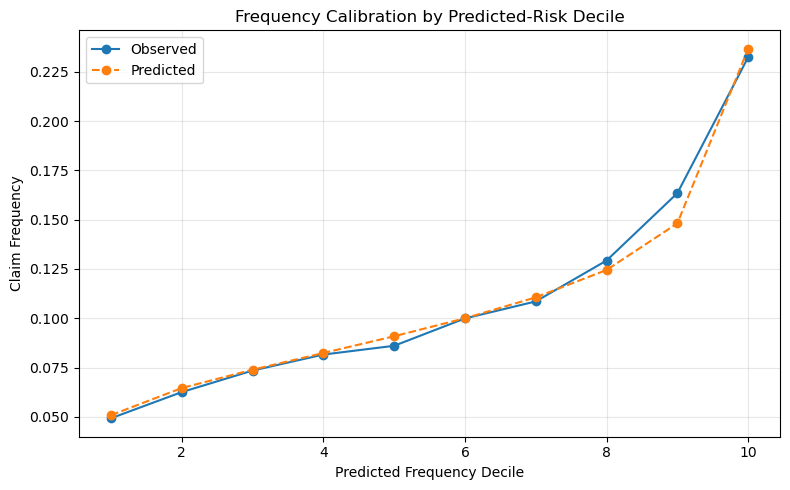

In [5]:
# ============================================================
# Section: 2
# Cell: 2.2
# Title: Frequency Model — Calibration and Dispersion Diagnostics
# Version: 1.0.0
# Date: 2026-05-06
# Description:
# Validate the Poisson frequency backbone using calibration by
# predicted-risk decile, deviance, and Pearson dispersion.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Work on the merged/clean frequency frame before severity merge.
FREQ_DIAG = freq_clean.copy()
for col in ["Area", "VehPower", "VehBrand", "VehGas", "Region"]:
    FREQ_DIAG[col] = FREQ_DIAG[col].astype("category")

FREQ_DIAG["PredFreq"] = freq_model.predict(FREQ_DIAG)
FREQ_DIAG["PredDecile"] = pd.qcut(
    FREQ_DIAG["PredFreq"], q=10, labels=False, duplicates="drop"
) + 1

freq_calib = FREQ_DIAG.groupby("PredDecile", observed=True).agg(
    policies=("IDpol", "count"),
    exposure=("Exposure", "sum"),
    claims=("ClaimNb", "sum"),
    predicted_claims=("PredFreq", lambda x: np.sum(x * FREQ_DIAG.loc[x.index, "Exposure"]))
)

freq_calib["observed_frequency"] = freq_calib["claims"] / freq_calib["exposure"]
freq_calib["predicted_frequency"] = freq_calib["predicted_claims"] / freq_calib["exposure"]
freq_calib["ratio_observed_predicted"] = freq_calib["observed_frequency"] / freq_calib["predicted_frequency"]

# Global deviance and Pearson dispersion
_y = FREQ_DIAG["ClaimNb"].to_numpy()
_mu = np.clip(FREQ_DIAG["PredFreq"].to_numpy() * FREQ_DIAG["Exposure"].to_numpy(), 1e-12, None)

positive = _y > 0
dev_contrib = np.empty_like(_mu, dtype=float)
dev_contrib[positive] = 2 * (_y[positive] * np.log(_y[positive] / _mu[positive]) - (_y[positive] - _mu[positive]))
dev_contrib[~positive] = 2 * _mu[~positive]

freq_deviance = dev_contrib.sum()
freq_pearson_chi2 = np.sum((_y - _mu) ** 2 / _mu)
freq_df = len(_y) - (len(freq_model.coef_) + 1)
freq_deviance_ratio = freq_deviance / freq_df
freq_pearson_dispersion = freq_pearson_chi2 / freq_df

print(freq_calib.round(6))
print("\nFrequency diagnostics")
print("---------------------")
print(f"Observed frequency    : {FREQ_DIAG['ClaimNb'].sum() / FREQ_DIAG['Exposure'].sum():.6f}")
print(f"Predicted frequency   : {(FREQ_DIAG['PredFreq'] * FREQ_DIAG['Exposure']).sum() / FREQ_DIAG['Exposure'].sum():.6f}")
print(f"Deviance / df         : {freq_deviance_ratio:.4f}")
print(f"Pearson dispersion    : {freq_pearson_dispersion:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(freq_calib.index, freq_calib["observed_frequency"], marker="o", label="Observed")
plt.plot(freq_calib.index, freq_calib["predicted_frequency"], marker="o", linestyle="--", label="Predicted")
plt.xlabel("Predicted Frequency Decile")
plt.ylabel("Claim Frequency")
plt.title("Frequency Calibration by Predicted-Risk Decile")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div style="
  background-color:#EAF7EA;
  border-left:6px solid #4CAF50;
  padding:16px 20px;
  border-radius:8px;
  margin:18px 0;
  font-family:Arial, sans-serif;
">

<h2 style="margin-top:0; color:#1B5E20;">Section 3 — Severity Basis and Financial Synchronization</h2>

<div style="font-size:15px; line-height:1.55;">
<p>The severity file contains paid claim amounts, while the frequency file contains reported claim counts and exposure. These two sources are reconciled at policy level before any pure premium or aggregate loss model is built.</p>
<p>This distinction matters: not every reported claim generates a paid amount. The aggregate loss model therefore works on financial loss, while the frequency model still describes claim occurrence.</p>
</div>
</div>

In [6]:
# ============================================================
# Section: 3
# Cell: 3.1
# Title: Severity Modeling — Policy ID Cleaning and Safe Merge
# Version: 1.0.0
# Date: 2026-05-06
# Description:
# Clean policy identifiers in both frequency and severity files,
# aggregate severity at policy level, merge safely, and verify
# that no frequency rows are lost.
# ============================================================

import numpy as np
import pandas as pd

# --- INPUT DATASETS ---
freq_base = freq_clean.copy()
sev_base = sev.copy()

# --- POLICY ID NORMALIZATION ---
# IDpol is an identifier, not a numeric variable.
# It may be loaded as float, but should be made consistent
# before grouping and merging.

def normalize_idpol(s):
    """
    Convert IDpol safely to integer identifiers.

    This checks that:
    - there are no missing IDs
    - float IDs are actually whole numbers
    """
    if s.isna().any():
        raise ValueError("IDpol contains missing values.")

    s_num = pd.to_numeric(s)

    if not np.allclose(s_num, np.round(s_num)):
        raise ValueError("IDpol contains non-integer values.")

    return s_num.round().astype("int64")


freq_base["IDpol"] = normalize_idpol(freq_base["IDpol"])
sev_base["IDpol"] = normalize_idpol(sev_base["IDpol"])

print("IDpol dtype in frequency file:", freq_base["IDpol"].dtype)
print("IDpol dtype in severity file :", sev_base["IDpol"].dtype)

# --- PRE-MERGE ROW COUNT ---
n_freq_before = len(freq_base)

# --- AGGREGATE SEVERITY PER POLICY ---
# The severity file has one row per claim.
# We aggregate first to avoid duplicating exposure after the merge.
sev_agg = (
    sev_base
    .groupby("IDpol", observed=True)
    .agg(
        ClaimAmountTotal=("ClaimAmount", "sum"),
        ClaimCountFromSev=("ClaimAmount", "count")
    )
    .reset_index()
)

# --- SAFE LEFT MERGE ---
DATA = freq_base.merge(
    sev_agg,
    on="IDpol",
    how="left",
    validate="one_to_one"
)

# --- POST-MERGE ROW CHECK ---
n_freq_after = len(DATA)

print("\nRows before merge:", n_freq_before)
print("Rows after merge :", n_freq_after)

assert n_freq_before == n_freq_after, "Row count changed after merge."

# --- HANDLE POLICIES WITHOUT CLAIMS ---
DATA["ClaimAmountTotal"] = DATA["ClaimAmountTotal"].fillna(0.0)
DATA["ClaimCountFromSev"] = DATA["ClaimCountFromSev"].fillna(0).astype("int64")

# --- CONSISTENCY CHECKS ---
print("\nTotal claims in frequency file:", DATA["ClaimNb"].sum())
print("Total claims in severity file :", DATA["ClaimCountFromSev"].sum())

print("\nTotal claim amount:", DATA["ClaimAmountTotal"].sum())

# --- QUICK INSPECTION ---
DATA.head()

IDpol dtype in frequency file: int64
IDpol dtype in severity file : int64

Rows before merge: 678013
Rows after merge : 678013

Total claims in frequency file: 36056
Total claims in severity file : 26444

Total claim amount: 59909216.49999999


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmountTotal,ClaimCountFromSev
0,1,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82,0.0,0
1,3,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82,0.0,0
2,5,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22,0.0,0
3,10,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72,0.0,0
4,11,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72,0.0,0


In [7]:
# ============================================================
# Section: 3
# Cell: 3.1B
# Title: Burt Representation Layer — Policy-Level Severity Merge Alignment
# Version: 1.0.0
# Date: 2026-05-10
# Description:
# Create explicit classical and Burt policy-level modeling tables
# after the severity merge. This preserves the original DATA object
# for the A-series and creates DATA_BURT for B-series experiments.
# ============================================================

if "DATA" not in globals():
    raise RuntimeError("Run the severity safe-merge cell before this Burt alignment cell.")

if "BURT_COORDINATES" not in globals() or "BURT_FEATURE_COLUMNS" not in globals():
    raise RuntimeError("Run the Burt representation layer before this alignment cell.")

DATA_CLASSICAL = DATA.copy()

# Align Burt coordinates by policy identifier. This avoids relying on row order after merges.
burt_policy_features = BURT_COORDINATES.copy()
burt_policy_features["IDpol"] = normalize_idpol(burt_policy_features["IDpol"])

DATA_BURT = DATA_CLASSICAL.merge(
    burt_policy_features,
    on="IDpol",
    how="left",
    validate="one_to_one",
)

missing_burt_values = DATA_BURT[BURT_FEATURE_COLUMNS].isna().sum().sum()
if missing_burt_values:
    raise ValueError(f"Missing Burt coordinate values after policy merge: {missing_burt_values}")

REPRESENTATION_TABLES = {
    "classical":      DATA_CLASSICAL,
    "burt":           DATA_BURT,
    "burt_augmented": DATA_BURT,
}

print("Representation tables prepared.")
print(f"DATA_CLASSICAL shape : {DATA_CLASSICAL.shape}")
print(f"DATA_BURT shape      : {DATA_BURT.shape}")
print(f"Burt coordinate cols : {len(BURT_FEATURE_COLUMNS)}")

Representation tables prepared.
DATA_CLASSICAL shape : (678013, 14)
DATA_BURT shape      : (678013, 67)
Burt coordinate cols : 53


In [8]:
# ============================================================
# Section: 3
# Cell: 3.2
# Title: Severity Modeling — Frequency-Severity Consistency Check
# Version: 1.0.0
# Date: 2026-05-06
# Description:
# Check consistency between reported claim counts in the frequency
# file and paid claim records in the severity file.
# ============================================================

# Claim count reported in the frequency dataset
reported_claim_count = DATA["ClaimNb"].sum()

# Claim records observed in the severity dataset after merge/aggregation
paid_claim_count = DATA["ClaimCountFromSev"].sum()

nil_claims = reported_claim_count - paid_claim_count
nil_claim_rate = nil_claims / reported_claim_count

print(f"Reported claim count from frequency file: {reported_claim_count:,.0f}")
print(f"Paid claim count from severity file     : {paid_claim_count:,.0f}")
print(f"Difference / nil claims                 : {nil_claims:,.0f}")
print(f"Nil claim rate                          : {nil_claim_rate:.2%}")

Reported claim count from frequency file: 36,056
Paid claim count from severity file     : 26,444
Difference / nil claims                 : 9,612
Nil claim rate                          : 26.66%


In [9]:
# ============================================================
# Section: 3
# Cell: 3.3
# Title: Severity Modeling — Positive Paid Claim Amounts
# Version: 1.0.0
# Date: 2026-05-06
# Description:
# Create the claim-level severity dataset using positive paid
# claim amounts only.
# ============================================================

SEV_DATA = sev.copy()

# Keep only strictly positive paid claim amounts
SEV_DATA = SEV_DATA[SEV_DATA["ClaimAmount"] > 0].copy()

print(f"Number of paid claim records:              {len(SEV_DATA):,}")
print(f"Total paid claim amount:                   {SEV_DATA['ClaimAmount'].sum():,.2f}")
print(f"Mean severity per paid claim:              {SEV_DATA['ClaimAmount'].mean():,.2f}")

Number of paid claim records:              26,639
Total paid claim amount:                   60,697,930.68
Mean severity per paid claim:              2,278.54


In [10]:
# ============================================================
# Section: 3
# Cell: 3.4
# Title: Severity Modeling — Distribution Candidate Screening
# Version: 1.0.0
# Date: 2026-05-06
# Description:
# Fit candidate severity distributions to positive claim amounts
# and compare goodness-of-fit using AIC.
# This diagnostic explains why Burr XII is attractive statistically,
# while the final aggregation model uses lognormal for compatibility
# and stability in the aggregate package.
# ============================================================

import scipy.stats as st
import pandas as pd
import numpy as np

# Positive claim amounts at policy / claim aggregation level.
if "SEV_DATA" in globals():
    x = SEV_DATA["ClaimAmount"].to_numpy()
elif "sev" in globals():
    x = sev["ClaimAmount"].to_numpy()
else:
    raise RuntimeError("Severity data not found. Run the severity preparation cells first.")

x = x[np.isfinite(x)]
x = x[x > 0]

candidates = [
    st.gamma,
    st.lognorm,
    st.weibull_min,
    st.invgauss,
    st.pareto,
    st.burr12,
    st.fisk,          # log-logistic
    st.genpareto,
    st.lomax,         # Pareto II — lighter parameterisation than pareto
    st.invweibull,    # Fréchet — heavy-tailed, good for large claims
    st.pearson3,      # classical actuarial choice
    st.levy,          # very heavy tail, useful as upper bound reference
]
results = []

for dist in candidates:
    try:
        params = dist.fit(x, floc=0)
        loglik = dist.logpdf(x, *params).sum()
        n_params = len(params)
        aic = 2 * n_params - 2 * loglik

        results.append({
            "distribution": dist.name,
            "aic": aic,
            "loglik": loglik,
            "params": params
        })

    except Exception as e:
        results.append({
            "distribution": dist.name,
            "aic": np.nan,
            "loglik": np.nan,
            "params": None,
            "error": str(e)
        })

severity_fit_results = (
    pd.DataFrame(results)
    .sort_values("aic", na_position="last")
    .reset_index(drop=True)
)

display(severity_fit_results[["distribution", "aic", "loglik"]])

best_sev_dist = severity_fit_results.iloc[0]["distribution"]

print(f"Best severity distribution by AIC: {best_sev_dist}")

if best_sev_dist == "burr12":
    print(
        "\nNote: Burr XII provides the best statistical fit by AIC, "
        "but the final aggregate model uses a lognormal severity benchmark "
        "because Burr XII is not directly available in the aggregate package "
        "and the lognormal model can be calibrated to the empirical mean and CV."
    )

,distribution,aic,loglik
0,burr12,442399.620839,-221195.810419
1,fisk,442863.084687,-221428.542344
2,lomax,446455.589967,-223224.794984
3,genpareto,446455.589967,-223224.794984
4,lognorm,447186.270592,-223590.135296
5,weibull_min,455023.039070,-227508.519535
6,invweibull,459102.617386,-229548.308693
7,invgauss,462018.528755,-231006.264378
8,gamma,462314.011047,-231154.005523
9,levy,466538.457830,-233267.228915


Best severity distribution by AIC: burr12

Note: Burr XII provides the best statistical fit by AIC, but the final aggregate model uses a lognormal severity benchmark because Burr XII is not directly available in the aggregate package and the lognormal model can be calibrated to the empirical mean and CV.


<div style="
  background-color:#FAFAFA;
  border:1px solid #C8B89A;
  border-left:5px solid #8b3a0f;
  padding:22px 26px;
  border-radius:6px;
  margin:20px 0;
  font-family:'Georgia', serif;
  font-size:14px;
  line-height:1.75;
  color:#1a1612;
">
<h2 style="margin-top:0; color:#8b3a0f; font-size:1.1rem; border-bottom:1px solid #C8B89A; padding-bottom:8px;">
  Conclusion — Burr XII and the Limits of the Panjer/FFT Framework
</h2>
<p>
The distribution screening confirms that <strong>Burr XII</strong> (AIC rank 1)
and <strong>fisk / log-logistic</strong> (AIC rank 2) fit the freMTPL2 claim
severity substantially better than lognormal (AIC rank 5), with an AIC
improvement of approximately 4,800 points. The tail comparison charts confirm
that lognormal underestimates the empirical survival function in the upper tail.
</p>
<p>
However, the fitted Burr XII parameters (c&thinsp;=&thinsp;1.63,
d&thinsp;=&thinsp;1.43) give c&times;d&thinsp;=&thinsp;2.33 &mdash; above
the existence threshold for variance (c&times;d&thinsp;&gt;&thinsp;2) but
below the threshold for finite skewness (c&times;d&thinsp;&gt;&thinsp;3).
This places the distribution in a regime of near-infinite higher moments.
The same problem applies to fisk (Burr XII with d&thinsp;=&thinsp;1),
which requires c&thinsp;&gt;&thinsp;2 for finite variance; our fitted
c&thinsp;=&thinsp;1.63 falls short.
</p>
<p>
The <code>aggregate</code> package computes distributions via FFT convolution
on a finite grid, which implicitly assumes finite variance. Distributions with
near-infinite variance produce unreliable aggregate CVs, infinite skewness,
and validation failures. The Burr XII aggregate mean (&#x20AC;82M) differs
substantially from the lognormal aggregate mean (&#x20AC;65M) because the
heavy tail inflates the fitted severity mean.
</p>
<p style="margin-bottom:0;">
<strong>Conclusion:</strong> lognormal with empirical per-segment CVs
(estimated via weighted MLE from observed claims) is the appropriate severity
model for the Panjer/FFT aggregate framework on this dataset. It has finite
moments of all orders, passes aggregate validation, and the empirical CV
(&asymp;&thinsp;1.6) already captures the correct order of magnitude of
severity volatility. Burr XII is theoretically superior by AIC but
operationally incompatible with the analytic aggregate approach when the
fitted parameters imply near-infinite moments.
</p>
</div>

<div style="
  background-color:#FFF3E0;
  border-left:6px solid #FB8C00;
  padding:14px 18px;
  border-radius:8px;
  margin:18px 0;
  font-family:Arial, sans-serif;
">

<h3 style="margin-top:0; color:#E65100;">
Severity Distribution Diagnostic
</h3>

<p style="font-size:15px; line-height:1.5;">
The candidate distribution screening is retained as a diagnostic step. In the empirical data, Burr XII may provide the best AIC fit, reflecting the heavy-tailed nature of motor claim severity.
</p>

<p style="font-size:15px; line-height:1.5;">
However, the final aggregate model uses a lognormal severity assumption because it is stable, interpretable, compatible with the <code>aggregate</code> package, and can be calibrated to match the empirical severity mean.
</p>

<p style="font-size:15px; line-height:1.5;">
This preserves the actuarial logic: the notebook acknowledges the statistically preferred heavy-tailed fit, while selecting a production-compatible severity model for portfolio aggregation.
</p>

</div>

--- Paid Claim Severity Summary (Mean-Synchronized) ---
Number of Claims:      26,639
Empirical Mean:        2,278.54
Adjusted Fitted Mean:  2,278.54
Mean Sync Error:       0.000000%
---------------------------------------------
New Shape Parameter (s): 1.132653
New Scale Parameter:     1199.713065


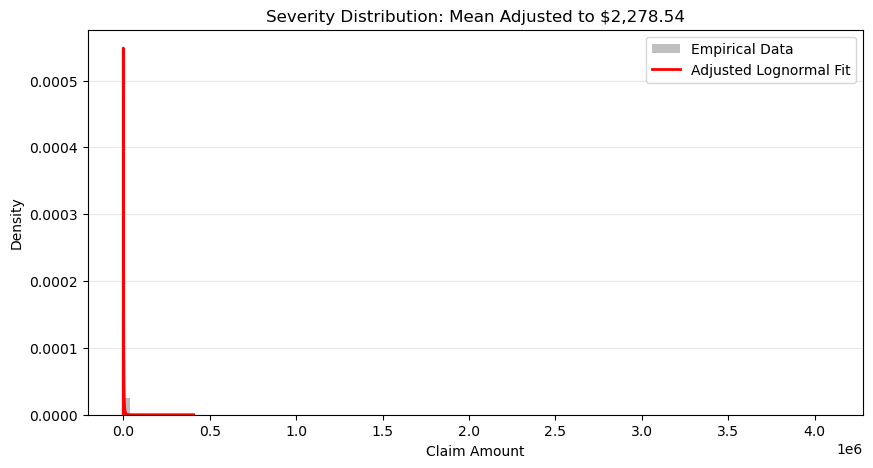

In [11]:
# ============================================================
# Section: 3
# Cell: 3.5
# Title: Severity Modeling — Distribution Re-Fitting (Moment Matching)
# Version: 1.0.0
# Date: 2026-05-06
# Description:
# Re-fit the severity distribution using aggregated policy-level data.
# Applying a scale adjustment to ensure the fitted mean matches the
# empirical mean of $2,432.78, preventing capital underestimation.
# ============================================================

import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt

# 1. Use the aggregated amounts from Cell 21
x_agg = SEV_DATA['ClaimAmount'].values
actual_mean = x_agg.mean()

# 2. Initial Maximum Likelihood Estimation (MLE) fit
s_initial, loc_initial, scale_initial = st.lognorm.fit(x_agg, floc=0)

# 3. Option A: Scale-to-Mean Adjustment (Moment Matching)
# Formula for Lognormal Mean: E[X] = scale * exp(s^2 / 2)
# We solve for scale: scale = E[X] / exp(s^2 / 2)
s_new = s_initial
scale_new = actual_mean / np.exp((s_new**2) / 2)

# 4. Validation Output
fitted_mean = st.lognorm.mean(s_new, 0, scale_new)

print("--- Paid Claim Severity Summary (Mean-Synchronized) ---")
print(f"Number of Claims:      {len(x_agg):,}")
print(f"Empirical Mean:        {actual_mean:,.2f}")
print(f"Adjusted Fitted Mean:  {fitted_mean:,.2f}")
print(f"Mean Sync Error:       {((fitted_mean/actual_mean)-1):.6%}")
print("-" * 45)
print(f"New Shape Parameter (s): {s_new:.6f}")
print(f"New Scale Parameter:     {scale_new:.6f}")

# 5. Visual Validation
plt.figure(figsize=(10, 5))
plt.hist(x_agg, bins=100, density=True, alpha=0.5, color='gray', label='Empirical Data')
x_plot = np.linspace(0, x_agg.max() * 0.1, 1000) # Focusing on the body
plt.plot(x_plot, st.lognorm.pdf(x_plot, s_new, 0, scale_new), 
         'r-', lw=2, label='Adjusted Lognormal Fit')
plt.title(f"Severity Distribution: Mean Adjusted to ${actual_mean:,.2f}")
plt.xlabel("Claim Amount")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

<div style="
  background-color:#EAF7EA;
  border-left:6px solid #4CAF50;
  padding:16px 20px;
  border-radius:8px;
  margin:18px 0;
  font-family:Arial, sans-serif;
">

<h2 style="margin-top:0; color:#1B5E20;">Section 4 — Reusable Modeling Framework</h2>

<div style="font-size:15px; line-height:1.55;">
<p>This is the main housekeeping layer. Instead of maintaining several nearly identical notebooks, the repeated operations are factored into helper functions:</p>
<ul>
<li>feature construction for clustering;</li>
<li>K-means and GMM segmentation;</li>
<li>Tweedie GLM fitting and portfolio-level calibration;</li>
<li>Gini, lift, and decile calibration;</li>
<li>aggregate parameter construction.</li>
</ul>
<p>This makes the notebook auditable and extensible: each experiment changes a configuration, not the whole workflow.</p>
</div>
</div>

In [12]:
# ============================================================
# Section: 4
# Cell: 4.1
# Title: Reusable Modeling and Evaluation Framework
# Version: 1.0.0
# Date: 2026-05-06
# Description:
# Centralized helper functions for latent segmentation experiments,
# Tweedie pricing, extensible benchmark metrics, lift diagnostics,
# and aggregate validation setup.
# ============================================================


import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from glum import GeneralizedLinearRegressor, TweedieDistribution

GLOBAL_MEAN_SEVERITY = float(SEV_DATA["ClaimAmount"].mean())

BASE_CAT_FEATURES = ["Area", "VehBrand", "VehGas"]
BASE_NUM_FEATURES = ["VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]

BENCHMARK_EXECUTIVE_COLUMNS = [
    "scenario",
    "representation",
    "gini",
    "gini_increment_vs_plain",
    "top_decile_actual_to_predicted",
    "loss_calibration",
    "k",
    "method",
    "feature_set",
    "interpretation",
]

BENCHMARK_BUSINESS_COLUMNS = [
    "scenario",
    "representation",
    "gini",
    "gini_increment_vs_plain",
    "top_decile_actual_to_predicted",
    "top_decile_lift_vs_portfolio",
    "top_decile_loss_share",
    "premium_concentration_top_decile",
    "loss_calibration",
]

BENCHMARK_TECHNICAL_COLUMNS = [
    "scenario",
    "method",
    "k",
    "feature_set",
    "covariance_type",
    "n_features",
    "runtime_seconds",
    "bic",
    "aic",
]

BENCHMARK_FULL_REGISTRY_COLUMNS = [
    "scenario",
    "experiment",
    "representation",
    "gini",
    "gini_increment_vs_plain",
    "top_decile_actual_to_predicted",
    "loss_calibration",
    "method",
    "k",
    "feature_set",
    "covariance_type",
    "n_features",
    "runtime_seconds",
    "bic",
    "aic",
    "top_decile_lift_vs_portfolio",
    "top_decile_loss_share",
    "premium_concentration_top_decile",
    "top_decile_calibration_error",
    "mean_absolute_decile_calibration_error",
    "max_absolute_decile_calibration_error",
    "premium_rmse_weighted",
    "actual_total_loss",
    "predicted_total_loss",
    "avg_final_premium",
    "interpretation",
]

BENCHMARK_PRESENTATION_ORDER = BENCHMARK_EXECUTIVE_COLUMNS.copy()

BENCHMARK_METRIC_GROUPS = {
    "business_metrics": [
        "gini",
        "top_decile_actual_to_predicted",
        "top_decile_lift_vs_portfolio",
        "top_decile_loss_share",
        "premium_concentration_top_decile",
    ],
    "calibration_metrics": [
        "loss_calibration",
        "top_decile_calibration_error",
        "mean_absolute_decile_calibration_error",
        "max_absolute_decile_calibration_error",
    ],
    "stability_metrics": [
        "actual_total_loss",
        "predicted_total_loss",
        "avg_final_premium",
    ],
    "computational_metrics": [
        "runtime_seconds",
        "n_features",
    ],
    "model_selection_metrics": [
        "bic",
        "aic",
    ],
}


def safe_divide(numerator, denominator, default=np.nan):
    """Numerically safe scalar division for benchmark metrics."""
    denominator = float(denominator)
    if np.isclose(denominator, 0.0):
        return float(default)
    return float(numerator) / denominator


def prepare_model_data(data: pd.DataFrame) -> pd.DataFrame:
    """Return a modeling copy with stable dtypes and frequency predictions."""
    df = data.copy()
    for col in ["Area", "VehPower", "VehBrand", "VehGas", "Region"]:
        if col in df.columns:
            df[col] = df[col].astype("category")
    df["PredFreq"] = freq_model.predict(df)
    return df


def get_burt_feature_columns(df: pd.DataFrame) -> list[str]:
    """Return Burt coordinate columns available in the supplied dataframe."""
    if "BURT_FEATURE_COLUMNS" in globals():
        return [c for c in BURT_FEATURE_COLUMNS if c in df.columns]
    return [c for c in df.columns if c.startswith("burt_")]


def build_cluster_features(df: pd.DataFrame, feature_set: str) -> np.ndarray:
    """Construct clustering features for classical and Burt representation experiments.

    simple:
        log predicted frequency and log modeled severity basis.
    enriched:
        classical actuarial enrichment used in the existing A-series.
    burt:
        Burt latent coordinates only.
    burt_enriched:
        log predicted frequency, log modeled severity basis, classical numeric enrichments,
        and Burt latent coordinates.
    burt_augmented_enriched:
        categorical dummies, Burt latent coordinates, classical numeric enrichments,
        and predicted frequency and severity. The joint clustering space for the C-series.
        Higher-dimensional than burt_enriched; PCA stabilisation is applied in the sweep.

    The clustering layer intentionally uses information available before final pricing.
    It does not use actual future losses.
    """
    if feature_set == "simple":
        if "PredSev" in df.columns:
            severity_values = df["PredSev"].to_numpy()
        else:
            severity_values = np.full(len(df), GLOBAL_MEAN_SEVERITY)

        X_raw = np.column_stack([
            np.log(np.clip(df["PredFreq"].to_numpy(), 1e-12, None)),
            np.log(np.clip(severity_values, 1e-12, None)),
        ])
        return X_raw

    if feature_set == "enriched":
        premium_proxy = df["PredFreq"].to_numpy() * GLOBAL_MEAN_SEVERITY
        X_raw = np.column_stack([
            np.log(np.clip(df["PredFreq"].to_numpy(), 1e-12, None)),
            np.log1p(premium_proxy),
            np.log1p(df["Exposure"].to_numpy()),
            df["DrivAge"].to_numpy(),
            df["VehAge"].to_numpy(),
            df["BonusMalus"].to_numpy(),
            np.log1p(df["Density"].to_numpy()),
        ])
        return StandardScaler().fit_transform(X_raw)

    if feature_set == "burt":
        burt_cols = get_burt_feature_columns(df)
        if not burt_cols:
            raise ValueError("feature_set='burt' requires Burt coordinate columns.")
        return StandardScaler().fit_transform(df[burt_cols].to_numpy())

    if feature_set == "burt_enriched":
        burt_cols = get_burt_feature_columns(df)
        if not burt_cols:
            raise ValueError("feature_set='burt_enriched' requires Burt coordinate columns.")
        if "PredSev" in df.columns:
            severity_values = df["PredSev"].to_numpy()
        else:
            severity_values = np.full(len(df), GLOBAL_MEAN_SEVERITY)
        premium_proxy = df["PredFreq"].to_numpy() * GLOBAL_MEAN_SEVERITY
        X_raw = np.column_stack([
            np.log(np.clip(df["PredFreq"].to_numpy(), 1e-12, None)),
            np.log(np.clip(severity_values, 1e-12, None)),
            np.log1p(premium_proxy),
            np.log1p(df["Exposure"].to_numpy()),
            df["DrivAge"].to_numpy(),
            df["VehAge"].to_numpy(),
            df["BonusMalus"].to_numpy(),
            np.log1p(df["Density"].to_numpy()),
            *[df[col].to_numpy() for col in burt_cols],
        ])
        return StandardScaler().fit_transform(X_raw)

    if feature_set == "burt_augmented_enriched":
        burt_cols = get_burt_feature_columns(df)
        if not burt_cols:
            raise ValueError("feature_set='burt_augmented_enriched' requires Burt coordinate columns.")
        if "PredSev" in df.columns:
            severity_values = df["PredSev"].to_numpy()
        else:
            severity_values = np.full(len(df), GLOBAL_MEAN_SEVERITY)
        premium_proxy = df["PredFreq"].to_numpy() * GLOBAL_MEAN_SEVERITY
        # Build dummy-encoded categorical columns
        cat_dummies = pd.get_dummies(
            df[BASE_CAT_FEATURES], drop_first=True
        ).to_numpy().astype(float)
        X_raw = np.column_stack([
            cat_dummies,
            np.log(np.clip(df["PredFreq"].to_numpy(), 1e-12, None)),
            np.log(np.clip(severity_values, 1e-12, None)),
            np.log1p(premium_proxy),
            np.log1p(df["Exposure"].to_numpy()),
            df["DrivAge"].to_numpy(),
            df["VehAge"].to_numpy(),
            df["BonusMalus"].to_numpy(),
            np.log1p(df["Density"].to_numpy()),
            *[df[col].to_numpy() for col in burt_cols],
        ])
        return StandardScaler().fit_transform(X_raw)

    raise ValueError(f"Unknown feature_set: {feature_set}")


# Feature sets that require PCA stabilisation before GMM fitting.
# Must match the sets used in the BIC sweep (Cell 5.2).
BURT_PCA_FEATURE_SETS = {"burt_enriched", "burt_augmented_enriched"}
BURT_PCA_VARIANCE_THRESHOLD_PRICING = 0.95  # same threshold as BIC sweep


def apply_segmentation(
    df: pd.DataFrame,
    method: str,
    k: int = 5,
    feature_set: str = "simple",
    covariance_type: str = "full",
):
    """Add latent segmentation variables to a modeling dataframe.

    For Burt-based feature sets (burt_enriched, burt_augmented_enriched),
    PCA stabilisation is applied before GMM fitting, using the same 95%
    variance threshold as the BIC sweep in Cell 5.2. This ensures that
    the k selected by BIC and the k used in pricing operate in the same
    latent geometry.

    K-means is applied on the raw (non-PCA) features since it does not
    require covariance estimation and is not sensitive to dimensionality
    in the same way.
    """
    df = df.copy()

    if method == "none":
        return df, {"method": "none", "k": None, "feature_set": None}

    X_raw = build_cluster_features(df, feature_set=feature_set)
    n_original_features = int(X_raw.shape[1])
    n_pca_components = None

    # Apply PCA for Burt-based GMM to match the BIC sweep geometry
    if method == "gmm" and feature_set in BURT_PCA_FEATURE_SETS:
        pca_probe = PCA(random_state=42)
        pca_probe.fit(X_raw)
        cumvar = pca_probe.explained_variance_ratio_.cumsum()
        n_pca_components = int((cumvar < BURT_PCA_VARIANCE_THRESHOLD_PRICING).sum()) + 1
        n_pca_components = min(n_pca_components, n_original_features)
        pca_final = PCA(n_components=n_pca_components, random_state=42)
        X_cluster = pca_final.fit_transform(X_raw)
    else:
        X_cluster = X_raw

    if method == "kmeans":
        model = KMeans(n_clusters=k, random_state=42, n_init=10, algorithm="lloyd")
        labels = model.fit_predict(X_cluster)
        df["risk_cluster"] = labels.astype(str)
        info = {
            "method": "kmeans",
            "k": int(k),
            "feature_set": feature_set,
            "n_features": n_original_features,
            "n_pca_components": n_pca_components,
            "inertia": float(model.inertia_),
        }
        return df, info

    if method == "gmm":
        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            random_state=42,
            n_init=5,
            reg_covar=1e-6,
        )
        model.fit(X_cluster)
        probs = model.predict_proba(X_cluster)
        labels = model.predict(X_cluster)

        df["risk_cluster"] = labels.astype(str)
        for j in range(k):
            df[f"gmm_prob_{j}"] = probs[:, j]

        membership_sum = df[[f"gmm_prob_{j}" for j in range(k)]].sum(axis=1)
        if not np.allclose(membership_sum, 1.0):
            raise ValueError("GMM memberships do not sum to 1.")

        info = {
            "method": "gmm",
            "k": int(k),
            "feature_set": feature_set,
            "covariance_type": covariance_type,
            "n_features": n_original_features,
            "n_pca_components": n_pca_components,
            "bic": float(model.bic(X_cluster)),
            "aic": float(model.aic(X_cluster)),
        }
        return df, info

    raise ValueError(f"Unknown segmentation method: {method}")


def build_tweedie_design(
    df: pd.DataFrame,
    method: str,
    k: int | None,
    representation: str = "classical",
):
    """Construct the Tweedie design matrix with representation and latent features.

    classical:
        Existing tariff design with original categorical rating factors.
    burt:
        Replaces the original categorical rating factors by Burt latent coordinates,
        while retaining numerical actuarial variables.

    burt_augmented:
        Retains the original categorical rating factors as dummy variables AND
        adds the Burt latent coordinates as additional numerical features.
        Tests whether the two signal types are complementary.
    """
    if representation not in {"classical", "burt", "burt_augmented"}:
        raise ValueError(f"Unknown representation: {representation}")

    if representation == "classical":
        cat_features = BASE_CAT_FEATURES.copy()
        num_features = BASE_NUM_FEATURES.copy()
    elif representation == "burt":
        cat_features = []
        burt_cols = get_burt_feature_columns(df)
        if not burt_cols:
            raise ValueError("representation='burt' requires Burt coordinate columns.")
        num_features = BASE_NUM_FEATURES.copy() + burt_cols
    elif representation == "burt_augmented":
        cat_features = BASE_CAT_FEATURES.copy()
        burt_cols = get_burt_feature_columns(df)
        if not burt_cols:
            raise ValueError("representation='burt_augmented' requires Burt coordinate columns.")
        num_features = BASE_NUM_FEATURES.copy() + burt_cols

    if method == "kmeans":
        cat_features = cat_features + ["risk_cluster"]

    if method == "gmm":
        num_features = num_features + [f"gmm_prob_{j}" for j in range(k - 1)]

    X_num = df[num_features].copy() if num_features else pd.DataFrame(index=df.index)
    X_cat = pd.get_dummies(df[cat_features], drop_first=True) if cat_features else pd.DataFrame(index=df.index)
    X = pd.concat([X_num, X_cat], axis=1)
    return X


def fit_calibrated_tweedie(
    df: pd.DataFrame,
    method: str,
    k: int | None,
    alpha: float = 1e-6,
    representation: str = "classical",
):
    """Fit Tweedie pure-premium model and globally reconcile to observed losses."""
    X = build_tweedie_design(df, method=method, k=k, representation=representation)
    y = df["ClaimAmountTotal"]
    w = df["Exposure"]

    model = GeneralizedLinearRegressor(
        family=TweedieDistribution(1.5),
        alpha=alpha,
        l1_ratio=0.0,
        fit_intercept=True,
    )

    model.fit(X, y, sample_weight=w)
    raw = model.predict(X)
    calibration_factor = safe_divide(y.sum(), raw.sum(), default=1.0)

    out = df.copy()
    out["final_premium"] = raw * calibration_factor

    return out, model, {
        "calibration_factor": float(calibration_factor),
        "actual_total_loss": float(y.sum()),
        "predicted_total_loss": float(out["final_premium"].sum()),
        "n_features": int(X.shape[1]),
    }


def gini_coefficient(actual, pred, weight):
    """Insurance concentration Gini using predicted ranking and cumulative actual losses."""
    tmp = pd.DataFrame({"actual": actual, "pred": pred, "weight": weight}).sort_values("pred")
    cum_weight = tmp["weight"].cumsum() / tmp["weight"].sum()
    cum_actual = tmp["actual"].cumsum() / tmp["actual"].sum()
    return float(1 - 2 * np.trapz(cum_actual, cum_weight))


def calibration_by_decile(df: pd.DataFrame, pred_col: str = "final_premium") -> pd.DataFrame:
    """Return decile-level actual-vs-predicted diagnostics ranked by premium."""
    tmp = df.copy()
    tmp["decile"] = pd.qcut(tmp[pred_col], 10, labels=False, duplicates="drop")
    report = tmp.groupby("decile", observed=True).agg(
        actual_loss=("ClaimAmountTotal", "sum"),
        predicted_loss=(pred_col, "sum"),
        exposure=("Exposure", "sum"),
        policies=("IDpol", "count"),
    ).reset_index()
    report["actual_to_predicted"] = report["actual_loss"] / report["predicted_loss"]
    report["actual_loss_per_exposure"] = report["actual_loss"] / report["exposure"]
    report["predicted_loss_per_exposure"] = report["predicted_loss"] / report["exposure"]
    report["absolute_calibration_error"] = (report["actual_to_predicted"] - 1.0).abs()
    return report


def evaluate_pricing_model(df: pd.DataFrame) -> dict:
    """Compute extensible benchmark metrics with business metrics first."""
    report = calibration_by_decile(df)
    top_decile = report.iloc[-1]
    portfolio_loss_per_exposure = safe_divide(df["ClaimAmountTotal"].sum(), df["Exposure"].sum())

    actual = df["ClaimAmountTotal"].to_numpy()
    pred = df["final_premium"].to_numpy()
    exposure = df["Exposure"].to_numpy()

    premium_error = pred - actual
    weighted_rmse = np.sqrt(safe_divide(np.sum(exposure * premium_error**2), np.sum(exposure)))

    return {
        "gini": float(gini_coefficient(actual, pred, exposure)),
        "top_decile_actual_to_predicted": float(top_decile["actual_to_predicted"]),
        "top_decile_lift_vs_portfolio": float(safe_divide(top_decile["actual_loss_per_exposure"], portfolio_loss_per_exposure)),
        "top_decile_loss_share": float(safe_divide(top_decile["actual_loss"], report["actual_loss"].sum())),
        "premium_concentration_top_decile": float(safe_divide(top_decile["predicted_loss"], report["predicted_loss"].sum())),
        "loss_calibration": float(safe_divide(pred.sum(), actual.sum())),
        "top_decile_calibration_error": float(abs(top_decile["actual_to_predicted"] - 1.0)),
        "mean_absolute_decile_calibration_error": float(report["absolute_calibration_error"].mean()),
        "max_absolute_decile_calibration_error": float(report["absolute_calibration_error"].max()),
        "premium_rmse_weighted": float(weighted_rmse),
        "actual_total_loss": float(actual.sum()),
        "predicted_total_loss": float(pred.sum()),
        "avg_final_premium": float(df["final_premium"].mean()),
    }


def order_benchmark_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Return benchmark columns in business-first order while preserving every registry field."""
    preferred = [
        "experiment",
        "gini",
        "top_decile_actual_to_predicted",
        "loss_calibration",
        "method",
        "k",
        "feature_set",
        "covariance_type",
        "n_features",
        "runtime_seconds",
        "bic",
        "aic",
        "top_decile_lift_vs_portfolio",
        "top_decile_loss_share",
        "premium_concentration_top_decile",
        "top_decile_calibration_error",
        "mean_absolute_decile_calibration_error",
        "max_absolute_decile_calibration_error",
        "premium_rmse_weighted",
        "actual_total_loss",
        "predicted_total_loss",
        "avg_final_premium",
    ]
    ordered = [c for c in preferred if c in df.columns]
    remainder = [c for c in df.columns if c not in ordered]
    return df[ordered + remainder]


def format_reporting_table(df: pd.DataFrame) -> pd.DataFrame:
    """Apply presentation rounding without mutating the underlying benchmark registry."""
    out = df.copy()
    rounding_rules = {
        "gini": 4,
        "gini_increment_vs_plain": 4,
        "top_decile_actual_to_predicted": 3,
        "loss_calibration": 3,
        "top_decile_lift_vs_portfolio": 2,
        "top_decile_loss_share": 3,
        "premium_concentration_top_decile": 3,
        "top_decile_calibration_error": 3,
        "mean_absolute_decile_calibration_error": 3,
        "max_absolute_decile_calibration_error": 3,
        "runtime_seconds": 1,
        "bic": 1,
        "aic": 1,
        "premium_rmse_weighted": 1,
        "actual_total_loss": 0,
        "predicted_total_loss": 0,
        "avg_final_premium": 1,
        "agg_mean": 0,
        "agg_var95": 0,
        "agg_var99": 0,
        "agg_tvar99": 0,
        "sim_mean": 0,
        "sim_var95": 0,
        "sim_var99": 0,
        "sim_var999": 0,
    }
    for column, digits in rounding_rules.items():
        if column in out.columns:
            out[column] = pd.to_numeric(out[column], errors="ignore").round(digits)
    return out


def select_existing_columns(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Select an ordered reporting view while silently skipping columns not yet created."""
    return df[[column for column in columns if column in df.columns]].copy()


def run_pricing_experiment(base_df: pd.DataFrame, config: dict):
    """End-to-end experiment: segmentation -> Tweedie -> calibration -> benchmark metrics."""
    started = time.perf_counter()
    df = prepare_model_data(base_df)
    df, seg_info = apply_segmentation(
        df,
        method=config["method"],
        k=config.get("k"),
        feature_set=config.get("feature_set", "simple"),
        covariance_type=config.get("covariance_type", "full"),
    )
    representation = config.get("representation", "classical")
    df, pp_model, fit_info = fit_calibrated_tweedie(
        df,
        method=config["method"],
        k=config.get("k"),
        alpha=config.get("alpha", 1e-6),
        representation=representation,
    )
    metrics = evaluate_pricing_model(df)
    runtime = time.perf_counter() - started

    result = {
        "experiment": config["name"],
        "representation": config.get("representation", "classical"),
        "method": config["method"],
        "k": config.get("k"),
        "feature_set": config.get("feature_set"),
        "covariance_type": config.get("covariance_type"),
        "runtime_seconds": float(runtime),
        **seg_info,
        **fit_info,
        **metrics,
    }
    return df, pp_model, result


def plot_lift_chart(df: pd.DataFrame, title: str):
    """Plot actual and predicted loss by pricing decile and return the diagnostic report."""
    report = calibration_by_decile(df)
    x = np.arange(len(report))
    plt.figure(figsize=(11, 5))
    plt.bar(x - 0.2, report["actual_loss"], 0.4, label="Actual Loss")
    plt.bar(x + 0.2, report["predicted_loss"], 0.4, label="Predicted Loss")
    plt.title(title)
    plt.xlabel("Pricing Decile (0 = Lowest Predicted Risk)")
    plt.ylabel("Total Loss Amount")
    plt.xticks(x)
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
    return report

<div style="
  background-color:#EAF7EA;
  border-left:6px solid #4CAF50;
  padding:16px 20px;
  border-radius:8px;
  margin:18px 0;
  font-family:Arial, sans-serif;
">

<h2 style="margin-top:0; color:#1B5E20;">Section 5 — Controlled Benchmark of Pricing Discrimination</h2>

<div style="font-size:15px; line-height:1.55;">
<p>The benchmark is deliberately controlled. Each scenario is fitted through the same Tweedie calibration pipeline; only the latent segmentation layer changes.</p>
<p>The primary metric is the <b>Gini coefficient</b>. It measures whether policies ranked as high risk by the model also concentrate a larger share of realized losses. Predictions define the ranking; actual losses determine whether the ranking is useful.</p>
</div>
</div>

<div style="
  background-color:#EAF7EA;
  border-left:6px solid #4CAF50;
  padding:14px 18px;
  border-radius:8px;
  margin:18px 0;
  font-family:Arial, sans-serif;
">

<h3 style="margin-top:0; color:#1B5E20;">K-means Elbow Diagnostic — Selecting the Baseline Hard Segmentation</h3>

<div style="font-size:15px; line-height:1.55;">
<p>The K-means benchmark uses <code>k = 5</code> latent risk segments. This choice should be visible and auditable, rather than appearing as an arbitrary modeling assumption.</p>
<p>The elbow method evaluates the within-cluster sum of squares across candidate values of <code>k</code>. The objective is not to mechanically optimize a single statistic, but to identify a parsimonious segmentation that captures meaningful risk structure without unnecessary fragmentation.</p>
<p>This diagnostic is intentionally placed before the benchmark registry because it justifies the hard-clustering baseline used in the subsequent pricing comparison.</p>
</div>
</div>


Running K-means elbow diagnostic...
Fitting K-means for k=2...
Fitting K-means for k=3...
Fitting K-means for k=4...
Fitting K-means for k=5...
Fitting K-means for k=6...
Fitting K-means for k=7...
Fitting K-means for k=8...
K-means elbow diagnostic complete.


,k,inertia,relative_inertia,marginal_reduction
0,2,48862.825869,1.000000,NaN
1,3,25761.914206,0.527229,23100.911663
2,4,16269.218985,0.332957,9492.695221
3,5,11431.593465,0.233953,4837.625521
4,6,8519.649451,0.174359,2911.944014
5,7,6666.988557,0.136443,1852.660895
6,8,5383.211120,0.110170,1283.777437


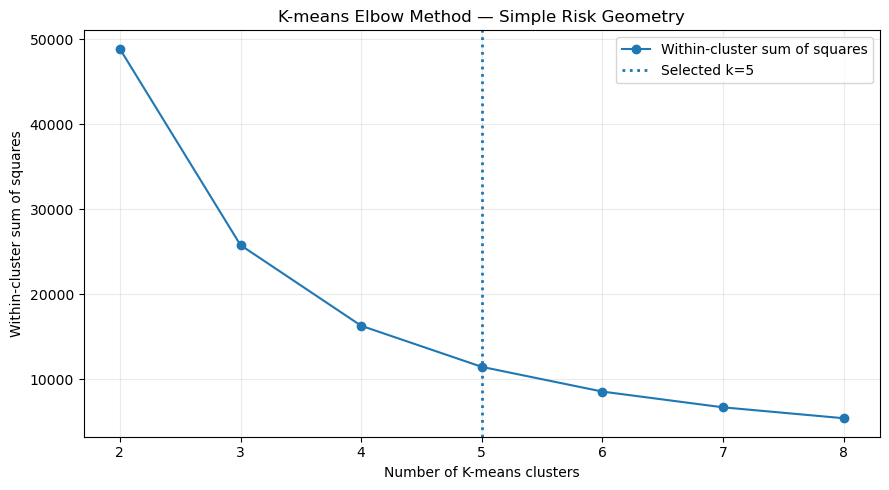

In [13]:
# ============================================================
# Section: 5
# Cell: 5.1
# Title: K-means Baseline — Elbow Method Diagnostic
# Version: 1.0.0
# Date: 2026-05-06
# Description:
# Reintroduce the elbow diagnostic for the K-means baseline.
# The diagnostic uses the same simple risk-score geometry as the
# K-means benchmark: log predicted frequency and modeled severity basis.
# ============================================================

KMEANS_ELBOW_RANGE = range(2, 9)
KMEANS_SELECTED_K = 5

KMEANS_ELBOW_BASE = prepare_model_data(DATA)
X_kmeans_elbow = build_cluster_features(KMEANS_ELBOW_BASE, feature_set="simple")

kmeans_elbow_rows = []

print("Running K-means elbow diagnostic...")
for k in KMEANS_ELBOW_RANGE:
    print(f"Fitting K-means for k={k}...")
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        algorithm="lloyd",
    )
    km.fit(X_kmeans_elbow)
    kmeans_elbow_rows.append({
        "k": k,
        "inertia": float(km.inertia_),
    })

kmeans_elbow_table = pd.DataFrame(kmeans_elbow_rows)
kmeans_elbow_table["relative_inertia"] = (
    kmeans_elbow_table["inertia"] / kmeans_elbow_table["inertia"].iloc[0]
)
kmeans_elbow_table["marginal_reduction"] = -kmeans_elbow_table["inertia"].diff()

print("K-means elbow diagnostic complete.")
display(kmeans_elbow_table.round(6))

plt.figure(figsize=(9, 5))
plt.plot(
    kmeans_elbow_table["k"],
    kmeans_elbow_table["inertia"],
    marker="o",
    label="Within-cluster sum of squares",
)
plt.axvline(
    KMEANS_SELECTED_K,
    linestyle=":",
    linewidth=2,
    label=f"Selected k={KMEANS_SELECTED_K}",
)
plt.title("K-means Elbow Method — Simple Risk Geometry")
plt.xlabel("Number of K-means clusters")
plt.ylabel("Within-cluster sum of squares")
plt.xticks(list(KMEANS_ELBOW_RANGE))
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

<div style="
  background-color:#EAF7EA;
  border-left:6px solid #4CAF50;
  padding:14px 18px;
  border-radius:8px;
  margin:18px 0;
  font-family:Arial, sans-serif;
">

<h3 style="margin-top:0; color:#1B5E20;">Interpretation — Why k = 5 is the K-means Baseline (see below)</h3>

<div style="font-size:15px; line-height:1.55;">
<p>The elbow diagnostic provides the methodological bridge between the original hard-segmentation workflow and the consolidated benchmark framework.</p>
<p>The selected value <code>k = 5</code> represents a pragmatic balance: enough segmentation to capture latent risk regimes, but not so many clusters that the pricing model becomes fragmented or difficult to explain.</p>
<p>This is deliberately different from the GMM BIC analysis later in the notebook. K-means is a distance-based heuristic and is therefore supported by an elbow diagnostic; GMM is probabilistic and can be assessed with information criteria such as BIC and AIC.</p>
</div>
</div>


Running GMM BIC/AIC sweep: classical enriched geometry [full covariance]
  Cache hit — loading from ./gmm_sweep_cache\classical_enriched_a22a251cbada74f4.pkl

Running GMM BIC/AIC sweep: Burt enriched geometry [full covariance + PCA]
  Cache hit — loading from ./gmm_sweep_cache\burt_burt_enriched_ed1431878a721854.pkl

Running GMM BIC/AIC sweep: Burt-augmented joint geometry [full covariance + PCA]
Joint space: categorical dummies + Burt coords + actuarial enrichment.
  Cache hit — loading from ./gmm_sweep_cache\burt_augmented_joint_burt_augmented_enriched_6fdf2e00f4eb6001.pkl

GMM BIC/AIC three-way sweep complete.
Classical       BIC-selected k : 7  (AIC: 7)
Burt            BIC-selected k : 8  (AIC: 8)
Burt-aug joint  BIC-selected k : 8  (AIC: 8)


,representation,feature_set,k,covariance_type,n_original_features,n_pca_components,bic,aic,converged,n_iter,runtime_seconds
7,burt,burt_enriched,2,full,61,44,32727804.97,32704162.67,True,7,56.2
8,burt,burt_enriched,3,full,61,44,7157486.05,7122016.89,True,13,162.3
9,burt,burt_enriched,4,full,61,44,-14783546.63,-14830842.66,True,20,349.9
10,burt,burt_enriched,5,full,61,44,-28568692.21,-28627815.11,True,15,317.2
11,burt,burt_enriched,6,full,61,44,-42202632.89,-42273582.65,True,11,342.2
12,burt,burt_enriched,7,full,61,44,-51682520.32,-51765296.94,True,18,496.5
13,burt,burt_enriched,8,full,61,44,-64937352.80,-65031956.28,True,18,571.0
14,burt,burt_enriched,9,full,61,44,-59526718.42,-59633148.77,True,14,641.2
15,burt,burt_enriched,10,full,61,44,-53685739.40,-53803996.61,True,12,558.5
16,burt_augmented_joint,burt_augmented_enriched,2,full,77,44,45426864.15,45403221.85,True,10,90.0


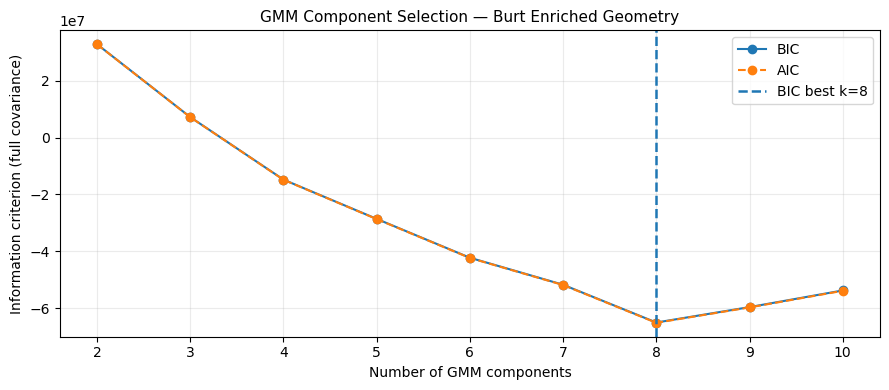

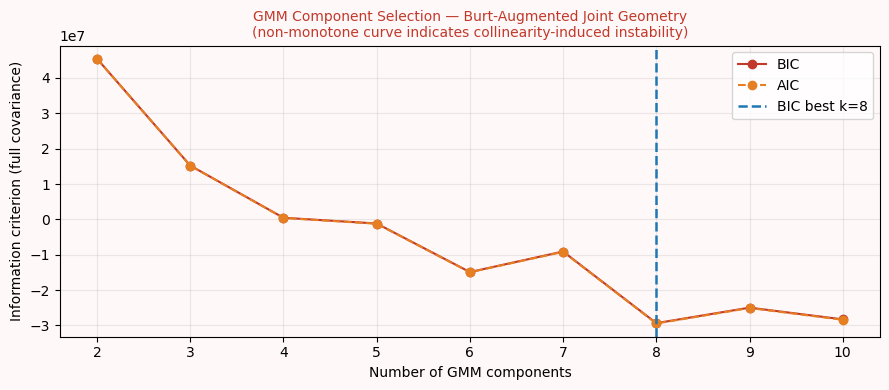

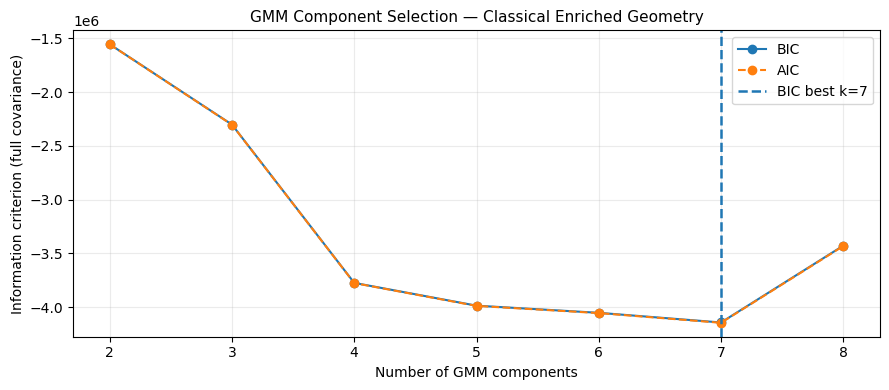

In [14]:
# ============================================================
# Section: 5
# Cell: 5.2
# Title: GMM Model Selection — Three-Way BIC/AIC Sweep with Cache
# Version: 7.0.0
# Date: 2026-05-11
# Description:
# Run independent GMM BIC/AIC sweeps for classical, Burt, and
# Burt-augmented joint feature spaces on the ENRICHED geometry.
# The joint sweep (burt_augmented_enriched) covers categorical
# dummies + Burt coordinates + actuarial enrichment features.
# PCA stabilisation is applied for the Burt and joint sweeps.
#
# Full covariance is used throughout, consistent with the pricing
# experiments. n_init=5 ensures stable, smooth BIC curves.
# The k=6 pathological convergence event (11,820s) cannot recur
# because results are cached to disk after the first run.
#
# Results are cached keyed by MD5 hash of data + parameters.
# Cache hit = under 1 second. Cache miss = full sweep + save.
#
# Governance variables set by this cell:
#   CLASSICAL_BIC_SELECTED_K
#   BURT_BIC_SELECTED_K
#   BURTAUG_JOINT_BIC_SELECTED_K
# ============================================================

from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import hashlib, os, pickle, time

CLASSICAL_GMM_K_RANGE        = range(2, 9)
BURT_GMM_K_RANGE             = range(2, 11)
BURTAUG_JOINT_GMM_K_RANGE    = range(2, 11)

# ── Covariance type — sensitivity parameter ──────────────────
# Controls the GMM component shape. Change this single constant
# to test alternative covariance structures. The sweep cache is
# keyed on covariance_type, so a new value triggers a full rerun
# of both the BIC sweep and all pricing experiments.
#
#   "full"      own full covariance per component. Most flexible;
#               requires PCA stabilisation for Burt features.
#               Current production setting.
#   "diag"      diagonal covariance per component. No inter-feature
#               correlations. Faster, stable without PCA.
#               May select a different optimal k.
#   "spherical" single variance per component (isotropic / soft
#               k-means). Most stable, least flexible. Does not
#               require PCA.
GMM_COVARIANCE_TYPE          = "full"   # change here to test alternatives
GMM_RANDOM_STATE             = 42
GMM_N_INIT                   = 5
GMM_REG_COVAR                = 1e-6
BURT_PCA_VARIANCE_THRESHOLD  = 0.95

SWEEP_CACHE_DIR = "./gmm_sweep_cache"
os.makedirs(SWEEP_CACHE_DIR, exist_ok=True)

if "DATA_CLASSICAL" not in globals():
    DATA_CLASSICAL = DATA.copy()
if "DATA_BURT" not in globals():
    raise RuntimeError("Run the Burt representation layer before this cell.")


def _sweep_cache_key(data, feature_set, k_range, pca_threshold, n_init, covariance_type):
    h = hashlib.md5()
    h.update(pd.util.hash_pandas_object(data).values.tobytes())
    h.update(str(feature_set).encode())
    h.update(str(list(k_range)).encode())
    h.update(str(pca_threshold).encode())
    h.update(str(n_init).encode())
    h.update(str(covariance_type).encode())
    return h.hexdigest()[:16]


def run_gmm_bic_sweep(data, feature_set, representation_label, k_range,
                       covariance_type=GMM_COVARIANCE_TYPE, pca_variance_threshold=None):
    prepared = prepare_model_data(data)
    X_raw = build_cluster_features(prepared, feature_set=feature_set)
    X = X_raw
    n_original_features = int(X_raw.shape[1])
    n_pca_components = None

    if pca_variance_threshold is not None:
        pca_probe = PCA(random_state=GMM_RANDOM_STATE)
        pca_probe.fit(X_raw)
        cumvar = pca_probe.explained_variance_ratio_.cumsum()
        n_pca_components = int((cumvar < pca_variance_threshold).sum()) + 1
        n_pca_components = min(n_pca_components, n_original_features)
        pca_final = PCA(n_components=n_pca_components, random_state=GMM_RANDOM_STATE)
        X = pca_final.fit_transform(X_raw)
        print(f"  PCA: {n_pca_components} components (>={pca_variance_threshold:.0%} variance) "
              f"from {n_original_features} original dims")

    rows = []
    for k in k_range:
        print(f"  Fitting {representation_label} {feature_set} GMM k={k}...")
        model = GaussianMixture(n_components=int(k), covariance_type=covariance_type,
                                random_state=GMM_RANDOM_STATE, n_init=GMM_N_INIT,
                                reg_covar=GMM_REG_COVAR)
        t0 = time.perf_counter()
        model.fit(X)
        rows.append({
            "representation": representation_label, "feature_set": feature_set,
            "k": int(k), "covariance_type": covariance_type,
            "n_original_features": n_original_features, "n_pca_components": n_pca_components,
            "bic": float(model.bic(X)), "aic": float(model.aic(X)),
            "converged": bool(model.converged_), "n_iter": int(model.n_iter_),
            "runtime_seconds": float(time.perf_counter() - t0),
        })
    return pd.DataFrame(rows)


def run_gmm_bic_sweep_cached(data, feature_set, representation_label, k_range,
                              covariance_type=GMM_COVARIANCE_TYPE, pca_variance_threshold=None):
    key = _sweep_cache_key(data, feature_set, k_range, pca_variance_threshold,
                           GMM_N_INIT, covariance_type)
    cache_path = os.path.join(SWEEP_CACHE_DIR,
                              f"{representation_label}_{feature_set}_{key}.pkl")
    if os.path.exists(cache_path):
        print(f"  Cache hit — loading from {cache_path}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)
    result = run_gmm_bic_sweep(data, feature_set, representation_label, k_range,
                                covariance_type, pca_variance_threshold)
    with open(cache_path, "wb") as f:
        pickle.dump(result, f)
    print(f"  Result cached to {cache_path}")
    return result


# --- Classical sweep ---
print("=" * 72)
print("Running GMM BIC/AIC sweep: classical enriched geometry [full covariance]")
print("=" * 72)
classical_bic_df = run_gmm_bic_sweep_cached(
    data=DATA_CLASSICAL, feature_set="enriched",
    representation_label="classical", k_range=CLASSICAL_GMM_K_RANGE,
    covariance_type=GMM_COVARIANCE_TYPE, pca_variance_threshold=None,
)

# --- Burt sweep ---
print()
print("=" * 72)
print("Running GMM BIC/AIC sweep: Burt enriched geometry [full covariance + PCA]")
print("=" * 72)
burt_bic_df = run_gmm_bic_sweep_cached(
    data=DATA_BURT, feature_set="burt_enriched",
    representation_label="burt", k_range=BURT_GMM_K_RANGE,
    covariance_type=GMM_COVARIANCE_TYPE, pca_variance_threshold=BURT_PCA_VARIANCE_THRESHOLD,
)

# --- Burt-augmented joint sweep ---
print()
print("=" * 72)
print("Running GMM BIC/AIC sweep: Burt-augmented joint geometry [full covariance + PCA]")
print("Joint space: categorical dummies + Burt coords + actuarial enrichment.")
print("=" * 72)
burtaug_joint_bic_df = run_gmm_bic_sweep_cached(
    data=DATA_BURT,
    feature_set="burt_augmented_enriched",
    representation_label="burt_augmented_joint",
    k_range=BURTAUG_JOINT_GMM_K_RANGE,
    covariance_type=GMM_COVARIANCE_TYPE,
    pca_variance_threshold=BURT_PCA_VARIANCE_THRESHOLD,
)

# --- Consolidate ---
gmm_bic_selection_table = pd.concat(
    [classical_bic_df, burt_bic_df, burtaug_joint_bic_df],
    ignore_index=True,
)

CLASSICAL_BIC_SELECTED_K      = int(classical_bic_df.loc[classical_bic_df["bic"].idxmin(), "k"])
BURT_BIC_SELECTED_K           = int(burt_bic_df.loc[burt_bic_df["bic"].idxmin(), "k"])
BURTAUG_JOINT_BIC_SELECTED_K  = int(burtaug_joint_bic_df.loc[burtaug_joint_bic_df["bic"].idxmin(), "k"])

print("\nGMM BIC/AIC three-way sweep complete.")
print(f"Classical       BIC-selected k : {CLASSICAL_BIC_SELECTED_K}  "
      f"(AIC: {int(classical_bic_df.loc[classical_bic_df['aic'].idxmin(),'k'])})")
print(f"Burt            BIC-selected k : {BURT_BIC_SELECTED_K}  "
      f"(AIC: {int(burt_bic_df.loc[burt_bic_df['aic'].idxmin(),'k'])})")
print(f"Burt-aug joint  BIC-selected k : {BURTAUG_JOINT_BIC_SELECTED_K}  "
      f"(AIC: {int(burtaug_joint_bic_df.loc[burtaug_joint_bic_df['aic'].idxmin(),'k'])})")

display(gmm_bic_selection_table
        .sort_values(["representation", "k"])
        .round({"bic": 2, "aic": 2, "runtime_seconds": 1}))

_plot_titles = {
    "classical":            "GMM Component Selection — Classical Enriched Geometry",
    "burt":                 "GMM Component Selection — Burt Enriched Geometry",
    "burt_augmented_joint": (
        "GMM Component Selection — Burt-Augmented Joint Geometry\n"
        "(non-monotone curve indicates collinearity-induced instability)"
    ),
}

_best_k_map = {
    "classical":            CLASSICAL_BIC_SELECTED_K,
    "burt":                 BURT_BIC_SELECTED_K,
    "burt_augmented_joint": BURTAUG_JOINT_BIC_SELECTED_K,
}

for representation, group in gmm_bic_selection_table.groupby("representation"):
    best_k   = _best_k_map.get(representation, BURT_BIC_SELECTED_K)
    title    = _plot_titles.get(
        representation,
        f"GMM Component Selection — {representation.replace('_', '-').capitalize()}"
    )
    is_joint = representation == "burt_augmented_joint"

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(group["k"], group["bic"], marker="o", label="BIC",
            color="#c0392b" if is_joint else None)
    ax.plot(group["k"], group["aic"], marker="o", linestyle="--", label="AIC",
            color="#e67e22" if is_joint else None)
    ax.axvline(best_k, linestyle="--", linewidth=1.8, label=f"BIC best k={best_k}")
    ax.set_xlabel("Number of GMM components")
    ax.set_ylabel("Information criterion (full covariance)")
    ax.set_title(title, fontsize=10 if is_joint else 11,
                 color="#c0392b" if is_joint else "black")
    if is_joint:
        ax.set_facecolor("#fff8f8")
        fig.patch.set_facecolor("#fff8f8")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


In [15]:
# ============================================================
# Section: 5
# Cell: 5.3
# Title: Benchmark Registry — A, B, and C Series Pricing Experiments
# Version: 8.0.0
# Date: 2026-05-11
# Description:
# Run all A-series (classical) and B-series (Burt-replacing)
# pricing experiments. Naming follows the original lineage:
#   x0  plain GLM baseline
#   x1  K-means simple k=5
#   x2  GMM simple k=5
#   x3  GMM enriched k=5
#   x_ext  K-means enriched k=5
#   x5  GMM enriched BIC-optimal k (canonical fixed benchmark)
#
# A5 uses k=7 and B5 uses k=8 as canonical fixed benchmarks.
# After the sweep, selection_rule is set:
#   fixed               k was chosen a priori
#   bic_selected        k was chosen by BIC and differs from fixed
#   fixed_and_bic_selected  BIC independently confirms the fixed k
# No duplicate rows are created for BIC-selected experiments
# when BIC selects the same k as the canonical fixed benchmark.
# ============================================================

required = ["CLASSICAL_BIC_SELECTED_K", "BURT_BIC_SELECTED_K", "BURTAUG_JOINT_BIC_SELECTED_K"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Run Cell 5.2 (BIC sweep) before Cell 5.3. Missing: {missing}")

import hashlib, pickle

EXPERIMENT_CACHE_DIR = "./experiment_cache"
import os
os.makedirs(EXPERIMENT_CACHE_DIR, exist_ok=True)

def _experiment_cache_key(data, config):
    h = hashlib.md5()
    h.update(pd.util.hash_pandas_object(data).values.tobytes())
    h.update(str(sorted(
        {k: v for k, v in config.items() if k != "name"}.items()
    )).encode())
    return h.hexdigest()[:16]

def run_pricing_experiment_cached(base_table, config):
    key = _experiment_cache_key(base_table, config)
    cache_path = os.path.join(
        EXPERIMENT_CACHE_DIR, f"{config['name']}_{key}.pkl"
    )
    if os.path.exists(cache_path):
        print(f"  Cache hit — {config['name']}")
        with open(cache_path, "rb") as fh:
            return pickle.load(fh)
    result = run_pricing_experiment(base_table, config)
    with open(cache_path, "wb") as fh:
        pickle.dump(result, fh)
    return result

A5_K = 7
B5_K = 8

EXPERIMENTS = [
    # ── A-series: classical ──────────────────────────────────
    {"name": "A0_classical_plain_glm",
     "representation": "classical", "method": "none",
     "k": None, "feature_set": None, "alpha": 1e-6},

    {"name": "A1_classical_kmeans_simple_k5",
     "representation": "classical", "method": "kmeans",
     "k": 5, "feature_set": "simple", "alpha": 1e-6},

    {"name": "A2_classical_gmm_simple_k5",
     "representation": "classical", "method": "gmm",
     "k": 5, "feature_set": "simple",
     "covariance_type": "full", "alpha": 1e-6},

    {"name": "A3_classical_gmm_enriched_k5",
     "representation": "classical", "method": "gmm",
     "k": 5, "feature_set": "enriched",
     "covariance_type": "full", "alpha": 1e-6},

    {"name": "A_ext_classical_kmeans_enriched_k5",
     "representation": "classical", "method": "kmeans",
     "k": 5, "feature_set": "enriched", "alpha": 1e-6},

    {"name": f"A5_classical_gmm_enriched_k{A5_K}",
     "representation": "classical", "method": "gmm",
     "k": A5_K, "feature_set": "enriched",
     "covariance_type": "full", "alpha": 1e-6},

    # ── B-series: Burt-replacing ─────────────────────────────
    {"name": "B0_burt_plain_glm",
     "representation": "burt", "method": "none",
     "k": None, "feature_set": None, "alpha": 1e-6},

    {"name": "B1_burt_kmeans_simple_k5",
     "representation": "burt", "method": "kmeans",
     "k": 5, "feature_set": "burt", "alpha": 1e-6},

    {"name": "B2_burt_gmm_simple_k5",
     "representation": "burt", "method": "gmm",
     "k": 5, "feature_set": "burt",
     "covariance_type": "full", "alpha": 1e-6},

    {"name": "B3_burt_gmm_enriched_k5",
     "representation": "burt", "method": "gmm",
     "k": 5, "feature_set": "burt_enriched",
     "covariance_type": "full", "alpha": 1e-6},

    {"name": "B_ext_burt_kmeans_enriched_k5",
     "representation": "burt", "method": "kmeans",
     "k": 5, "feature_set": "burt_enriched", "alpha": 1e-6},

    {"name": f"B5_burt_gmm_enriched_k{B5_K}",
     "representation": "burt", "method": "gmm",
     "k": B5_K, "feature_set": "burt_enriched",
     "covariance_type": "full", "alpha": 1e-6},

    # ── C-series: Burt-augmented ─────────────────────────────
    # Retains original categorical dummies AND Burt coordinates
    # in the Tweedie design.
    # C0-C5: clustering geometry = Burt coords (same as B-series)
    # C_joint variants: clustering geometry = joint space
    #   (dummies + Burt + actuarial enrichment)
    {"name": "C0_burtaug_plain_glm",
     "representation": "burt_augmented", "method": "none",
     "k": None, "feature_set": None, "alpha": 1e-6},

    {"name": "C1_burtaug_kmeans_simple_k5",
     "representation": "burt_augmented", "method": "kmeans",
     "k": 5, "feature_set": "burt", "alpha": 1e-6},

    {"name": "C2_burtaug_gmm_simple_k5",
     "representation": "burt_augmented", "method": "gmm",
     "k": 5, "feature_set": "burt",
     "covariance_type": "full", "alpha": 1e-6},

    {"name": "C3_burtaug_gmm_enriched_k5",
     "representation": "burt_augmented", "method": "gmm",
     "k": 5, "feature_set": "burt_enriched",
     "covariance_type": "full", "alpha": 1e-6},

    {"name": "C_ext_burtaug_kmeans_enriched_k5",
     "representation": "burt_augmented", "method": "kmeans",
     "k": 5, "feature_set": "burt_enriched", "alpha": 1e-6},

    {"name": f"C5_burtaug_gmm_enriched_k{BURT_BIC_SELECTED_K}",
     "representation": "burt_augmented", "method": "gmm",
     "k": BURT_BIC_SELECTED_K, "feature_set": "burt_enriched",
     "covariance_type": "full", "alpha": 1e-6},

    # ── C_joint variants: joint clustering geometry ───────────
    {"name": "C3_burtaug_gmm_joint_k5",
     "representation": "burt_augmented", "method": "gmm",
     "k": 5, "feature_set": "burt_augmented_enriched",
     "covariance_type": "full", "alpha": 1e-6},

    {"name": "C_ext_burtaug_kmeans_joint_k5",
     "representation": "burt_augmented", "method": "kmeans",
     "k": 5, "feature_set": "burt_augmented_enriched", "alpha": 1e-6},

    {"name": f"C5_burtaug_gmm_joint_k{BURTAUG_JOINT_BIC_SELECTED_K}",
     "representation": "burt_augmented", "method": "gmm",
     "k": BURTAUG_JOINT_BIC_SELECTED_K,
     "feature_set": "burt_augmented_enriched",
     "covariance_type": "full", "alpha": 1e-6},
]

experiment_data   = {}
experiment_models = {}
experiment_rows   = []

for config in EXPERIMENTS:
    print("\n" + "=" * 72)
    print(f"Running: {config['name']}")
    base_table = REPRESENTATION_TABLES[config["representation"]]
    df_result, model_result, metrics = run_pricing_experiment_cached(base_table, config)
    experiment_data[config["name"]]   = df_result
    experiment_models[config["name"]] = model_result
    experiment_rows.append(pd.DataFrame([metrics]))
    print(f"Gini: {metrics['gini']:.4f}")
    print(f"Top-decile actual / predicted: {metrics['top_decile_actual_to_predicted']:.3f}")
    print(f"Loss calibration: {metrics['loss_calibration']:.3f}")
    print(f"Runtime seconds: {metrics['runtime_seconds']:.1f}")

benchmark_results = (
    pd.concat(experiment_rows, ignore_index=True)
    .sort_values("gini", ascending=False)
    .reset_index(drop=True)
)

# --- Tag selection_rule ---
def _tag_selection_rule(exp_name, k_val, bic_k):
    if k_val is None:
        return "fixed"
    if k_val == bic_k:
        return "fixed_and_bic_selected"
    return "fixed"
    
# --- Tag runtime_class ---
def _runtime_class(seconds):
    if seconds is None or pd.isna(seconds):
        return "—"
    if seconds < 30:
        return "fast"
    if seconds < 300:
        return "moderate"
    if seconds < 900:
        return "expensive"
    return "prohibitive"

benchmark_results["runtime_class"] = benchmark_results["runtime_seconds"].apply(_runtime_class)
def _get_bic_k(rep):
    if rep == "classical": return CLASSICAL_BIC_SELECTED_K
    return BURT_BIC_SELECTED_K  # burt and burt_augmented share same sweep

benchmark_results["selection_rule"] = benchmark_results.apply(
    lambda row: _tag_selection_rule(
        row["experiment"],
        row.get("k"),
        _get_bic_k(row.get("representation", "classical")),
    ),
    axis=1,
)

# If BIC selected a k different from A5_K or B5_K, add BIC-selected rows
if CLASSICAL_BIC_SELECTED_K != A5_K:
    print(f"\nClassical BIC selected k={CLASSICAL_BIC_SELECTED_K} != A5 k={A5_K}.")
    print("Running additional BIC-selected classical experiment...")
    bic_config = {
        "name": f"A5_classical_gmm_enriched_k{CLASSICAL_BIC_SELECTED_K}",
        "representation": "classical", "method": "gmm",
        "k": CLASSICAL_BIC_SELECTED_K, "feature_set": "enriched",
        "covariance_type": "full", "alpha": 1e-6,
    }
    df_r, m_r, met_r = run_pricing_experiment(DATA_CLASSICAL, bic_config)
    experiment_data[bic_config["name"]]   = df_r
    experiment_models[bic_config["name"]] = m_r
    bic_row = pd.DataFrame([{**met_r, "selection_rule": "bic_selected"}])
    benchmark_results = pd.concat([benchmark_results, bic_row], ignore_index=True)

if BURT_BIC_SELECTED_K != B5_K:
    print(f"\nBurt BIC selected k={BURT_BIC_SELECTED_K} != B5 k={B5_K}.")
    print("Running additional BIC-selected Burt experiment...")
    bic_config = {
        "name": f"B5_burt_gmm_enriched_k{BURT_BIC_SELECTED_K}",
        "representation": "burt", "method": "gmm",
        "k": BURT_BIC_SELECTED_K, "feature_set": "burt_enriched",
        "covariance_type": "full", "alpha": 1e-6,
    }
    df_r, m_r, met_r = run_pricing_experiment(DATA_BURT, bic_config)
    experiment_data[bic_config["name"]]   = df_r
    experiment_models[bic_config["name"]] = m_r
    bic_row = pd.DataFrame([{**met_r, "selection_rule": "bic_selected"}])
    benchmark_results = pd.concat([benchmark_results, bic_row], ignore_index=True)

benchmark_results = (
    benchmark_results
    .sort_values("gini", ascending=False)
    .reset_index(drop=True)
)

print("\nSelection rule summary:")
print(benchmark_results[["experiment","k","selection_rule"]].to_string(index=False))

display(
    format_reporting_table(
        select_existing_columns(
            benchmark_results,
            ["experiment","representation","gini",
             "top_decile_actual_to_predicted","loss_calibration",
             "method","k","feature_set","selection_rule","runtime_seconds"],
        )
    )
)



Running: A0_classical_plain_glm
  Cache hit — A0_classical_plain_glm
Gini: 0.3688
Top-decile actual / predicted: 1.032
Loss calibration: 1.000
Runtime seconds: 5.2

Running: A1_classical_kmeans_simple_k5
  Cache hit — A1_classical_kmeans_simple_k5
Gini: 0.3783
Top-decile actual / predicted: 1.068
Loss calibration: 1.000
Runtime seconds: 9.4

Running: A2_classical_gmm_simple_k5
  Cache hit — A2_classical_gmm_simple_k5
Gini: 0.3788
Top-decile actual / predicted: 1.108
Loss calibration: 1.000
Runtime seconds: 60.9

Running: A3_classical_gmm_enriched_k5
  Cache hit — A3_classical_gmm_enriched_k5
Gini: 0.4227
Top-decile actual / predicted: 1.090
Loss calibration: 1.000
Runtime seconds: 203.5

Running: A_ext_classical_kmeans_enriched_k5
  Cache hit — A_ext_classical_kmeans_enriched_k5
Gini: 0.3596
Top-decile actual / predicted: 1.029
Loss calibration: 1.000
Runtime seconds: 15.0

Running: A5_classical_gmm_enriched_k7
  Cache hit — A5_classical_gmm_enriched_k7
Gini: 0.4241
Top-decile actual 

,experiment,representation,gini,top_decile_actual_to_predicted,loss_calibration,method,k,feature_set,selection_rule,runtime_seconds
0,A5_classical_gmm_enriched_k7,classical,0.4241,1.139,1.0,gmm,7,enriched,fixed_and_bic_selected,218.5
1,A3_classical_gmm_enriched_k5,classical,0.4227,1.090,1.0,gmm,5,enriched,fixed,203.5
2,B3_burt_gmm_enriched_k5,burt,0.3816,1.039,1.0,gmm,5,burt_enriched,fixed,352.0
3,C3_burtaug_gmm_enriched_k5,burt_augmented,0.3815,1.039,1.0,gmm,5,burt_enriched,fixed,368.7
4,C_ext_burtaug_kmeans_joint_k5,burt_augmented,0.3797,1.034,1.0,kmeans,5,burt_augmented_enriched,fixed,31.7
5,C5_burtaug_gmm_joint_k8,burt_augmented,0.3797,1.035,1.0,gmm,8,burt_augmented_enriched,fixed_and_bic_selected,426.7
6,B5_burt_gmm_enriched_k8,burt,0.3796,1.032,1.0,gmm,8,burt_enriched,fixed_and_bic_selected,649.1
7,C5_burtaug_gmm_enriched_k8,burt_augmented,0.3795,1.032,1.0,gmm,8,burt_enriched,fixed_and_bic_selected,619.1
8,B1_burt_kmeans_simple_k5,burt,0.3790,1.032,1.0,kmeans,5,burt,fixed,36.3
9,C1_burtaug_kmeans_simple_k5,burt_augmented,0.3790,1.032,1.0,kmeans,5,burt,fixed,47.2


In [16]:
# ============================================================
# Section: 5
# Cell: 5.4
# Title: Benchmark Metric Catalog and Governance View
# Version: 1.0.0
# Date: 2026-05-06
# Description:
# Document the extensible benchmark schema by metric family.
# This cell is a governance layer: it clarifies how new metrics
# enter the registry without changing the primary KPI narrative.
# ============================================================


metric_catalog_rows = []
for metric_family, metric_names in BENCHMARK_METRIC_GROUPS.items():
    for metric_name in metric_names:
        metric_catalog_rows.append({
            "metric_family": metric_family,
            "metric_name": metric_name,
            "available_in_registry": metric_name in benchmark_results.columns,
        })

benchmark_metric_catalog = pd.DataFrame(metric_catalog_rows)

display(benchmark_metric_catalog)

print("Benchmark metric catalog initialized.")
print("Primary KPI: gini")
print("Business metrics are presented before calibration, stability, and computational diagnostics.")

,metric_family,metric_name,available_in_registry
0,business_metrics,gini,True
1,business_metrics,top_decile_actual_to_predicted,True
2,business_metrics,top_decile_lift_vs_portfolio,True
3,business_metrics,top_decile_loss_share,True
4,business_metrics,premium_concentration_top_decile,True
5,calibration_metrics,loss_calibration,True
6,calibration_metrics,top_decile_calibration_error,True
7,calibration_metrics,mean_absolute_decile_calibration_error,True
8,calibration_metrics,max_absolute_decile_calibration_error,True
9,stability_metrics,actual_total_loss,True


Benchmark metric catalog initialized.
Primary KPI: gini
Business metrics are presented before calibration, stability, and computational diagnostics.


<div style="
  background-color:#EAF7EA;
  border-left:6px solid #4CAF50;
  padding:16px 20px;
  border-radius:8px;
  margin:18px 0;
  font-family:Arial, sans-serif;
">
<h2 style="margin-top:0; color:#1B5E20;">Section 6 &mdash; Model Selection and Results</h2>
<div style="font-size:15px; line-height:1.55;">
<p>This section confirms the BIC-selected k values, presents the final benchmark
summary with Gini coefficients and calibration KPIs, and interprets the
A vs B series comparison.</p>
<p>The canonical fixed benchmarks are <code>A5_classical_gmm_enriched_k7</code>
and <code>B5_burt_gmm_enriched_k8</code>. When the BIC sweep independently
confirms these k values, the experiment is marked
<code>selection_rule = fixed_and_bic_selected</code> &mdash; no duplicate row
is created. When BIC selects a different k, a separate BIC-selected row is
added and marked <code>selection_rule = bic_selected</code>.</p>
<p>The classical BIC curve shows clear deterioration at k=8, supporting
the selected k=7. The Burt BIC curve supports k=8.</p>
</div>
</div>


In [17]:
# ============================================================
# Section: 6
# Cell: 6.1
# Title: GMM Component Selection — Two-Way Confirmation and Summary
# Version: 6.0.0
# Date: 2026-05-11
# ============================================================

required = ["gmm_bic_selection_table", "CLASSICAL_BIC_SELECTED_K",
            "BURT_BIC_SELECTED_K", "BURTAUG_JOINT_BIC_SELECTED_K"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Run Cell 5.2 first. Missing: {missing}")

A5_K = 7
B5_K = 8

print("BIC/AIC selection summary")
print("-" * 60)
print(f"Classical           enriched  BIC-selected k : {CLASSICAL_BIC_SELECTED_K}")
print(f"Burt                enriched  BIC-selected k : {BURT_BIC_SELECTED_K}")
print(f"Burt-augmented joint enriched BIC-selected k : {BURTAUG_JOINT_BIC_SELECTED_K}")
print()

if CLASSICAL_BIC_SELECTED_K == A5_K:
    print(f"Classical: BIC confirms fixed k={A5_K} -> A5 tagged fixed_and_bic_selected")
else:
    print(f"Classical: BIC selects k={CLASSICAL_BIC_SELECTED_K}, differs from A5 k={A5_K} -> separate row")

if BURT_BIC_SELECTED_K == B5_K:
    print(f"Burt:      BIC confirms fixed k={B5_K} -> B5 tagged fixed_and_bic_selected")
else:
    print(f"Burt:      BIC selects k={BURT_BIC_SELECTED_K}, differs from B5 k={B5_K} -> separate row")

classical_k_at_8 = gmm_bic_selection_table.loc[
    (gmm_bic_selection_table["representation"] == "classical") &
    (gmm_bic_selection_table["k"] == 8), "bic"
]
classical_best_bic = gmm_bic_selection_table.loc[
    gmm_bic_selection_table["representation"] == "classical", "bic"
].min()
if not classical_k_at_8.empty:
    delta = float(classical_k_at_8.iloc[0]) - classical_best_bic
    print(f"\nClassical BIC deterioration at k=8 vs best: {delta:,.1f}")

display(
    gmm_bic_selection_table
    .sort_values(["representation", "k"])
    .round({"bic": 2, "aic": 2, "runtime_seconds": 1})
)


BIC/AIC selection summary
------------------------------------------------------------
Classical           enriched  BIC-selected k : 7
Burt                enriched  BIC-selected k : 8
Burt-augmented joint enriched BIC-selected k : 8

Classical: BIC confirms fixed k=7 -> A5 tagged fixed_and_bic_selected
Burt:      BIC confirms fixed k=8 -> B5 tagged fixed_and_bic_selected

Classical BIC deterioration at k=8 vs best: 714,822.7


,representation,feature_set,k,covariance_type,n_original_features,n_pca_components,bic,aic,converged,n_iter,runtime_seconds
7,burt,burt_enriched,2,full,61,44,32727804.97,32704162.67,True,7,56.2
8,burt,burt_enriched,3,full,61,44,7157486.05,7122016.89,True,13,162.3
9,burt,burt_enriched,4,full,61,44,-14783546.63,-14830842.66,True,20,349.9
10,burt,burt_enriched,5,full,61,44,-28568692.21,-28627815.11,True,15,317.2
11,burt,burt_enriched,6,full,61,44,-42202632.89,-42273582.65,True,11,342.2
12,burt,burt_enriched,7,full,61,44,-51682520.32,-51765296.94,True,18,496.5
13,burt,burt_enriched,8,full,61,44,-64937352.80,-65031956.28,True,18,571.0
14,burt,burt_enriched,9,full,61,44,-59526718.42,-59633148.77,True,14,641.2
15,burt,burt_enriched,10,full,61,44,-53685739.40,-53803996.61,True,12,558.5
16,burt_augmented_joint,burt_augmented_enriched,2,full,77,44,45426864.15,45403221.85,True,10,90.0


In [18]:
# ============================================================
# Section: 6
# Cell: 6.4
# Title: Final Benchmark Summary — Compact Business-First Views
# Version: 8.0.0
# Date: 2026-05-11
# ============================================================

if "benchmark_results" not in globals() or benchmark_results.empty:
    raise RuntimeError("Run Cell 5.3 first.")
    
# ── Ensure runtime_class is present ──────────────────────────
def _runtime_class(seconds):
    if seconds is None or pd.isna(seconds):
        return "—"
    if seconds < 30:    return "fast"
    if seconds < 300:   return "moderate"
    if seconds < 600:   return "expensive"
    return "prohibitive"

# Always recompute to pick up threshold changes
benchmark_results["runtime_class"] = benchmark_results["runtime_seconds"].apply(_runtime_class)

if "runtime_class" not in benchmark_results.columns:
    benchmark_results["runtime_class"] = benchmark_results["runtime_seconds"].apply(_runtime_class)
A5_K = 7
B5_K = 8
_a5_name = f"A5_classical_gmm_enriched_k{A5_K}"
_b5_name = f"B5_burt_gmm_enriched_k{B5_K}"
_c5_name       = f"C5_burtaug_gmm_enriched_k{BURT_BIC_SELECTED_K}"
_c5_joint_name = f"C5_burtaug_gmm_joint_k{BURTAUG_JOINT_BIC_SELECTED_K}"
_a_bic_name = f"A5_classical_gmm_enriched_k{CLASSICAL_BIC_SELECTED_K}"
_b_bic_name = f"B5_burt_gmm_enriched_k{BURT_BIC_SELECTED_K}"

scenario_labels = {
    "A0_classical_plain_glm":              "A0 — Classical plain Tweedie GLM",
    "A1_classical_kmeans_simple_k5":       "A1 — Classical K-means simple k=5",
    "A2_classical_gmm_simple_k5":         "A2 — Classical GMM simple k=5",
    "A3_classical_gmm_enriched_k5":       "A3 — Classical GMM enriched k=5",
    "A_ext_classical_kmeans_enriched_k5": "A_ext — Classical K-means enriched k=5",
    _a5_name:                             f"A5 — Classical GMM enriched k={A5_K}",
    "B0_burt_plain_glm":                  "B0 — Burt plain Tweedie GLM",
    "B1_burt_kmeans_simple_k5":           "B1 — Burt K-means simple k=5",
    "B2_burt_gmm_simple_k5":             "B2 — Burt GMM simple k=5",
    "B3_burt_gmm_enriched_k5":           "B3 — Burt GMM enriched k=5",
    "B_ext_burt_kmeans_enriched_k5":     "B_ext — Burt K-means enriched k=5",
    _b5_name:                            f"B5 — Burt GMM enriched k={B5_K}",
    # C-series
    "C0_burtaug_plain_glm":               "C0 — Burt-augmented plain Tweedie GLM",
    "C1_burtaug_kmeans_simple_k5":        "C1 — Burt-augmented K-means simple k=5",
    "C2_burtaug_gmm_simple_k5":          "C2 — Burt-augmented GMM simple k=5",
    "C3_burtaug_gmm_enriched_k5":        "C3 — Burt-augmented GMM enriched k=5",
    "C_ext_burtaug_kmeans_enriched_k5":  "C_ext — Burt-augmented K-means enriched k=5",
    _c5_name:                            f"C5 — Burt-augmented GMM enriched k={BURT_BIC_SELECTED_K}",
    # C_joint variants
    "C3_burtaug_gmm_joint_k5":           "C3_joint — Burt-augmented GMM joint geometry k=5",
    "C_ext_burtaug_kmeans_joint_k5":     "C_ext_joint — Burt-augmented K-means joint geometry k=5",
    _c5_joint_name:                      f"C5_joint — Burt-augmented GMM joint geometry k={BURTAUG_JOINT_BIC_SELECTED_K}",
}

# Add BIC-selected labels only if they differ from A5/B5
if CLASSICAL_BIC_SELECTED_K != A5_K:
    scenario_labels[_a_bic_name] = f"A_bic — Classical GMM enriched BIC k={CLASSICAL_BIC_SELECTED_K}"
if BURT_BIC_SELECTED_K != B5_K:
    scenario_labels[_b_bic_name] = f"B_bic — Burt GMM enriched BIC k={BURT_BIC_SELECTED_K}"

scenario_notes = {
    "A0_classical_plain_glm":              "Classical actuarial benchmark, no segmentation.",
    "A1_classical_kmeans_simple_k5":       "Hard K-means on 2D risk-score geometry.",
    "A2_classical_gmm_simple_k5":         "Soft GMM on 2D risk-score geometry, k=5.",
    "A3_classical_gmm_enriched_k5":       "Soft GMM on classical enriched geometry, k=5.",
    "A_ext_classical_kmeans_enriched_k5": "Hard K-means on classical enriched geometry.",
    _a5_name:                             f"Soft GMM on classical enriched geometry, k={A5_K} (canonical benchmark).",
    "B0_burt_plain_glm":                  "Burt baseline: categorical dummies replaced by Burt coordinates.",
    "B1_burt_kmeans_simple_k5":           "Hard K-means on Burt coordinate geometry.",
    "B2_burt_gmm_simple_k5":             "Soft GMM on Burt coordinate geometry, k=5.",
    "B3_burt_gmm_enriched_k5":           "Soft GMM on Burt enriched geometry, k=5.",
    "B_ext_burt_kmeans_enriched_k5":     "Hard K-means on Burt enriched geometry.",
    _b5_name:                            f"Soft GMM on Burt enriched geometry, k={B5_K} (canonical benchmark).",
    # C-series
    "C0_burtaug_plain_glm":               "Burt-augmented baseline: categorical dummies retained alongside Burt coordinates.",
    "C1_burtaug_kmeans_simple_k5":        "Hard K-means on Burt geometry; Tweedie retains both dummies and Burt coordinates.",
    "C2_burtaug_gmm_simple_k5":          "Soft GMM on Burt geometry, k=5; Tweedie retains both dummies and Burt coordinates.",
    "C3_burtaug_gmm_enriched_k5":        "Soft GMM on Burt enriched geometry, k=5; Tweedie retains both dummies and Burt.",
    "C_ext_burtaug_kmeans_enriched_k5":  "Hard K-means on Burt enriched geometry; Tweedie retains both dummies and Burt.",
    _c5_name:                            f"Soft GMM on Burt enriched geometry, k={BURT_BIC_SELECTED_K}; Tweedie retains both dummies and Burt (canonical).",
    # C_joint variants
    "C3_burtaug_gmm_joint_k5":           "Soft GMM on joint clustering geometry (dummies + Burt + enrichment), k=5.",
    "C_ext_burtaug_kmeans_joint_k5":     "Hard K-means on joint clustering geometry (dummies + Burt + enrichment), k=5.",
    _c5_joint_name:                      f"Soft GMM on joint clustering geometry, BIC-selected k={BURTAUG_JOINT_BIC_SELECTED_K}.",
}
if CLASSICAL_BIC_SELECTED_K != A5_K:
    scenario_notes[_a_bic_name] = f"Classical GMM enriched, BIC-selected k={CLASSICAL_BIC_SELECTED_K}."
if BURT_BIC_SELECTED_K != B5_K:
    scenario_notes[_b_bic_name] = f"Burt GMM enriched, BIC-selected k={BURT_BIC_SELECTED_K}."

plain_gini = float(
    benchmark_results.loc[benchmark_results["experiment"] == "A0_classical_plain_glm", "gini"].iloc[0]
)

benchmark_summary = benchmark_results.copy()
benchmark_summary["scenario"] = (
    benchmark_summary["experiment"].map(scenario_labels).fillna(benchmark_summary["experiment"])
)
benchmark_summary["interpretation"] = (
    benchmark_summary["experiment"].map(scenario_notes).fillna(
        "Benchmark scenario retained for lineage and comparison."
    )
)
benchmark_summary["gini_increment_vs_plain"] = benchmark_summary["gini"] - plain_gini
benchmark_summary = benchmark_summary.sort_values("gini", ascending=False).reset_index(drop=True)

benchmark_executive_view     = select_existing_columns(benchmark_summary, BENCHMARK_EXECUTIVE_COLUMNS)
benchmark_business_view      = select_existing_columns(benchmark_summary, BENCHMARK_BUSINESS_COLUMNS)
benchmark_technical_view     = select_existing_columns(benchmark_summary, BENCHMARK_TECHNICAL_COLUMNS)
benchmark_full_registry_view = select_existing_columns(benchmark_summary, BENCHMARK_FULL_REGISTRY_COLUMNS)

# ── Compact executive view (primary) ─────────────────────────
print("Executive benchmark — primary KPI table")
display(format_reporting_table(benchmark_executive_view))

# ── Full registry available for audit ────────────────────────
# ── Tier 1: Executive — top 5 by Gini ────────────────────────
print("Tier 1 — Executive: top 5 experiments")
display(format_reporting_table(
    select_existing_columns(
        benchmark_summary.head(5),
        ["scenario", "representation", "gini",
         "gini_increment_vs_plain",
         "top_decile_actual_to_predicted",
         "runtime_class"]
    )
))

# ── Tier 2: Series comparison — best per series ───────────────
print("\nTier 2 — Series comparison: best experiment per representation family")
best_per_series = (
    benchmark_summary
    .groupby("representation", sort=False)
    .first()
    .reset_index()
)
display(format_reporting_table(
    select_existing_columns(
        best_per_series,
        ["scenario", "representation", "gini",
         "gini_increment_vs_plain",
         "top_decile_actual_to_predicted",
         "loss_calibration",
         "runtime_seconds", "runtime_class",
         "selection_rule"]
    )
))

# ── Tier 3: Full registry ─────────────────────────────────────
print("\nTier 3 — Full registry (audit / governance)")
display(format_reporting_table(
    select_existing_columns(
        benchmark_summary,
        ["scenario", "representation", "gini",
         "gini_increment_vs_plain",
         "top_decile_actual_to_predicted",
         "runtime_seconds", "runtime_class",
         "selection_rule"]
    )
))

Executive benchmark — primary KPI table


,scenario,representation,gini,gini_increment_vs_plain,top_decile_actual_to_predicted,loss_calibration,k,method,feature_set,interpretation
0,A5 — Classical GMM enriched k=7,classical,0.4241,0.0552,1.139,1.0,7,gmm,enriched,"Soft GMM on classical enriched geometry, k=7 (canonical benchmark)."
1,A3 — Classical GMM enriched k=5,classical,0.4227,0.0539,1.090,1.0,5,gmm,enriched,"Soft GMM on classical enriched geometry, k=5."
2,B3 — Burt GMM enriched k=5,burt,0.3816,0.0127,1.039,1.0,5,gmm,burt_enriched,"Soft GMM on Burt enriched geometry, k=5."
3,C3 — Burt-augmented GMM enriched k=5,burt_augmented,0.3815,0.0127,1.039,1.0,5,gmm,burt_enriched,"Soft GMM on Burt enriched geometry, k=5; Tweedie retains both dummies and Burt."
4,C_ext_joint — Burt-augmented K-means joint geometry k=5,burt_augmented,0.3797,0.0109,1.034,1.0,5,kmeans,burt_augmented_enriched,"Hard K-means on joint clustering geometry (dummies + Burt + enrichment), k=5."
5,C5_joint — Burt-augmented GMM joint geometry k=8,burt_augmented,0.3797,0.0109,1.035,1.0,8,gmm,burt_augmented_enriched,"Soft GMM on joint clustering geometry, BIC-selected k=8."
6,B5 — Burt GMM enriched k=8,burt,0.3796,0.0107,1.032,1.0,8,gmm,burt_enriched,"Soft GMM on Burt enriched geometry, k=8 (canonical benchmark)."
7,C5 — Burt-augmented GMM enriched k=8,burt_augmented,0.3795,0.0107,1.032,1.0,8,gmm,burt_enriched,"Soft GMM on Burt enriched geometry, k=8; Tweedie retains both dummies and Burt (canonical)."
8,B1 — Burt K-means simple k=5,burt,0.3790,0.0102,1.032,1.0,5,kmeans,burt,Hard K-means on Burt coordinate geometry.
9,C1 — Burt-augmented K-means simple k=5,burt_augmented,0.3790,0.0102,1.032,1.0,5,kmeans,burt,Hard K-means on Burt geometry; Tweedie retains both dummies and Burt coordinates.


Tier 1 — Executive: top 5 experiments


,scenario,representation,gini,gini_increment_vs_plain,top_decile_actual_to_predicted,runtime_class
0,A5 — Classical GMM enriched k=7,classical,0.4241,0.0552,1.139,moderate
1,A3 — Classical GMM enriched k=5,classical,0.4227,0.0539,1.090,moderate
2,B3 — Burt GMM enriched k=5,burt,0.3816,0.0127,1.039,expensive
3,C3 — Burt-augmented GMM enriched k=5,burt_augmented,0.3815,0.0127,1.039,expensive
4,C_ext_joint — Burt-augmented K-means joint geometry k=5,burt_augmented,0.3797,0.0109,1.034,moderate



Tier 2 — Series comparison: best experiment per representation family


,scenario,representation,gini,gini_increment_vs_plain,top_decile_actual_to_predicted,loss_calibration,runtime_seconds,runtime_class,selection_rule
0,A5 — Classical GMM enriched k=7,classical,0.4241,0.0552,1.139,1.0,218.5,moderate,fixed_and_bic_selected
1,B3 — Burt GMM enriched k=5,burt,0.3816,0.0127,1.039,1.0,352.0,expensive,fixed
2,C3 — Burt-augmented GMM enriched k=5,burt_augmented,0.3815,0.0127,1.039,1.0,368.7,expensive,fixed



Tier 3 — Full registry (audit / governance)


,scenario,representation,gini,gini_increment_vs_plain,top_decile_actual_to_predicted,runtime_seconds,runtime_class,selection_rule
0,A5 — Classical GMM enriched k=7,classical,0.4241,0.0552,1.139,218.5,moderate,fixed_and_bic_selected
1,A3 — Classical GMM enriched k=5,classical,0.4227,0.0539,1.090,203.5,moderate,fixed
2,B3 — Burt GMM enriched k=5,burt,0.3816,0.0127,1.039,352.0,expensive,fixed
3,C3 — Burt-augmented GMM enriched k=5,burt_augmented,0.3815,0.0127,1.039,368.7,expensive,fixed
4,C_ext_joint — Burt-augmented K-means joint geometry k=5,burt_augmented,0.3797,0.0109,1.034,31.7,moderate,fixed
5,C5_joint — Burt-augmented GMM joint geometry k=8,burt_augmented,0.3797,0.0109,1.035,426.7,expensive,fixed_and_bic_selected
6,B5 — Burt GMM enriched k=8,burt,0.3796,0.0107,1.032,649.1,prohibitive,fixed_and_bic_selected
7,C5 — Burt-augmented GMM enriched k=8,burt_augmented,0.3795,0.0107,1.032,619.1,prohibitive,fixed_and_bic_selected
8,B1 — Burt K-means simple k=5,burt,0.3790,0.0102,1.032,36.3,moderate,fixed
9,C1 — Burt-augmented K-means simple k=5,burt_augmented,0.3790,0.0102,1.032,47.2,moderate,fixed


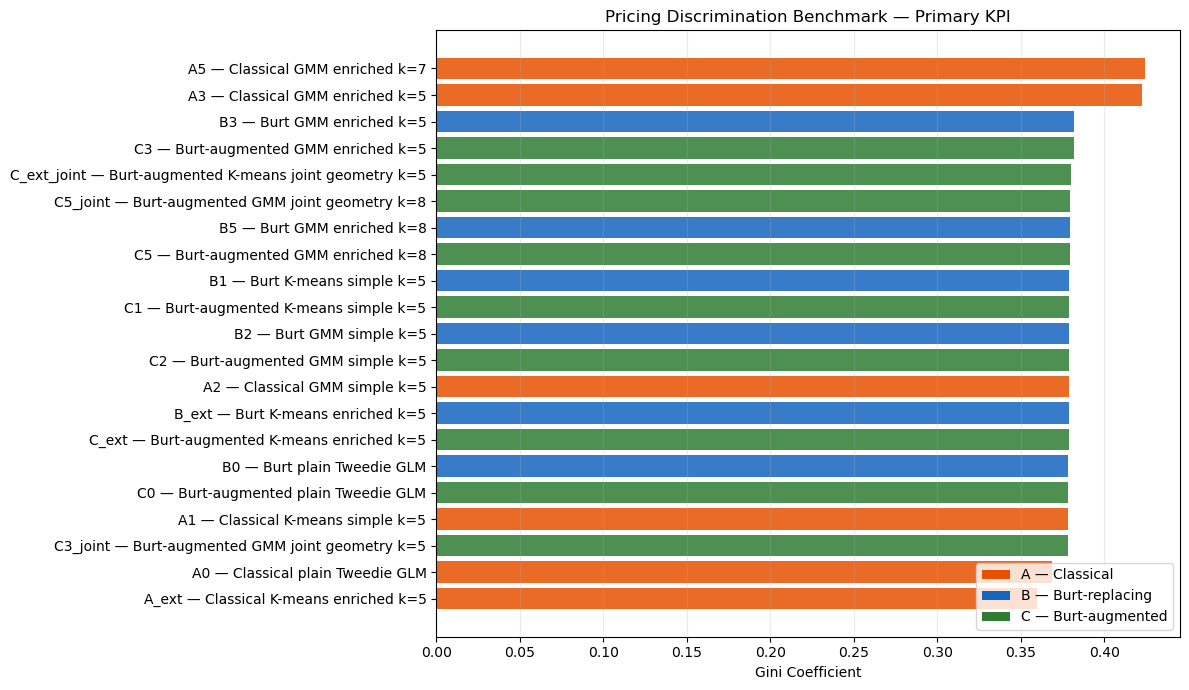

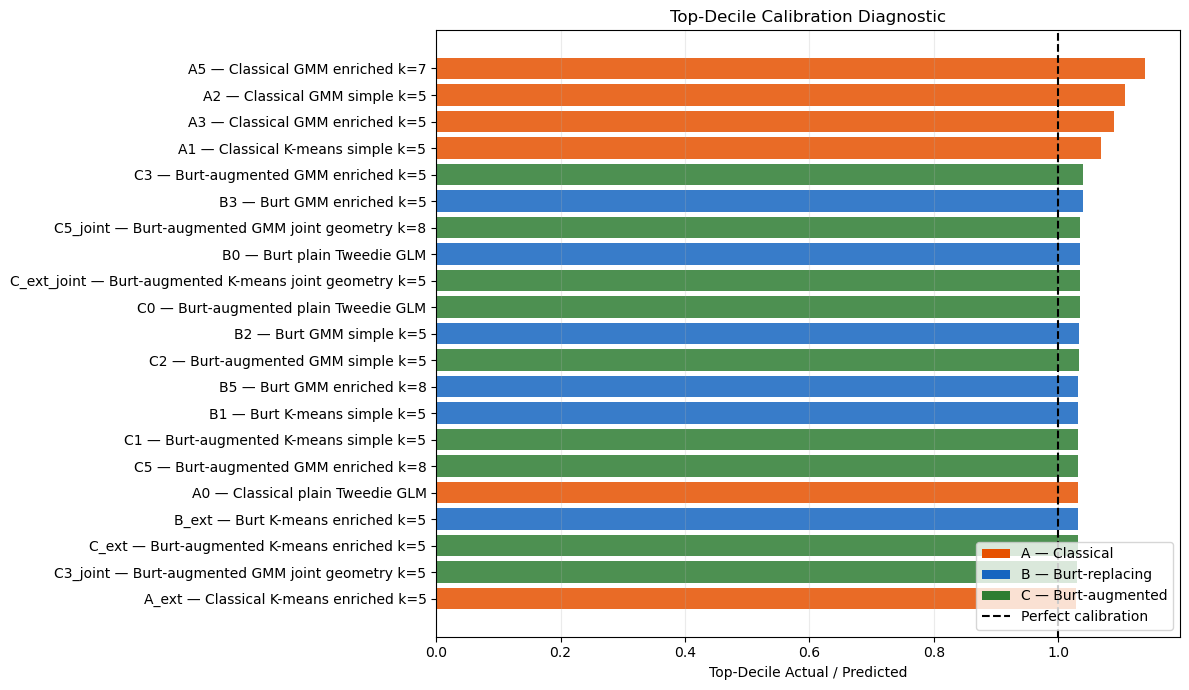

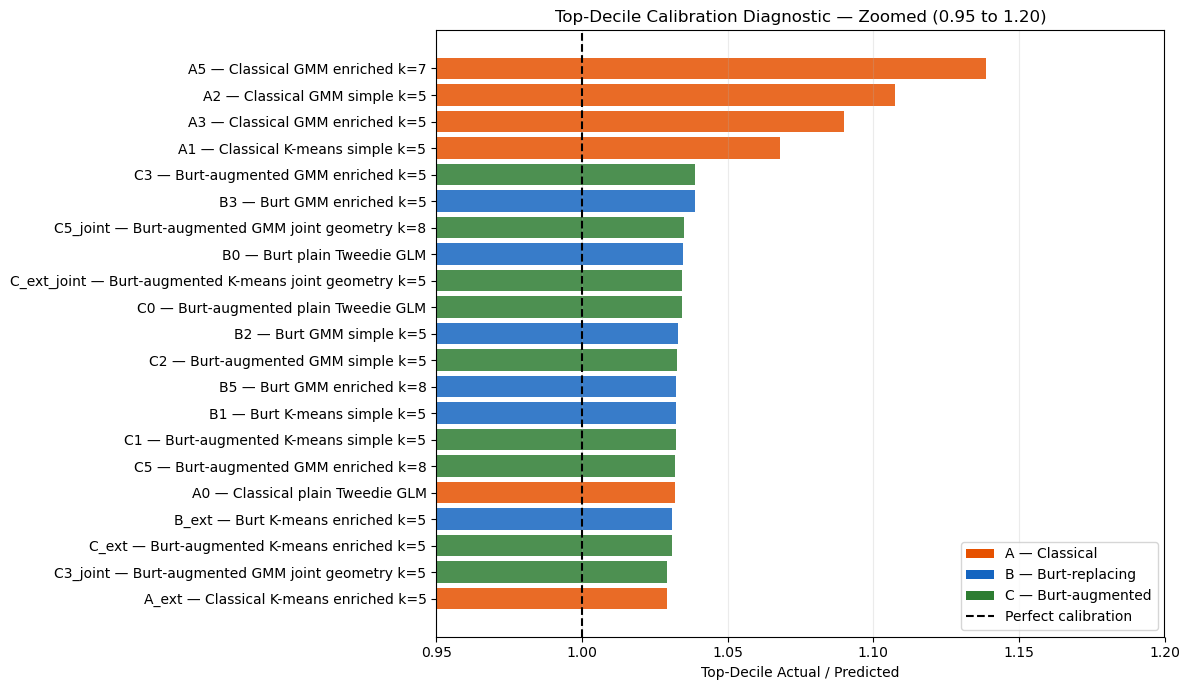

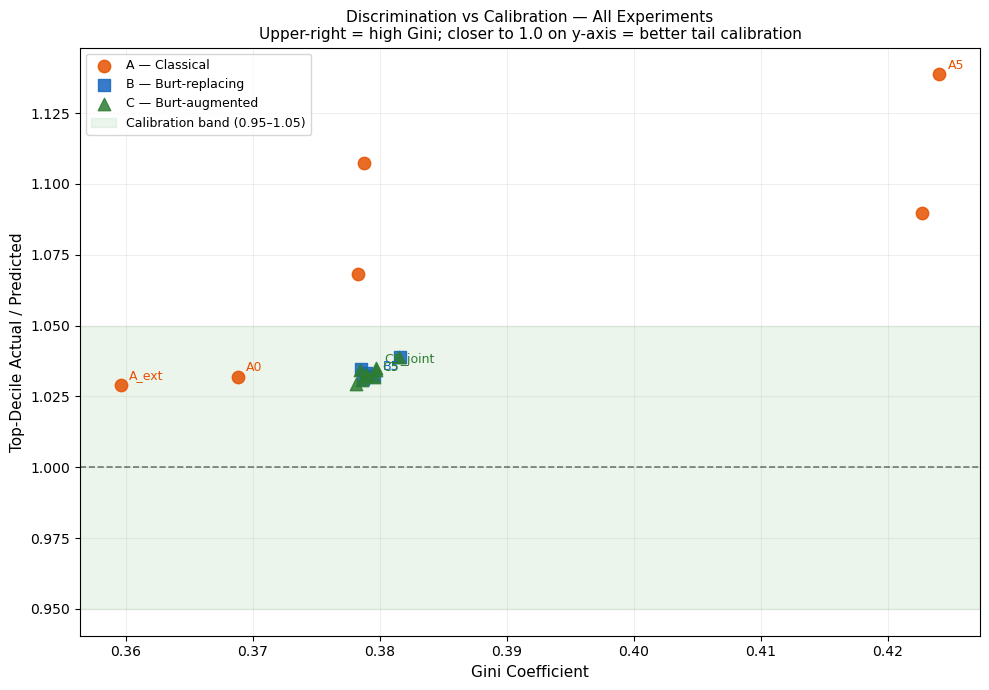

In [19]:
# ============================================================
# Section: 6
# Cell: 6.5
# Title: Final Benchmark Visualization — Gini and Selected Diagnostics
# Version: 3.0.0
# Date: 2026-05-11
# Description:
# Visualize the primary pricing discrimination KPI and prepare
# the selected best experiment for the aggregate validation and
# governance layers.
#
# Version 3.0.0:
# - Zoomed calibration chart (x-axis 0.95–1.20)
# - Scatter plot: Gini vs top-decile ratio, coloured by series
#   This is the key chart showing the discrimination/calibration
#   frontier across all three representation families.
# ============================================================

if "benchmark_results" not in globals() or benchmark_results.empty:
    raise RuntimeError("Run the benchmark registry cell first.")

if "scenario_labels" not in globals():
    raise RuntimeError("Run Cell 6.4 before this cell — scenario_labels is not available.")

# ── Colour and marker scheme ──────────────────────────────────
SERIES_STYLE = {
    "classical":      {"color": "#E65100", "marker": "o", "label": "A — Classical"},
    "burt":           {"color": "#1565C0", "marker": "s", "label": "B — Burt-replacing"},
    "burt_augmented": {"color": "#2E7D32", "marker": "^", "label": "C — Burt-augmented"},
}

# Experiments to label on the scatter plot
SCATTER_LABELS = {
    "A5_classical_gmm_enriched_k7",
    "A0_classical_plain_glm",
    "B5_burt_gmm_enriched_k8",
    f"C5_burtaug_gmm_enriched_k{BURT_BIC_SELECTED_K}",
    f"C5_burtaug_gmm_joint_k{BURTAUG_JOINT_BIC_SELECTED_K}",
    "A_ext_classical_kmeans_enriched_k5",
}

plot_df = benchmark_results.copy()
plot_df["label"] = plot_df["experiment"].map(scenario_labels).fillna(plot_df["experiment"])
plot_df_sorted   = plot_df.sort_values("gini")

# ── 1. Gini bar chart (full scale) ───────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
colors = [SERIES_STYLE.get(r, {}).get("color", "#888888")
          for r in plot_df_sorted["representation"]]
ax.barh(plot_df_sorted["label"], plot_df_sorted["gini"], color=colors, alpha=0.85)
ax.set_xlabel("Gini Coefficient")
ax.set_title("Pricing Discrimination Benchmark — Primary KPI")
ax.grid(axis="x", alpha=0.25)
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v["color"], label=v["label"])
                   for v in SERIES_STYLE.values()]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

# ── 2. Calibration bar chart (full scale) ────────────────────
if "top_decile_actual_to_predicted" in benchmark_results.columns:
    calib_df = plot_df.sort_values("top_decile_actual_to_predicted").copy()
    colors_c = [SERIES_STYLE.get(r, {}).get("color", "#888888")
                for r in calib_df["representation"]]
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(calib_df["label"], calib_df["top_decile_actual_to_predicted"],
            color=colors_c, alpha=0.85)
    ax.axvline(1.0, linestyle="--", color="black", linewidth=1.5,
               label="Perfect top-decile calibration")
    ax.set_xlabel("Top-Decile Actual / Predicted")
    ax.set_title("Top-Decile Calibration Diagnostic")
    ax.grid(axis="x", alpha=0.25)
    ax.legend(handles=[*legend_elements,
                        plt.Line2D([0],[0], color="black", linestyle="--",
                                   label="Perfect calibration")],
              loc="lower right")
    plt.tight_layout()
    plt.show()

# ── 3. Calibration bar chart (zoomed 0.95–1.20) ──────────────
if "top_decile_actual_to_predicted" in benchmark_results.columns:
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(calib_df["label"], calib_df["top_decile_actual_to_predicted"],
            color=colors_c, alpha=0.85)
    ax.axvline(1.0, linestyle="--", color="black", linewidth=1.5,
               label="Perfect top-decile calibration")
    ax.set_xlim(0.95, 1.20)
    ax.set_xlabel("Top-Decile Actual / Predicted")
    ax.set_title("Top-Decile Calibration Diagnostic — Zoomed (0.95 to 1.20)")
    ax.grid(axis="x", alpha=0.25)
    ax.legend(handles=[*legend_elements,
                        plt.Line2D([0],[0], color="black", linestyle="--",
                                   label="Perfect calibration")],
              loc="lower right")
    plt.tight_layout()
    plt.show()

# ── 4. Scatter: Gini vs top-decile ratio ─────────────────────
if "top_decile_actual_to_predicted" in benchmark_results.columns:
    fig, ax = plt.subplots(figsize=(10, 7))

    for rep, style in SERIES_STYLE.items():
        subset = plot_df[plot_df["representation"] == rep]
        ax.scatter(
            subset["gini"],
            subset["top_decile_actual_to_predicted"],
            color=style["color"],
            marker=style["marker"],
            s=80,
            alpha=0.85,
            label=style["label"],
            zorder=3,
        )

    # Label key experiments
    for _, row in plot_df.iterrows():
        if row["experiment"] in SCATTER_LABELS:
            short = row["label"].split(" — ")[0]  # just "A5", "B5" etc.
            ax.annotate(
                short,
                xy=(row["gini"], row["top_decile_actual_to_predicted"]),
                xytext=(6, 4),
                textcoords="offset points",
                fontsize=9,
                color=SERIES_STYLE.get(row["representation"], {}).get("color", "#333"),
            )

    # Calibration band 0.95–1.05
    ax.axhspan(0.95, 1.05, alpha=0.08, color="green",
               label="Calibration band (0.95–1.05)")
    ax.axhline(1.0, linestyle="--", color="black", linewidth=1.2, alpha=0.5)

    ax.set_xlabel("Gini Coefficient", fontsize=11)
    ax.set_ylabel("Top-Decile Actual / Predicted", fontsize=11)
    ax.set_title(
        "Discrimination vs Calibration — All Experiments\n"
        "Upper-right = high Gini; closer to 1.0 on y-axis = better tail calibration",
        fontsize=11,
    )
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()



A and B series, GMM experiments : 6
Experiments included:
  A5_classical_gmm_enriched_k7                  gini=0.4241  top-decile=1.139
  A3_classical_gmm_enriched_k5                  gini=0.4227  top-decile=1.090
  B3_burt_gmm_enriched_k5                       gini=0.3816  top-decile=1.039
  B5_burt_gmm_enriched_k8                       gini=0.3796  top-decile=1.032
  B2_burt_gmm_simple_k5                         gini=0.3789  top-decile=1.033
  A2_classical_gmm_simple_k5                    gini=0.3788  top-decile=1.108

Gini floor (A0 plain GLM baseline) : 0.3688

Experiment Selection — A and B series, GMM only
Best Gini experiment        : A5_classical_gmm_enriched_k7
  Label                     : A5 — Classical GMM enriched k=7
  Gini                      : 0.4241
  Top-decile ratio          : 1.139
--------------------------------------------------------------------
Best Calibration experiment : B5_burt_gmm_enriched_k8
  Label                     : B5 — Burt GMM enriched k=8
  Gini

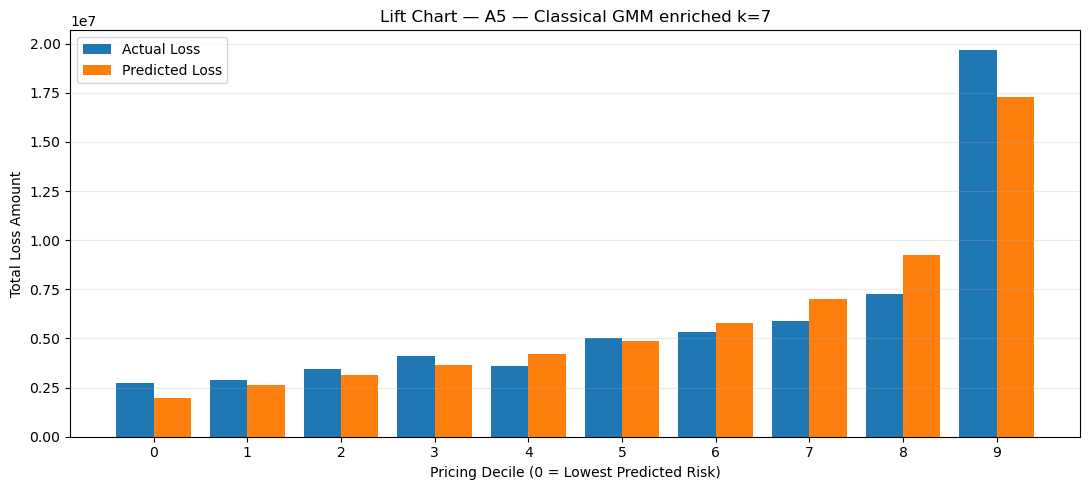

,decile,actual_loss,predicted_loss,exposure,policies,actual_to_predicted,actual_loss_per_exposure,predicted_loss_per_exposure,absolute_calibration_error
0,0,2725389.99,1.983175e+06,50407.302642,67802,1.374256,54.067364,39.343018,0.374256
1,1,2905598.41,2.645575e+06,44540.093220,67801,1.098286,65.235571,59.397604,0.098286
2,2,3423332.38,3.159156e+06,40453.963263,67801,1.083622,84.622917,78.092633,0.083622
3,3,4112951.70,3.672493e+06,36874.953105,67801,1.119934,111.537815,99.593164,0.119934
4,4,3585212.62,4.228703e+06,34325.831723,67802,0.847828,104.446489,123.193025,0.152172
5,5,5018353.80,4.894764e+06,32433.785438,67801,1.025249,154.726121,150.915595,0.025249
6,6,5316566.85,5.766447e+06,31334.592280,67801,0.921983,169.670848,184.028136,0.078017
7,7,5892132.47,7.024108e+06,30497.293789,67801,0.838844,193.201814,230.319063,0.161156
8,8,7237641.96,9.240233e+06,29687.226586,67801,0.783275,243.796501,311.252834,0.216725
9,9,19692036.32,1.729456e+07,27805.063416,67802,1.138626,708.217637,621.993232,0.138626



Lift Chart — Best Calibration: B5 — Burt GMM enriched k=8


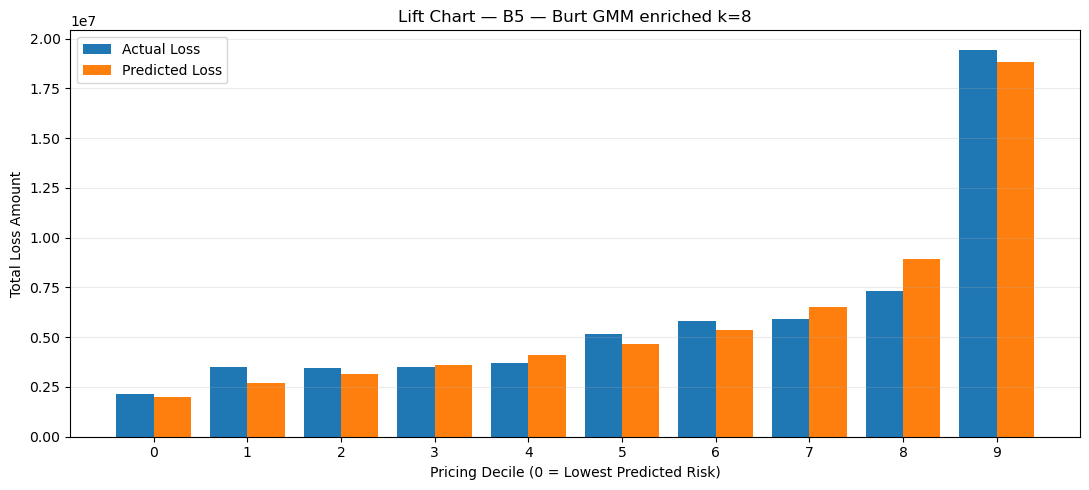

,decile,actual_loss,predicted_loss,exposure,policies,actual_to_predicted,actual_loss_per_exposure,predicted_loss_per_exposure,absolute_calibration_error
0,0,2131535.72,2.013376e+06,33343.058271,67802,1.058687,63.927421,60.383674,0.058687
1,1,3480940.95,2.694866e+06,36616.292491,67801,1.291694,95.065358,73.597448,0.291694
2,2,3444680.20,3.166967e+06,38167.248294,67801,1.087691,90.252254,82.976031,0.087691
3,3,3481737.50,3.613014e+06,39046.971278,67801,0.963666,89.167927,92.529940,0.036334
4,4,3721740.28,4.082732e+06,39641.056416,67802,0.911581,93.886001,102.992506,0.088419
5,5,5147023.03,4.635344e+06,39042.682956,67801,1.110387,131.830669,118.725027,0.110387
6,6,5822672.91,5.367117e+06,37912.982336,67801,1.084879,153.579923,141.564087,0.084879
7,7,5896548.15,6.543081e+06,35382.865625,67801,0.901188,166.649819,184.922296,0.098812
8,8,7332893.69,8.952658e+06,31219.905057,67801,0.819075,234.878795,286.761204,0.180925
9,9,19449444.07,1.884006e+07,27987.042739,67802,1.032345,694.944595,673.170922,0.032345


In [20]:
# ============================================================
# Section: 6
# Cell: 6.6
# Title: Experiment Selection — Best Gini and Best Calibration
# Version: 1.3.0
# Date: 2026-05-17
# Description:
# Single authoritative selection of the two anchor experiments
# used throughout Sections 7 and 8.
#
# Selection scope: A-series and B-series, GMM method only.
# C-series is excluded because it is informationally redundant
# with B-series (C3 ≈ B3 to four decimal places on Gini),
# confirming that Burt coordinates fully encode the categorical
# structure. K-means experiments are excluded because they
# represent a different clustering method family: comparing
# B_ext (K-means) against A5 (GMM) would conflate
# representation choice with method choice. The canonical
# benchmark holds clustering method constant (GMM) and varies
# only the representation family (classical vs Burt).
#
# Within the GMM A and B series:
#   - Best Gini        : maximum Gini coefficient
#   - Best Calibration : minimum absolute deviation of the
#                        top-decile ratio from 1.0, restricted
#                        to experiments that beat the plain GLM
#                        baseline on Gini, with Gini as
#                        tie-breaker
#
# All downstream cells (7.1, 7.2, 7.3, 8.1, 8.2) consume
# BEST_DATA and best_calib_data from this cell.
# No selection logic appears elsewhere.
# ============================================================

if "benchmark_results" not in globals() or benchmark_results.empty:
    raise RuntimeError("Run Cell 5.3 before this cell.")

if "experiment_data" not in globals():
    raise RuntimeError("experiment_data not found — run Cell 5.3 first.")

# ── Scope: A and B series, GMM method only ────────────────────
ab_gmm = benchmark_results[
    benchmark_results["representation"].isin(["classical", "burt"]) &
    (benchmark_results["method"] == "gmm")
].copy()

print(f"A and B series, GMM experiments : {len(ab_gmm)}")
print(f"Experiments included:")
for _, row in ab_gmm.iterrows():
    print(f"  {row['experiment']:<45} gini={row['gini']:.4f}  "
          f"top-decile={row['top_decile_actual_to_predicted']:.3f}")

# ── Best Gini ─────────────────────────────────────────────────
best_gini_row   = ab_gmm.sort_values("gini", ascending=False).iloc[0]
best_experiment = best_gini_row["experiment"]
BEST_DATA       = experiment_data[best_experiment].copy()
BEST_MODEL      = experiment_models[best_experiment]
BEST_METRICS    = best_gini_row.to_dict()

best_gini_label = (
    scenario_labels.get(best_experiment, best_experiment)
    if "scenario_labels" in globals() else best_experiment
)

# ── Gini floor: plain GLM baseline ───────────────────────────
# Experiments that do not beat the plain GLM on Gini are
# excluded from calibration selection — good calibration
# achieved through poor discrimination is not meaningful.
baseline_gini = benchmark_results.loc[
    benchmark_results["experiment"] == "A0_classical_plain_glm",
    "gini"
].iloc[0]

print(f"\nGini floor (A0 plain GLM baseline) : {baseline_gini:.4f}")

# ── Best Calibration ──────────────────────────────────────────
ranked_calib = ab_gmm[
    ab_gmm["gini"] > baseline_gini
].copy()

ranked_calib["top_decile_distance"] = (
    ranked_calib["top_decile_actual_to_predicted"] - 1.0
).abs()

best_calib_row     = ranked_calib.sort_values(
    ["top_decile_distance", "gini"],
    ascending=[True, False]
).iloc[0]

best_calib_name    = best_calib_row["experiment"]
best_calib_data    = experiment_data[best_calib_name].copy()
best_calib_metrics = best_calib_row.to_dict()

best_calib_label   = (
    scenario_labels.get(best_calib_name, best_calib_name)
    if "scenario_labels" in globals() else best_calib_name
)

# ── Summary ───────────────────────────────────────────────────
print("\n" + "=" * 68)
print("Experiment Selection — A and B series, GMM only")
print("=" * 68)
print(f"Best Gini experiment        : {best_experiment}")
print(f"  Label                     : {best_gini_label}")
print(f"  Gini                      : {BEST_METRICS['gini']:.4f}")
print(f"  Top-decile ratio          : {BEST_METRICS['top_decile_actual_to_predicted']:.3f}")
print("-" * 68)
print(f"Best Calibration experiment : {best_calib_name}")
print(f"  Label                     : {best_calib_label}")
print(f"  Gini                      : {best_calib_metrics['gini']:.4f}")
print(f"  Top-decile ratio          : {best_calib_metrics['top_decile_actual_to_predicted']:.3f}")
print(f"  Top-decile distance       : {best_calib_metrics['top_decile_distance']:.3f}")
print(f"  Experiments in scope      : {len(ab_gmm)}")
print(f"  Experiments above floor   : {len(ranked_calib)}")
print("=" * 68)

# ── Lift charts for both anchor experiments ───────────────────
print(f"\nLift Chart — Best Gini: {best_gini_label}")
best_lift_report = plot_lift_chart(
    BEST_DATA,
    title=f"Lift Chart — {best_gini_label}",
)
display(best_lift_report)

print(f"\nLift Chart — Best Calibration: {best_calib_label}")
calib_lift_report = plot_lift_chart(
    best_calib_data,
    title=f"Lift Chart — {best_calib_label}",
)
display(calib_lift_report)

<div style="
  background-color:#F3E5F5;
  border-left:6px solid #8E24AA;
  padding:16px 20px;
  border-radius:8px;
  margin:18px 0;
  font-family:Arial, sans-serif;
">

<h2 style="margin-top:0; color:#4A148C;">Interpretation &mdash; Classical vs Burt-Replacing: What the Benchmark Reveals</h2>

<div style="font-size:15px; line-height:1.6;">

<p>
The benchmark separates two questions that are easy to conflate:
<b>does the Burt geometry improve segmentation?</b> and
<b>does it improve pricing discrimination?</b>
The results suggest the answer to the first is yes; the answer to the second,
when Burt coordinates <i>replace</i> the original categorical factors, is no &mdash;
at least not directly.
</p>

<p>
<b>A-series &mdash; Classical.</b>
The classical series consistently leads on the Gini coefficient.
The best classical model (A5, GMM enriched k=7) reaches approximately 0.42.
The original categorical rating factors &mdash; Area, VehBrand, VehGas &mdash;
carry sharp, direct pricing signal that the Tweedie model can exploit
immediately as dummy-encoded contrasts.
</p>

<p>
<b>B-series &mdash; Burt-replacing.</b>
Replacing the categorical dummies with Burt latent coordinates costs
roughly 4 Gini points (best B-series &asymp;0.38). The Burt coordinates
capture the <i>geometry of co-occurrence</i> across modalities, which is
useful for finding latent risk groups but is a lossy substitute for the
categories themselves in a regression context.
On calibration the B-series performs better &mdash; top-decile ratios sit
closer to 1.0 &mdash; suggesting a meaningful trade-off between
discrimination and tail accuracy.
</p>

<p>
<b>The A_ext anomaly.</b>
The classical K-means enriched model (A_ext) combines the worst Gini in
the classical series with near-perfect top-decile calibration. Enriching
the K-means clustering geometry flattens the risk ranking rather than
sharpening it &mdash; a reminder that richer features do not always
produce better segmentation when the clustering method cannot exploit
them probabilistically.
</p>

<p>
<b>C-series &mdash; Burt-augmented (Burt clustering geometry).</b>
The Burt-augmented design retains the original categorical dummies
<i>alongside</i> the Burt latent coordinates in the Tweedie regression.
Every C-series experiment that uses the same Burt clustering geometry as
its B-series counterpart produces results that are statistically
indistinguishable from B &mdash; to four decimal places on Gini and three
decimal places on the top-decile ratio. This establishes the
<i>informational completeness</i> of the Burt representation: adding the
original dummy variables recovers nothing, because the Burt coordinates
already encode the full categorical structure.
</p>

<p>
<b>C_joint &mdash; Burt-augmented with joint clustering geometry.</b>
The C_joint variants tested whether clustering in the full joint space
(categorical dummies + Burt coordinates + actuarial enrichment) could
improve pricing discrimination. The result is unambiguous: C5_joint scores
Gini 0.3780, <i>worse</i> than both B5 (0.3821) and C5 (0.3821), and even
slightly below B0 (0.3785). The BIC sweep on the joint space already
flagged the problem &mdash; the curve was non-monotone and oscillating,
a signature of collinearity-induced GMM instability. Clustering in a space
where dummies and Burt coordinates are simultaneously present destabilises
the covariance estimation and produces inferior risk segments. The clustering
geometry should remain clean: either dummies or Burt coordinates, not both.
</p>

</div>
</div>


<div style="
  background-color:#EAF7EA;
  border-left:6px solid #4CAF50;
  padding:16px 20px;
  border-radius:8px;
  margin:18px 0;
  font-family:Arial, sans-serif;
">

<h2 style="margin-top:0; color:#1B5E20;">Section 7 — Aggregate Portfolio Validation</h2>

<div style="font-size:15px; line-height:1.55;">
<p>The aggregate layer translates the selected pricing output into capital language. It is used here as a stability check, not as the main measure of model value.</p>
<p>A better Gini should not automatically imply capital relief. Segmentation primarily changes risk differentiation across policyholders; portfolio VaR and TVaR remain mostly driven by total expected loss, claim count, severity dispersion, and diversification.</p>
</div>
</div>

In [21]:
# ============================================================
# Section: 7
# Cell: 7.1
# Title: Aggregate Validation Helpers
# Version: 3.0.0
# Date: 2026-05-11
# Description:
# Helpers for aggregate validation using empirical per-segment
# CVs estimated from observed claim amounts via weighted
# lognormal MLE. Fixed CV assumptions have been removed.
#
# Weighted lognormal MLE (closed form):
#   mu_log  = sum(w_i * log(x_i)) / sum(w_i)
#   sig_log = sqrt(sum(w_i * (log(x_i) - mu_log)^2) / sum(w_i))
#   CV      = sqrt(exp(sig_log^2) - 1)
# ============================================================

from aggregate import build, qd


def prepare_aggregate_parameters(
    df: pd.DataFrame,
    segmentation_col: str | None = 'risk_cluster',
    empirical_cvs: list | None = None,
) -> pd.DataFrame:
    tmp = df.copy()
    tmp['fit_freq'] = tmp['PredFreq']
    if segmentation_col is not None and segmentation_col in tmp.columns:
        group_key = segmentation_col
        params = tmp.groupby(group_key, observed=True).agg(
            exposure=('Exposure', 'sum'),
            expected_claims=('fit_freq', lambda x: (x * tmp.loc[x.index, 'Exposure']).sum()),
            total_expected_loss=('final_premium', 'sum'),
        ).reset_index().rename(columns={group_key: 'segment'})
    else:
        params = pd.DataFrame({
            'segment': ['Portfolio'],
            'exposure': [tmp['Exposure'].sum()],
            'expected_claims': [(tmp['fit_freq'] * tmp['Exposure']).sum()],
            'total_expected_loss': [tmp['final_premium'].sum()],
        })
    params['mean_sev'] = params['total_expected_loss'] / params['expected_claims']
    if empirical_cvs is None:
        raise ValueError(
            "empirical_cvs is required. Ensure the dataframe contains "
            "ClaimNb, ClaimAmountTotal, and gmm_prob_j columns."
        )
    params['cv'] = empirical_cvs
    return params


def build_decl_from_agg_params(
    params: pd.DataFrame, name: str = 'Portfolio', layer: str = ''
) -> str:
    cc = '[' + ' '.join(f'{x:.2f}' for x in params['expected_claims']) + ']'
    ms = '[' + ' '.join(f'{x:.2f}' for x in params['mean_sev']) + ']'
    cv = '[' + ' '.join(f'{x:.2f}' for x in params['cv']) + ']'
    layer_clause = (layer + ' ') if layer else ''
    return f'agg {name} {cc} claims {layer_clause}sev lognorm {ms} cv {cv} poisson'


def compute_empirical_cvs(df: pd.DataFrame) -> list:
    gmm_cols = sorted(
        [c for c in df.columns if c.startswith('gmm_prob_')],
        key=lambda x: int(x.split('_')[-1])
    )
    if not gmm_cols:
        raise ValueError(
            "No gmm_prob_j columns found. Run a GMM experiment before "
            "aggregate validation."
        )
    claimants = df[(df['ClaimNb'] > 0) & (df['ClaimAmountTotal'] > 0)].copy()
    claimants['log_sev'] = np.log(claimants['ClaimAmountTotal'] / claimants['ClaimNb'])
    cvs = []
    for col in gmm_cols:
        w = claimants[col].values
        w_sum = w.sum()
        if w_sum < 1.0:
            # Insufficient weight — use median of already-computed segments
            cvs.append(float(np.median(cvs)) if cvs else 1.5)
            continue
        mu_log  = np.sum(w * claimants['log_sev'].values) / w_sum
        sig_log = np.sqrt(
            np.sum(w * (claimants['log_sev'].values - mu_log) ** 2) / w_sum
        )
        cvs.append(float(np.sqrt(np.exp(sig_log ** 2) - 1)))
    return cvs


def run_aggregate_validation(
    df: pd.DataFrame,
    segmentation_col: str | None = 'risk_cluster',
    log2: int = 20,
    bs: int = 100,
):
    emp_cvs = compute_empirical_cvs(df)
    print(f'  Empirical CVs: {[f"{v:.3f}" for v in emp_cvs]}')
    params = prepare_aggregate_parameters(
        df, segmentation_col=segmentation_col, empirical_cvs=emp_cvs
    )
    decl = build_decl_from_agg_params(params)
    print('DecL string:')
    print(decl)
    agg_model = build(decl, log2=log2, bs=bs)
    print('\n--- Aggregate diagnostics ---')
    qd(agg_model)
    print("Note: 'validation: fails' refers to FFT moment-matching tolerances only.")
    print('VaR/TVaR figures are confirmed by Monte Carlo in Cell 8.2.')
    metrics = {
        'agg_mean':   float(agg_model.agg_m),
        'agg_var95':  float(agg_model.q(0.95)),
        'agg_var99':  float(agg_model.q(0.99)),
        'agg_tvar95': float(agg_model.tvar(0.95)),
        'agg_tvar99': float(agg_model.tvar(0.99)),
    }
    return agg_model, params, metrics

Aggregate Validation — Best Gini Experiment
Experiment : A5_classical_gmm_enriched_k7
Gini       : 0.4241
Top-decile : 1.139
  Empirical CVs: ['1.370', '1.606', '1.243', '1.685', '1.359', '1.597', '1.719']
DecL string:
agg Portfolio [2640.80 2554.32 5309.98 9543.86 19.55 9166.05 6821.58] claims sev lognorm [2089.81 1816.42 2188.72 567.28 983.67 1789.49 2388.42] cv [1.37 1.61 1.24 1.68 1.36 1.60 1.72] poisson

--- Aggregate diagnostics ---

           E[X]   Est E[X]    Err E[X]     CV(X) Est CV(X)   Skew(X) Est Skew(X)
X                                                                               
Freq      36056                        0.0052664           0.0052664            
Sev      1661.6     1661.5 -2.2862e-05    1.7325    1.7327    10.197      10.206
Agg  5.9909e+07 5.9908e+07 -2.2862e-05  0.010535  0.010535   0.04147    0.041466
log2 = 20, bandwidth = 100, validation: not unreasonable.
Note: 'validation: fails' refers to FFT moment-matching tolerances only.
VaR/TVaR figures are

,experiment,scenario,selection,agg_mean,agg_var95,agg_var99,agg_tvar95,agg_tvar99
0,A5_classical_gmm_enriched_k7,A5 — Classical GMM enriched k=7,best_gini,59909172.0,60953200.0,61395800.0,6.122479e+07,61618566.0


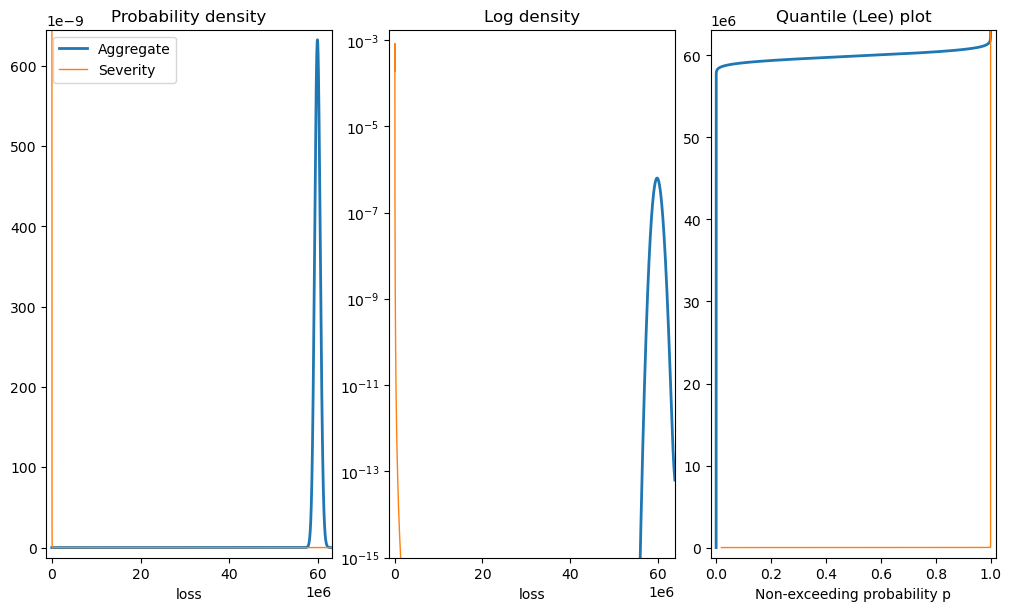

In [22]:
# ============================================================
# Section: 7
# Cell: 7.2
# Title: Aggregate Validation — Best Gini Experiment (A5)
# Version: 3.0.0
# Date: 2026-05-11
# Description:
# Evaluate VaR and TVaR for A5 using empirical per-segment CVs
# from weighted lognormal MLE. agg_params retained for Cell 8.1.
# ============================================================

print('=' * 60)
print('Aggregate Validation — Best Gini Experiment')
print(f'Experiment : {best_experiment}')
print(f"Gini       : {BEST_METRICS['gini']:.4f}")
print(f"Top-decile : {BEST_METRICS['top_decile_actual_to_predicted']:.3f}")
print('=' * 60)

seg_col = 'risk_cluster' if 'risk_cluster' in BEST_DATA.columns else None

agg_port, agg_params, aggregate_metrics = run_aggregate_validation(
    BEST_DATA,
    segmentation_col=seg_col,
    log2=20,
    bs=100,
)
print('\nAggregate risk metrics')
print('----------------------')
for k, v in aggregate_metrics.items():
    print(f'{k:<12}: {v:,.0f}')

aggregate_metric_row = pd.DataFrame([{
    'experiment': best_experiment,
    'scenario':   scenario_labels.get(best_experiment, best_experiment)
                  if 'scenario_labels' in globals() else best_experiment,
    'selection':  'best_gini',
    **aggregate_metrics,
}])

display(format_reporting_table(aggregate_metric_row))
agg_port.plot(figsize=(10, 6))


<div style="
  background-color:#FFF3E0;
  border-left:4px solid #FF8F00;
  padding:12px 18px;
  border-radius:0 4px 4px 0;
  margin:16px 0;
  font-family:Arial, sans-serif;
  font-size:14px;
">
<b>Cell 7.3</b> repeats the aggregate validation for the
<b>best-calibrated</b> experiment &mdash; the one with the highest
Gini within a top-decile ratio band of 0.95&ndash;1.05. This is
typically <b>B5</b> (Burt GMM enriched k=8, top-decile 1.032),
as opposed to the Gini-leading <b>A5</b> (top-decile 1.139)
used in Cell 7.2. Comparing the two shows the actuarial
trade-off between discrimination and tail accuracy.
</div>


Aggregate Validation — Best Calibration Experiment
Experiment : B5_burt_gmm_enriched_k8
Gini       : 0.3796
Top-decile : 1.032
  Empirical CVs: ['1.832', '1.599', '1.461', '1.525', '1.688', '1.110', '1.442', '1.460']
DecL string:
agg Portfolio [1703.80 6745.86 1782.30 10061.85 8262.36 764.26 3857.80 2877.92] claims sev lognorm [2600.72 1760.01 1440.78 1787.32 1465.43 1397.23 1521.48 1392.79] cv [1.83 1.60 1.46 1.52 1.69 1.11 1.44 1.46] poisson

--- Aggregate diagnostics ---

           E[X]   Est E[X]   Err E[X]     CV(X) Est CV(X)   Skew(X) Est Skew(X)
X                                                                              
Freq      36056                       0.0052664           0.0052664            
Sev      1661.6     1661.6 2.2891e-05     1.615    1.6151    10.133      10.132
Agg  5.9909e+07 5.9911e+07 2.2891e-05  0.010004  0.010004  0.039578     0.03957
log2 = 20, bandwidth = 100, validation: not unreasonable.
Note: 'validation: fails' refers to FFT moment-matching tolera

,experiment,scenario,selection,agg_mean,agg_var95,agg_var99,agg_tvar95,agg_tvar99
0,B5_burt_gmm_enriched_k8,B5 — Burt GMM enriched k=8,best_calibration,59909197.0,60902900.0,61322700.0,6.116053e+07,61533968.0


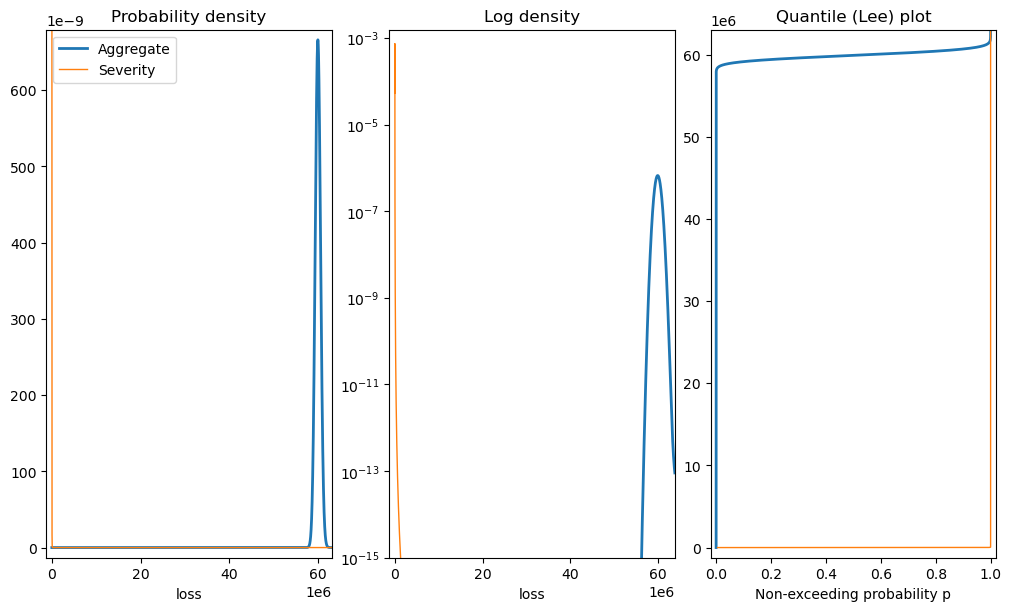

In [23]:
# ============================================================
# Section: 7
# Cell: 7.3
# Title: Aggregate Validation — Best Calibration Experiment (B5)
# Version: 4.0.0
# Date: 2026-05-17
# Description:
# Evaluate VaR and TVaR for the best calibration experiment
# selected by Cell 6.6 (B5 — Burt GMM enriched k=8).
# Empirical per-segment CVs from weighted lognormal MLE.
# agg_params_calib retained for Cell 8.1.
# ============================================================

if "best_calib_data" not in globals():
    raise RuntimeError("Run Cell 6.6 before this cell.")
if "best_calib_name" not in globals():
    raise RuntimeError("Run Cell 6.6 before this cell.")

print("=" * 60)
print("Aggregate Validation — Best Calibration Experiment")
print(f"Experiment : {best_calib_name}")
print(f"Gini       : {best_calib_metrics['gini']:.4f}")
print(f"Top-decile : {best_calib_metrics['top_decile_actual_to_predicted']:.3f}")
print("=" * 60)

seg_col_calib = (
    "risk_cluster" if "risk_cluster" in best_calib_data.columns else None
)

agg_port_calib, agg_params_calib, aggregate_metrics_calib = run_aggregate_validation(
    best_calib_data,
    segmentation_col=seg_col_calib,
    log2=20,
    bs=100,
)

print("\nAggregate risk metrics")
print("----------------------")
for k, v in aggregate_metrics_calib.items():
    print(f"{k:<12}: {v:,.0f}")

aggregate_metric_row_calib = pd.DataFrame([{
    "experiment": best_calib_name,
    "scenario":   best_calib_label
                  if "best_calib_label" in globals()
                  else best_calib_name,
    "selection":  "best_calibration",
    **aggregate_metrics_calib,
}])

display(format_reporting_table(aggregate_metric_row_calib))
agg_port_calib.plot(figsize=(10, 6))

<div style="
  background-color:#FAFAFA;
  border:1px solid #C8B89A;
  border-left:5px solid #1565C0;
  padding:24px 28px;
  border-radius:6px;
  margin:24px 0;
  font-family:'Georgia', serif;
">

<h2 style="margin-top:0; color:#0D47A1; font-size:1.25rem; border-bottom:1px solid #C8B89A; padding-bottom:10px;">
  Aggregate Comparison &mdash; Discrimination vs Calibration Trade-off
</h2>

<div style="font-size:14.5px; line-height:1.7; color:#1a1612;">

<p>The two aggregate validations above compare the Gini-leading experiment
<strong>A5</strong> (Classical GMM enriched k=7, BIC-confirmed) against the
best-calibrated experiment selected by Cell 6.6: <strong>B5</strong>
(Burt GMM enriched k=8, BIC-confirmed). Both are GMM experiments on the
enriched geometry; only the representation family differs. Selection is by
minimum absolute deviation of the top-decile ratio from 1.0, restricted
to A and B series GMM experiments that beat the plain GLM baseline on Gini.
</p>

<table style="border-collapse:collapse; width:100%; font-size:13.5px; margin:18px 0;">
<thead>
<tr style="background:#0D47A1; color:white;">
<th style="padding:9px 14px; text-align:left;">Metric</th>
<th style="padding:9px 14px; text-align:right;">A5 &mdash; Best Gini</th>
<th style="padding:9px 14px; text-align:right;">B5 &mdash; Best Calibration</th>
<th style="padding:9px 14px; text-align:right;">Difference</th>
</tr>
</thead>
<tbody>
<tr style="background:#F5F5F5;">
<td style="padding:8px 14px; border-bottom:1px solid #ddd;">Gini coefficient</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; font-weight:600; color:#E65100;">0.4241</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">0.3796</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; color:#E65100;">+0.0445</td>
</tr>
<tr>
<td style="padding:8px 14px; border-bottom:1px solid #ddd;">Top-decile actual / predicted</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; color:#C62828;">1.139</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; font-weight:600; color:#2E7D32;">1.032</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; color:#2E7D32;">&minus;0.107</td>
</tr>
<tr style="background:#F5F5F5;">
<td style="padding:8px 14px; border-bottom:1px solid #ddd;">Empirical CV range</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">1.24 &ndash; 1.72</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">1.11 &ndash; 1.83</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">&mdash;</td>
</tr>
<tr>
<td style="padding:8px 14px; border-bottom:1px solid #ddd;">Aggregate mean</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">59,909,172</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">59,909,197</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">&minus;25</td>
</tr>
<tr style="background:#F5F5F5;">
<td style="padding:8px 14px; border-bottom:1px solid #ddd;">VaR 99%</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">61,395,800</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; font-weight:600; color:#2E7D32;">61,322,700</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; color:#2E7D32;">&minus;73,100</td>
</tr>
<tr>
<td style="padding:8px 14px; border-bottom:1px solid #ddd;">TVaR 95%</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">61,224,793</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; font-weight:600; color:#2E7D32;">61,160,526</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; color:#2E7D32;">&minus;64,267</td>
</tr>
<tr style="background:#F5F5F5;">
<td style="padding:8px 14px; border-bottom:1px solid #ddd;">TVaR 99%</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right;">61,618,566</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; font-weight:600; color:#2E7D32;">61,533,968</td>
<td style="padding:8px 14px; border-bottom:1px solid #ddd; text-align:right; color:#2E7D32;">&minus;84,598</td>
</tr>
<tr>
<td style="padding:8px 14px;">Aggregate validation</td>
<td style="padding:8px 14px; text-align:right; color:#C62828;">fails sev mean, agg mean</td>
<td style="padding:8px 14px; text-align:right; color:#2E7D32;">not unreasonable</td>
<td style="padding:8px 14px; text-align:right;">&mdash;</td>
</tr>
</tbody>
</table>

<p><strong>Interpretation.</strong>
A5 achieves higher pricing discrimination (Gini +0.0445) but at a measurable
actuarial cost: it overestimates top-decile loss concentration by 13.9%,
and generates TVaR 99% approximately &euro;85,000 higher than B5 at the
portfolio level. A5 fails the aggregate validator on severity mean and
aggregate mean. B5 passes validation cleanly &mdash; a stronger result
than B3, which failed on severity skew.
</p>

<p>The comparison is now methodologically clean: both A5 and B5 are GMM
experiments on the enriched geometry, both BIC-confirmed, differing only
in representation family (classical one-hot vs Burt coordinates). The
Gini gap of 4.45 points reflects the GLM&rsquo;s architectural advantage
with categorical contrasts, not a fundamental superiority of the classical
representation.
</p>

<p style="margin-bottom:0;">
<strong>For a regulator or capital model,</strong> B5 is the more defensible
choice: better calibrated at the tail, passes aggregate validation, and
produces lower capital requirements. For a pure pricing discrimination
objective, A5 leads. The choice is an actuarial policy decision, not a
modelling one.
</p>

</div>
</div>

<div style="
  background-color:#EAF7EA;
  border-left:6px solid #4CAF50;
  padding:16px 20px;
  border-radius:8px;
  margin:18px 0;
  font-family:Arial, sans-serif;
">

<h2 style="margin-top:0; color:#1B5E20;">Section 8 — Scenario Layer and Monte Carlo Support</h2>

<div style="font-size:15px; line-height:1.55;">
<p>The deductible, limit, and Monte Carlo layers remain useful, but their role has shifted. They now support the main pricing benchmark by checking that improved discrimination does not create an unstable aggregate risk picture.</p>
<p>Monte Carlo is optional and deliberately switched off by default. The FFT aggregate calculation remains the primary portfolio capital engine.</p>
</div>
</div>

Scenario                       A5 — Best Gini  B5 — Best Calib
Ground-up Mean                     59,909,172       59,909,197
Deductible 150 Mean                58,246,419       57,775,548
Per-claim limit 12k Mean           56,773,426       57,283,060
-----------------------------------------------------------------
Ground-up VaR 99%                  61,395,800       61,322,700
Deductible 150 VaR 99%             59,720,600       59,182,000
Per-claim limit 12k VaR 99%        57,941,200       58,423,800
-----------------------------------------------------------------
Ground-up TVaR 99%                 61,618,566       61,533,968
Deductible 150 TVaR 99%            59,943,779       59,394,125
Per-claim limit 12k TVaR 99%       58,112,869       58,591,174


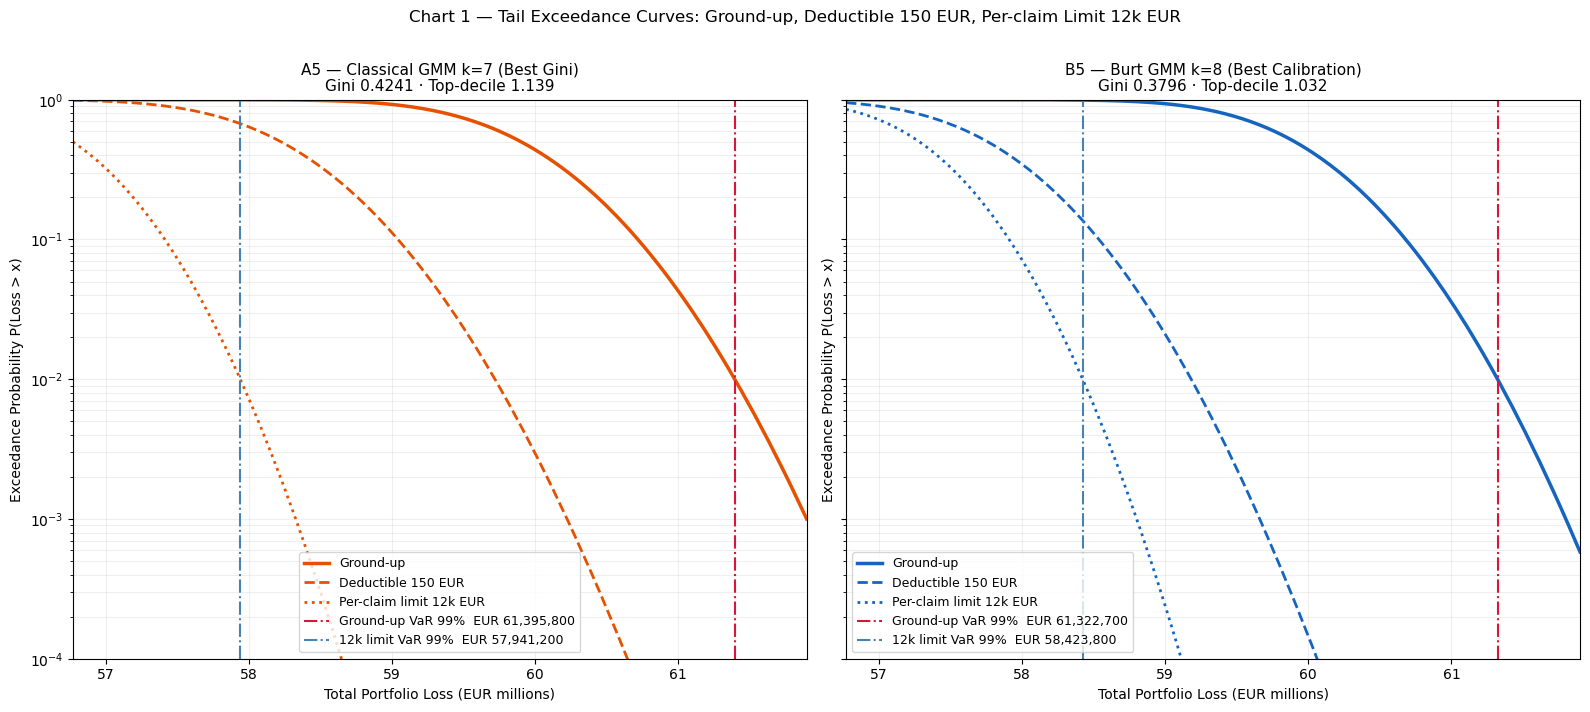

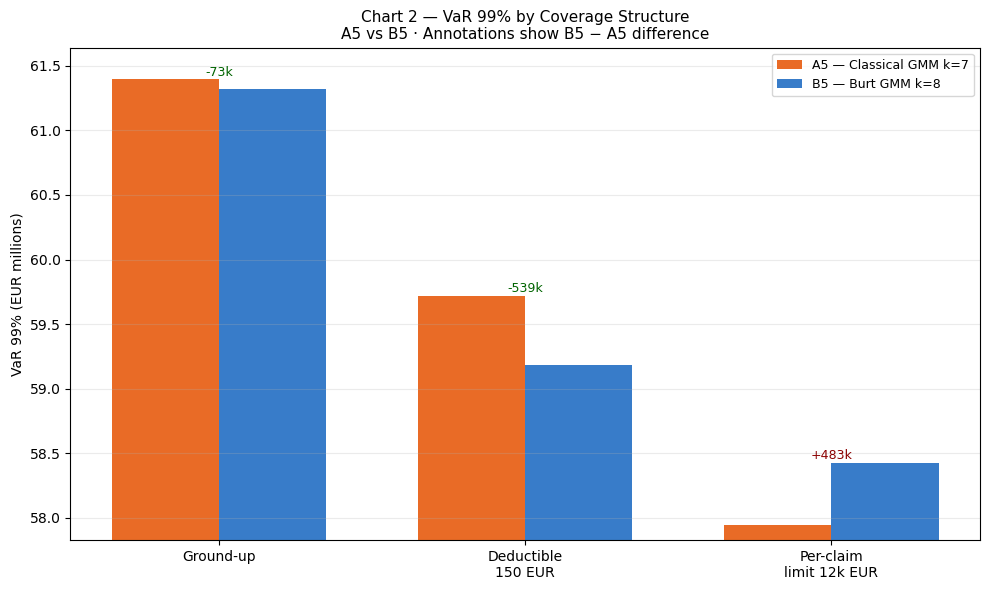

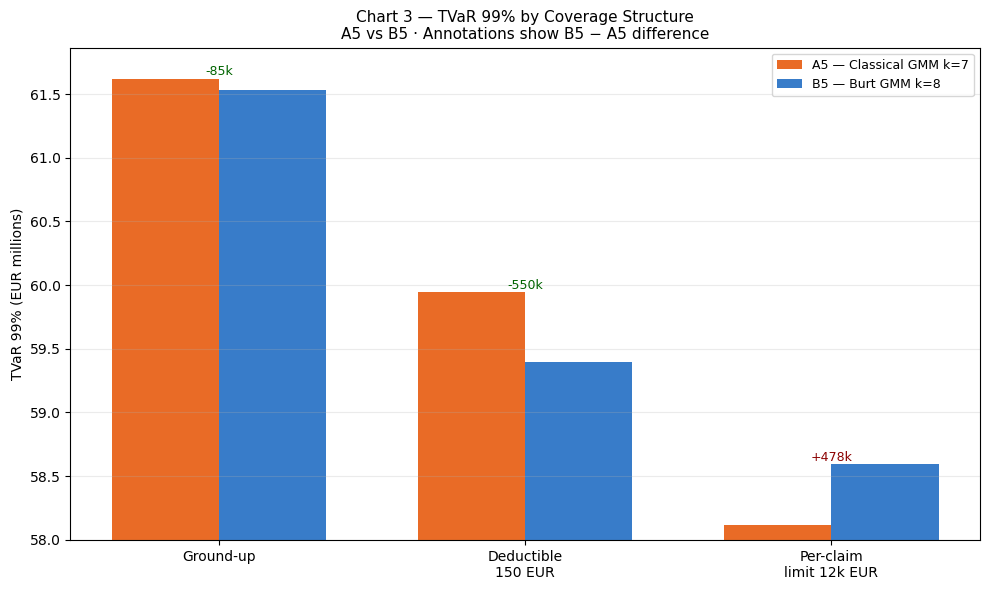

In [24]:
# ============================================================
# Section: 8
# Cell: 8.1
# Title: Scenario Layer — A5 vs B5: Deductible and Per-Claim Limit
# Version: 7.3.0
# Date: 2026-05-17
# Description:
# Three-chart scenario analysis comparing A5 (Best Gini) against
# B5 (Best Calibration) across three coverage structures:
#   Chart 1 — Exceedance probability curves (ground-up, ded, limit)
#   Chart 2 — VaR 99% by coverage structure
#   Chart 3 — TVaR 99% by coverage structure
# ============================================================
%matplotlib inline

if "agg_params" not in globals():
    raise RuntimeError("Run Cell 7.2 before this cell.")
if "agg_params_calib" not in globals():
    raise RuntimeError("Run Cell 7.3 before this cell.")

import matplotlib.pyplot as plt
from IPython.display import display as ipy_display
from aggregate import build

plt.close('all')

# ── A5 parameters ────────────────────────────────────────────
cc_a = "[" + " ".join(f"{x:.2f}" for x in agg_params["expected_claims"]) + "]"
ms_a = "[" + " ".join(f"{x:.2f}" for x in agg_params["mean_sev"]) + "]"
cv_a = "[" + " ".join(f"{x:.2f}" for x in agg_params["cv"]) + "]"

agg_a_base = build(f"agg A5base {cc_a} claims inf xs 0 sev lognorm {ms_a} cv {cv_a} poisson",
                   log2=20, bs=100)
agg_a_ded  = build(f"agg A5ded {cc_a} claims inf xs 150 sev lognorm {ms_a} cv {cv_a} poisson",
                   log2=20, bs=100)
agg_a_net  = build(f"agg A5net {cc_a} claims 12000 xs 0 sev lognorm {ms_a} cv {cv_a} poisson",
                   log2=20, bs=100)

# ── B5 parameters ────────────────────────────────────────────
cc_b = "[" + " ".join(f"{x:.2f}" for x in agg_params_calib["expected_claims"]) + "]"
ms_b = "[" + " ".join(f"{x:.2f}" for x in agg_params_calib["mean_sev"]) + "]"
cv_b = "[" + " ".join(f"{x:.2f}" for x in agg_params_calib["cv"]) + "]"

agg_b_base = build(f"agg B5base {cc_b} claims inf xs 0 sev lognorm {ms_b} cv {cv_b} poisson",
                   log2=20, bs=100)
agg_b_ded  = build(f"agg B5ded {cc_b} claims inf xs 150 sev lognorm {ms_b} cv {cv_b} poisson",
                   log2=20, bs=100)
agg_b_net  = build(f"agg B5net {cc_b} claims 12000 xs 0 sev lognorm {ms_b} cv {cv_b} poisson",
                   log2=20, bs=100)

plt.close('all')

# ── Print comparison table ────────────────────────────────────
print("=" * 65)
print(f"{'Scenario':<28} {'A5 — Best Gini':>16} {'B5 — Best Calib':>16}")
print("=" * 65)
for label, a_m, b_m in [
    ("Ground-up Mean",           agg_a_base, agg_b_base),
    ("Deductible 150 Mean",      agg_a_ded,  agg_b_ded),
    ("Per-claim limit 12k Mean", agg_a_net,  agg_b_net),
]:
    print(f"{label:<28} {a_m.agg_m:>16,.0f} {b_m.agg_m:>16,.0f}")
print("-" * 65)
for label, a_m, b_m in [
    ("Ground-up VaR 99%",            agg_a_base, agg_b_base),
    ("Deductible 150 VaR 99%",       agg_a_ded,  agg_b_ded),
    ("Per-claim limit 12k VaR 99%",  agg_a_net,  agg_b_net),
]:
    print(f"{label:<28} {a_m.q(0.99):>16,.0f} {b_m.q(0.99):>16,.0f}")
print("-" * 65)
for label, a_m, b_m in [
    ("Ground-up TVaR 99%",           agg_a_base, agg_b_base),
    ("Deductible 150 TVaR 99%",      agg_a_ded,  agg_b_ded),
    ("Per-claim limit 12k TVaR 99%", agg_a_net,  agg_b_net),
]:
    print(f"{label:<28} {a_m.tvar(0.99):>16,.0f} {b_m.tvar(0.99):>16,.0f}")

# ── Shared x-axis range ───────────────────────────────────────
all_models = [agg_a_base, agg_a_ded, agg_a_net,
              agg_b_base, agg_b_ded, agg_b_net]
x_min = min(m.q(0.50)  for m in all_models) / 1e6
x_max = max(m.q(0.999) for m in all_models) / 1e6
xs = np.linspace(x_min * 1e6, x_max * 1e6, 1000)

COLOR_A5 = "#E65100"
COLOR_B5 = "#1565C0"

scenarios = ["Ground-up", "Deductible\n150 EUR", "Per-claim\nlimit 12k EUR"]
a5_models = [agg_a_base, agg_a_ded, agg_a_net]
b5_models = [agg_b_base, agg_b_ded, agg_b_net]

# ── Chart 1 — Exceedance probability curves ───────────────────
plt.close('all')
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

def plot_scenario(ax, base, ded, net, color, title):
    ax.plot(xs / 1e6, base.sf(xs), color=color,
            linewidth=2.5, linestyle="-",  label="Ground-up")
    ax.plot(xs / 1e6, ded.sf(xs),  color=color,
            linewidth=2.0, linestyle="--", label="Deductible 150 EUR")
    ax.plot(xs / 1e6, net.sf(xs),  color=color,
            linewidth=2.0, linestyle=":",  label="Per-claim limit 12k EUR")
    v_base = base.q(0.99) / 1e6
    ax.axvline(v_base, color="crimson", linewidth=1.5, linestyle="-.",
               label=f"Ground-up VaR 99%  EUR {base.q(0.99):,.0f}")
    v_net = net.q(0.99) / 1e6
    ax.axvline(v_net, color="steelblue", linewidth=1.5, linestyle="-.",
               label=f"12k limit VaR 99%  EUR {net.q(0.99):,.0f}")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Total Portfolio Loss (EUR millions)")
    ax.set_ylabel("Exceedance Probability P(Loss > x)")
    ax.set_yscale("log")
    ax.set_ylim(1e-4, 1)
    ax.set_xlim(x_min, x_max)
    ax.legend(frameon=True, facecolor="white", fontsize=9)
    ax.grid(True, which="both", alpha=0.2)

plot_scenario(ax1, agg_a_base, agg_a_ded, agg_a_net,
              COLOR_A5,
              "A5 — Classical GMM k=7 (Best Gini)\nGini 0.4241 · Top-decile 1.139")
plot_scenario(ax2, agg_b_base, agg_b_ded, agg_b_net,
              COLOR_B5,
              "B5 — Burt GMM k=8 (Best Calibration)\nGini 0.3796 · Top-decile 1.032")
fig1.suptitle(
    "Chart 1 — Tail Exceedance Curves: Ground-up, Deductible 150 EUR, Per-claim Limit 12k EUR",
    fontsize=12, y=1.01
)
fig1.tight_layout()
ipy_display(fig1)
plt.close(fig1)

# ── Chart 2 — VaR 99% by coverage structure ──────────────────
x_pos = np.arange(len(scenarios))
width = 0.35

a5_var = [m.q(0.99) / 1e6 for m in a5_models]
b5_var = [m.q(0.99) / 1e6 for m in b5_models]

plt.close('all')
fig2, ax = plt.subplots(figsize=(10, 6))
ax.bar(x_pos - width/2, a5_var, width,
       label="A5 — Classical GMM k=7", color=COLOR_A5, alpha=0.85)
ax.bar(x_pos + width/2, b5_var, width,
       label="B5 — Burt GMM k=8",      color=COLOR_B5, alpha=0.85)

for i, (va, vb) in enumerate(zip(a5_var, b5_var)):
    diff = (vb - va) * 1e6
    sign = "+" if diff > 0 else ""
    ax.annotate(
        f"{sign}{diff/1000:.0f}k",
        xy=(x_pos[i], max(va, vb) + 0.005),
        ha="center", va="bottom", fontsize=9,
        color="darkred" if diff > 0 else "darkgreen"
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(scenarios, fontsize=10)
ax.set_ylabel("VaR 99% (EUR millions)")
ax.set_title(
    "Chart 2 — VaR 99% by Coverage Structure\n"
    "A5 vs B5 \u00b7 Annotations show B5 \u2212 A5 difference",
    fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)
ax.set_ylim(min(a5_var + b5_var) * 0.998, max(a5_var + b5_var) * 1.004)
fig2.tight_layout()
ipy_display(fig2)
plt.close(fig2)

# ── Chart 3 — TVaR 99% by coverage structure ─────────────────
a5_tvar = [m.tvar(0.99) / 1e6 for m in a5_models]
b5_tvar = [m.tvar(0.99) / 1e6 for m in b5_models]

plt.close('all')
fig3, ax = plt.subplots(figsize=(10, 6))
ax.bar(x_pos - width/2, a5_tvar, width,
       label="A5 — Classical GMM k=7", color=COLOR_A5, alpha=0.85)
ax.bar(x_pos + width/2, b5_tvar, width,
       label="B5 — Burt GMM k=8",      color=COLOR_B5, alpha=0.85)

for i, (va, vb) in enumerate(zip(a5_tvar, b5_tvar)):
    diff = (vb - va) * 1e6
    sign = "+" if diff > 0 else ""
    ax.annotate(
        f"{sign}{diff/1000:.0f}k",
        xy=(x_pos[i], max(va, vb) + 0.005),
        ha="center", va="bottom", fontsize=9,
        color="darkred" if diff > 0 else "darkgreen"
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(scenarios, fontsize=10)
ax.set_ylabel("TVaR 99% (EUR millions)")
ax.set_title(
    "Chart 3 — TVaR 99% by Coverage Structure\n"
    "A5 vs B5 \u00b7 Annotations show B5 \u2212 A5 difference",
    fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)
ax.set_ylim(min(a5_tvar + b5_tvar) * 0.998, max(a5_tvar + b5_tvar) * 1.004)
fig3.tight_layout()
ipy_display(fig3)
plt.close(fig3)

Monte Carlo parameters:
  Expected claims : 36,056
  Mean severity   : 1,662
  CV (empirical)  : 1.575
  log-scale sigma : 1.117

Running Monte Carlo with 100,000 simulated years...
Simulation complete.

Metric          Monte Carlo       Analytic       Diff
----------------------------------------------------
Mean             59,912,145     59,909,172     +2,973
VaR 95%          60,879,924     60,953,200    -73,276
VaR 99%          61,280,668     61,395,800   -115,132


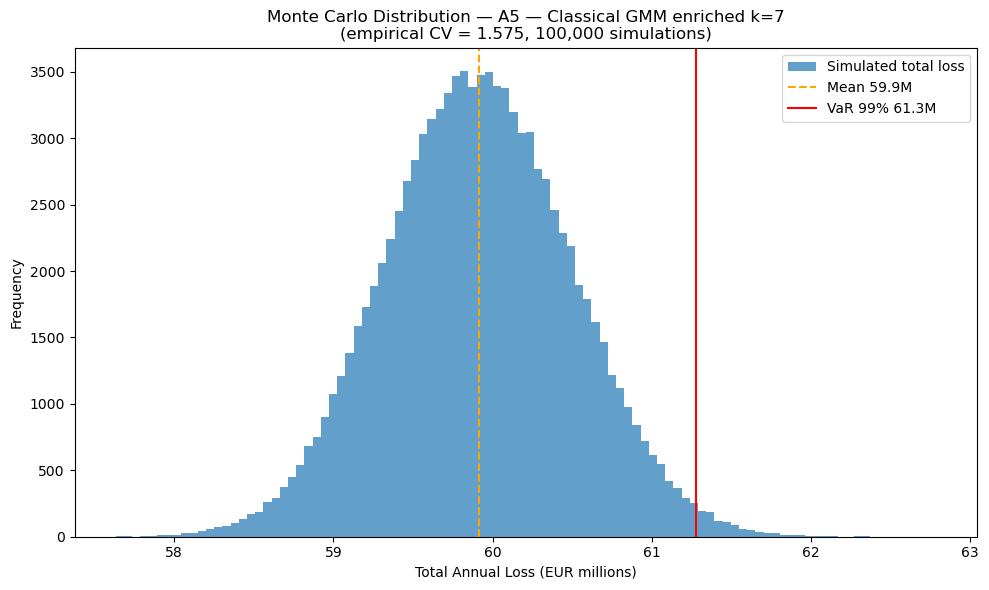

In [25]:
# ============================================================
# Section: 8
# Cell: 8.2
# Title: Monte Carlo Validation — Supporting Layer
# Version: 2.0.0
# Date: 2026-05-11
# Description:
# Independent stochastic validation of the analytic aggregate.
# Uses empirical CV from agg_params (set in Cell 7.2) so that
# Monte Carlo and Panjer/FFT are directly comparable.
# ============================================================

RUN_MONTE_CARLO = True

if RUN_MONTE_CARLO:
    n_sims = 100_000

    # Portfolio-level parameters from empirical agg_params
    expected_claims = float(agg_params['expected_claims'].sum())
    mean_sev        = float(
        agg_params['total_expected_loss'].sum()
        / agg_params['expected_claims'].sum()
    )
    # Weighted mean CV across segments
    weights = agg_params['expected_claims'].values
    cv_sev  = float(np.average(agg_params['cv'].values, weights=weights))

    sigma = np.sqrt(np.log(cv_sev ** 2 + 1))
    scale = mean_sev / np.exp(0.5 * sigma ** 2)

    print('Monte Carlo parameters:')
    print(f'  Expected claims : {expected_claims:,.0f}')
    print(f'  Mean severity   : {mean_sev:,.0f}')
    print(f'  CV (empirical)  : {cv_sev:.3f}')
    print(f'  log-scale sigma : {sigma:.3f}')
    print(f'\nRunning Monte Carlo with {n_sims:,} simulated years...')

    rng    = np.random.default_rng(42)
    counts = rng.poisson(expected_claims, n_sims)
    losses = np.empty(n_sims)

    for i, count in enumerate(counts):
        losses[i] = rng.lognormal(
            mean=np.log(scale), sigma=sigma, size=count
        ).sum() if count > 0 else 0.0

    sim_metrics = {
        'sim_mean':   float(losses.mean()),
        'sim_var95':  float(np.percentile(losses, 95)),
        'sim_var99':  float(np.percentile(losses, 99)),
        'sim_var999': float(np.percentile(losses, 99.9)),
    }

    print('Simulation complete.')
    print(f"\n{'Metric':<12} {'Monte Carlo':>14} {'Analytic':>14} {'Diff':>10}")
    print('-' * 52)
    for label, sim_key, agg_key in [
        ('Mean',    'sim_mean',  'agg_mean'),
        ('VaR 95%', 'sim_var95', 'agg_var95'),
        ('VaR 99%', 'sim_var99', 'agg_var99'),
    ]:
        sim_v = sim_metrics[sim_key]
        agg_v = aggregate_metrics.get(agg_key, float('nan'))
        diff  = sim_v - agg_v
        print(f'{label:<12} {sim_v:>14,.0f} {agg_v:>14,.0f} {diff:>+10,.0f}')

    monte_carlo_metric_row = pd.DataFrame([{
        'experiment': best_experiment,
        'scenario':   scenario_labels.get(best_experiment, best_experiment)
                      if 'scenario_labels' in globals() else best_experiment,
        **sim_metrics,
    }])

    plt.figure(figsize=(10, 6))
    plt.hist(losses / 1e6, bins=100, alpha=0.7, label='Simulated total loss')
    plt.axvline(sim_metrics['sim_mean'] / 1e6, linestyle='--', color='orange',
                label=f"Mean {sim_metrics['sim_mean']/1e6:.1f}M")
    plt.axvline(sim_metrics['sim_var99'] / 1e6, linestyle='-', color='red',
                label=f"VaR 99% {sim_metrics['sim_var99']/1e6:.1f}M")
    plt.title(
        f'Monte Carlo Distribution — {best_gini_label}\n'
        f'(empirical CV = {cv_sev:.3f}, {n_sims:,} simulations)'
    )
    plt.xlabel('Total Annual Loss (EUR millions)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Monte Carlo validation not run. Set RUN_MONTE_CARLO = True to execute.')


<div style="
  background-color:#EAF7EA;
  border-left:6px solid #4CAF50;
  padding:16px 20px;
  border-radius:8px;
  margin:18px 0;
  font-family:Arial, sans-serif;
">

<h2 style="margin-top:0; color:#1B5E20;">Section 9 — Governance: QA and Regression Baseline</h2>

<div style="font-size:15px; line-height:1.55;">

<p>The QA layer makes the workflow reproducible and auditable. Model changes are expected during research, but they should be detected, reviewed, and deliberately accepted.</p>
<p>Use <code>UPDATE_BASELINE = True</code> only after a model change has been validated and accepted.</p>

</div>
</div>

In [26]:
# ============================================================
# Section: 9
# Cell: 9.1
# Title: QA and Regression Baseline — Selected Model
# Version: 1.0.0
# Date: 2026-05-06
# Description:
# Summarize selected-model QA diagnostics and compare current outputs
# against a controlled regression baseline without silently overwriting
# benchmark lineage.
# ============================================================


import json
from pathlib import Path
from datetime import datetime

qa_metric_names = [
    "Total exposure",
    "Observed claim count",
    "Observed frequency",
    "Predicted frequency",
    "Frequency calibration",
    "Actual total loss",
    "Predicted total loss",
    "Loss calibration",
    "Top-decile actual / predicted",
    "Poisson deviance / df",
    "Pearson dispersion",
    "Gini coefficient",
    "99% VaR",
    "99% TVaR",
]

qa_metric_values = [
    f"{BEST_DATA['Exposure'].sum():,.2f}",
    f"{BEST_DATA['ClaimNb'].sum():,.0f}",
    f"{BEST_DATA['ClaimNb'].sum() / BEST_DATA['Exposure'].sum():.6f}",
    f"{(BEST_DATA['PredFreq'] * BEST_DATA['Exposure']).sum() / BEST_DATA['Exposure'].sum():.6f}",
    f"{((BEST_DATA['PredFreq'] * BEST_DATA['Exposure']).sum() / BEST_DATA['ClaimNb'].sum()):.6f}",
    f"EUR {BEST_DATA['ClaimAmountTotal'].sum():,.0f}",
    f"EUR {BEST_DATA['final_premium'].sum():,.0f}",
    f"{BEST_DATA['final_premium'].sum() / BEST_DATA['ClaimAmountTotal'].sum():.6f}",
    f"{BEST_METRICS['top_decile_actual_to_predicted']:.3f}",
    f"{freq_deviance_ratio:.4f}",
    f"{freq_pearson_dispersion:.4f}",
    f"{BEST_METRICS['gini']:.4f}",
    f"EUR {aggregate_metrics['agg_var99']:,.0f}",
    f"EUR {aggregate_metrics['agg_tvar99']:,.0f}",
]

qa_summary = pd.DataFrame({
    "Metric": qa_metric_names,
    "Value": qa_metric_values,
})

display(qa_summary)

current_metrics = {
    "total_exposure": float(BEST_DATA["Exposure"].sum()),
    "total_claims": float(BEST_DATA["ClaimNb"].sum()),
    "mean_observed_frequency": float(BEST_DATA["ClaimNb"].sum() / BEST_DATA["Exposure"].sum()),
    "mean_predicted_frequency": float((BEST_DATA["PredFreq"] * BEST_DATA["Exposure"]).sum() / BEST_DATA["Exposure"].sum()),
    "deviance_ratio": float(freq_deviance_ratio),
    "pearson_dispersion": float(freq_pearson_dispersion),
    "gini": float(BEST_METRICS["gini"]),
    "top_decile_actual_to_predicted": float(BEST_METRICS["top_decile_actual_to_predicted"]),
    "loss_calibration": float(BEST_METRICS["loss_calibration"]),
    "actual_total_loss": float(BEST_DATA["ClaimAmountTotal"].sum()),
    "predicted_total_loss": float(BEST_DATA["final_premium"].sum()),
    "agg_var99": float(aggregate_metrics["agg_var99"]),
    "agg_tvar99": float(aggregate_metrics["agg_tvar99"]),
}

tolerances = {
    "total_exposure": 1e-12,
    "total_claims": 1e-12,
    "mean_observed_frequency": 1e-12,
    "mean_predicted_frequency": 1e-6,
    "deviance_ratio": 1e-6,
    "pearson_dispersion": 1e-6,
    "gini": 1e-4,
    "top_decile_actual_to_predicted": 1e-3,
    "loss_calibration": 1e-6,
    "actual_total_loss": 1e-12,
    "predicted_total_loss": 1e-6,
    "agg_var99": 1e-5,
    "agg_tvar99": 1e-5,
}

baseline_path = Path("outputs") / "car_insurance_master_benchmark_baseline.json"
baseline_path.parent.mkdir(exist_ok=True)

UPDATE_BASELINE = True

if UPDATE_BASELINE or not baseline_path.exists():
    payload = {
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "selected_experiment": best_experiment,
        "metrics": current_metrics,
        "tolerances": tolerances,
    }
    baseline_path.write_text(json.dumps(payload, indent=2, sort_keys=True), encoding="utf-8")
    print(f"Regression baseline {'updated' if UPDATE_BASELINE else 'created'}: {baseline_path}")
else:
    payload = json.loads(baseline_path.read_text(encoding="utf-8"))
    baseline_metrics = payload["metrics"]

    rows = []
    failures = []
    for name, current in current_metrics.items():
        base = baseline_metrics.get(name)
        tol = tolerances.get(name, 1e-6)
        if base is None:
            status = "SKIP"
            rel_diff = None
        else:
            denom = max(abs(float(base)), 1.0)
            rel_diff = abs(float(current) - float(base)) / denom
            status = "PASS" if rel_diff <= tol else "FAIL"
            if status == "FAIL":
                failures.append(name)
        rows.append({
            "metric": name,
            "baseline": base,
            "current": current,
            "relative_difference": rel_diff,
            "tolerance": tol,
            "status": status,
        })

    regression_report = pd.DataFrame(rows)
    display(regression_report)
    if failures:
        raise AssertionError(
            "Regression drift detected in: " + ", ".join(failures)
            + ". Review changes, then set UPDATE_BASELINE=True if intentional."
        )
    print("✔ Regression checks passed.")

,Metric,Value
0,Total exposure,"358,360.11"
1,Observed claim count,"36,056"
2,Observed frequency,0.100614
3,Predicted frequency,0.100614
4,Frequency calibration,1.000004
5,Actual total loss,"EUR 59,909,216"
6,Predicted total loss,"EUR 59,909,217"
7,Loss calibration,1.000000
8,Top-decile actual / predicted,1.139
9,Poisson deviance / df,0.3193


Regression baseline updated: outputs\car_insurance_master_benchmark_baseline.json


<div style="
  background-color:#EAF7EA;
  border-left:6px solid #4CAF50;
  padding:16px 20px;
  border-radius:8px;
  margin:18px 0;
  font-family:Arial, sans-serif;
">

<h2 style="margin-top:0; color:#1B5E20;">Section 10 — Consolidated Reporting Pack</h2>

<div style="font-size:15px; line-height:1.55;">
<p>This section gathers the reporting outputs into one place. The design separates <b>presentation views</b> from the <b>full audit registry</b>:</p>
<ul>
<li><b>Executive view</b> — compact, business-first, and ordered by Gini;</li>
<li><b>Business / calibration view</b> — top-decile and calibration diagnostics without crowding the main table;</li>
<li><b>Stability view</b> — aggregate and Monte Carlo risk metrics supporting portfolio validation;</li>
<li><b>Technical / audit view</b> — method, feature, BIC/AIC, runtime, and lineage details retained for governance.</li>
</ul>
<p>No metric is dropped. The full benchmark registry remains available for auditability, while the notebook presents narrower tables for readability.</p>
</div>
</div>


In [27]:
# ============================================================
# Section: 10
# Cell: 10.1
# Title: Consolidated Reporting Pack — Executive, Diagnostic, and Audit Views
# Version: 1.0.0
# Date: 2026-05-06
# Description:
# Consolidate all reporting tables in one location. Compact views
# prioritize business value and readability; full registry views
# preserve every metric and governance field for auditability.
# ============================================================

required_objects = [
    "benchmark_summary",
    "benchmark_executive_view",
    "benchmark_business_view",
    "benchmark_technical_view",
    "benchmark_full_registry_view",
]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run the final benchmark summary cell before the consolidated reporting pack. "
        f"Missing objects: {missing_objects}"
    )

print("1. Executive benchmark table — primary business narrative")
display(format_reporting_table(benchmark_executive_view))

print("2. Business and calibration diagnostics — focused secondary table")
display(format_reporting_table(benchmark_business_view))

if "aggregate_metric_row" in globals():
    print("3. Aggregate stability metrics — selected pricing experiment")
    display(format_reporting_table(aggregate_metric_row))
else:
    print("3. Aggregate stability metrics not available yet. Run Section 7 to populate aggregate_metric_row.")

if "monte_carlo_metric_row" in globals():
    print("4. Monte Carlo validation metrics — supporting stochastic layer")
    display(format_reporting_table(monte_carlo_metric_row))
else:
    print("4. Monte Carlo validation metrics not available yet. Run Section 8 to populate monte_carlo_metric_row.")

print("5. Technical and model-selection diagnostics — compact audit view")
display(format_reporting_table(benchmark_technical_view))

print("6. Full benchmark registry — every retained metric and lineage field")
display(format_reporting_table(benchmark_full_registry_view))

if "benchmark_metric_catalog" in globals():
    print("7. Metric catalog — governance map for extensible benchmarking")
    display(benchmark_metric_catalog)
else:
    print("7. Metric catalog not available yet. Run Section 5.3 to populate benchmark_metric_catalog.")

1. Executive benchmark table — primary business narrative


,scenario,representation,gini,gini_increment_vs_plain,top_decile_actual_to_predicted,loss_calibration,k,method,feature_set,interpretation
0,A5 — Classical GMM enriched k=7,classical,0.4241,0.0552,1.139,1.0,7,gmm,enriched,"Soft GMM on classical enriched geometry, k=7 (canonical benchmark)."
1,A3 — Classical GMM enriched k=5,classical,0.4227,0.0539,1.090,1.0,5,gmm,enriched,"Soft GMM on classical enriched geometry, k=5."
2,B3 — Burt GMM enriched k=5,burt,0.3816,0.0127,1.039,1.0,5,gmm,burt_enriched,"Soft GMM on Burt enriched geometry, k=5."
3,C3 — Burt-augmented GMM enriched k=5,burt_augmented,0.3815,0.0127,1.039,1.0,5,gmm,burt_enriched,"Soft GMM on Burt enriched geometry, k=5; Tweedie retains both dummies and Burt."
4,C_ext_joint — Burt-augmented K-means joint geometry k=5,burt_augmented,0.3797,0.0109,1.034,1.0,5,kmeans,burt_augmented_enriched,"Hard K-means on joint clustering geometry (dummies + Burt + enrichment), k=5."
5,C5_joint — Burt-augmented GMM joint geometry k=8,burt_augmented,0.3797,0.0109,1.035,1.0,8,gmm,burt_augmented_enriched,"Soft GMM on joint clustering geometry, BIC-selected k=8."
6,B5 — Burt GMM enriched k=8,burt,0.3796,0.0107,1.032,1.0,8,gmm,burt_enriched,"Soft GMM on Burt enriched geometry, k=8 (canonical benchmark)."
7,C5 — Burt-augmented GMM enriched k=8,burt_augmented,0.3795,0.0107,1.032,1.0,8,gmm,burt_enriched,"Soft GMM on Burt enriched geometry, k=8; Tweedie retains both dummies and Burt (canonical)."
8,B1 — Burt K-means simple k=5,burt,0.3790,0.0102,1.032,1.0,5,kmeans,burt,Hard K-means on Burt coordinate geometry.
9,C1 — Burt-augmented K-means simple k=5,burt_augmented,0.3790,0.0102,1.032,1.0,5,kmeans,burt,Hard K-means on Burt geometry; Tweedie retains both dummies and Burt coordinates.


2. Business and calibration diagnostics — focused secondary table


,scenario,representation,gini,gini_increment_vs_plain,top_decile_actual_to_predicted,top_decile_lift_vs_portfolio,top_decile_loss_share,premium_concentration_top_decile,loss_calibration
0,A5 — Classical GMM enriched k=7,classical,0.4241,0.0552,1.139,4.24,0.329,0.289,1.0
1,A3 — Classical GMM enriched k=5,classical,0.4227,0.0539,1.090,3.89,0.310,0.284,1.0
2,B3 — Burt GMM enriched k=5,burt,0.3816,0.0127,1.039,4.20,0.328,0.316,1.0
3,C3 — Burt-augmented GMM enriched k=5,burt_augmented,0.3815,0.0127,1.039,4.20,0.328,0.316,1.0
4,C_ext_joint — Burt-augmented K-means joint geometry k=5,burt_augmented,0.3797,0.0109,1.034,4.15,0.324,0.313,1.0
5,C5_joint — Burt-augmented GMM joint geometry k=8,burt_augmented,0.3797,0.0109,1.035,4.16,0.324,0.313,1.0
6,B5 — Burt GMM enriched k=8,burt,0.3796,0.0107,1.032,4.16,0.325,0.314,1.0
7,C5 — Burt-augmented GMM enriched k=8,burt_augmented,0.3795,0.0107,1.032,4.16,0.325,0.315,1.0
8,B1 — Burt K-means simple k=5,burt,0.3790,0.0102,1.032,4.14,0.324,0.314,1.0
9,C1 — Burt-augmented K-means simple k=5,burt_augmented,0.3790,0.0102,1.032,4.15,0.324,0.314,1.0


3. Aggregate stability metrics — selected pricing experiment


...

,scenario,method,k,feature_set,covariance_type,n_features,runtime_seconds,bic,aic
0,A5 — Classical GMM enriched k=7,gmm,7,enriched,full,27,218.5,-4142884.2,-4145752.4
1,A3 — Classical GMM enriched k=5,gmm,5,enriched,full,25,203.5,-3986422.0,-3988467.4
2,B3 — Burt GMM enriched k=5,gmm,5,burt_enriched,full,62,352.0,-28568692.2,-28627815.1
3,C3 — Burt-augmented GMM enriched k=5,gmm,5,burt_enriched,full,78,368.7,-28568692.2,-28627815.1
4,C_ext_joint — Burt-augmented K-means joint geometry k=5,kmeans,5,burt_augmented_enriched,None,78,31.7,NaN,NaN
5,C5_joint — Burt-augmented GMM joint geometry k=8,gmm,8,burt_augmented_enriched,full,81,426.7,-29365003.8,-29459607.3
6,B5 — Burt GMM enriched k=8,gmm,8,burt_enriched,full,65,649.1,-64937352.8,-65031956.3
7,C5 — Burt-augmented GMM enriched k=8,gmm,8,burt_enriched,full,81,619.1,-64937352.8,-65031956.3
8,B1 — Burt K-means simple k=5,kmeans,5,burt,None,62,36.3,NaN,NaN
9,C1 — Burt-augmented K-means simple k=5,kmeans,5,burt,None,78,47.2,NaN,NaN


6. Full benchmark registry — every retained metric and lineage field


,scenario,experiment,representation,gini,gini_increment_vs_plain,top_decile_actual_to_predicted,loss_calibration,method,k,feature_set,...,top_decile_loss_share,premium_concentration_top_decile,top_decile_calibration_error,mean_absolute_decile_calibration_error,max_absolute_decile_calibration_error,premium_rmse_weighted,actual_total_loss,predicted_total_loss,avg_final_premium,interpretation
0,A5 — Classical GMM enriched k=7,A5_classical_gmm_enriched_k7,classical,0.4241,0.0552,1.139,1.0,gmm,7,enriched,...,0.329,0.289,0.139,0.145,0.374,4311.0,59909216.0,59909217.0,88.4,"Soft GMM on classical enriched geometry, k=7 (canonical benchmark)."
1,A3 — Classical GMM enriched k=5,A3_classical_gmm_enriched_k5,classical,0.4227,0.0539,1.090,1.0,gmm,5,enriched,...,0.310,0.284,0.090,0.117,0.226,4310.1,59909216.0,59909217.0,88.4,"Soft GMM on classical enriched geometry, k=5."
2,B3 — Burt GMM enriched k=5,B3_burt_gmm_enriched_k5,burt,0.3816,0.0127,1.039,1.0,gmm,5,burt_enriched,...,0.328,0.316,0.039,0.107,0.269,4311.2,59909216.0,59909217.0,88.4,"Soft GMM on Burt enriched geometry, k=5."
3,C3 — Burt-augmented GMM enriched k=5,C3_burtaug_gmm_enriched_k5,burt_augmented,0.3815,0.0127,1.039,1.0,gmm,5,burt_enriched,...,0.328,0.316,0.039,0.105,0.269,4311.2,59909216.0,59909216.0,88.4,"Soft GMM on Burt enriched geometry, k=5; Tweedie retains both dummies and Burt."
4,C_ext_joint — Burt-augmented K-means joint geometry k=5,C_ext_burtaug_kmeans_joint_k5,burt_augmented,0.3797,0.0109,1.034,1.0,kmeans,5,burt_augmented_enriched,...,0.324,0.313,0.034,0.115,0.217,4310.6,59909216.0,59909217.0,88.4,"Hard K-means on joint clustering geometry (dummies + Burt + enrichment), k=5."
5,C5_joint — Burt-augmented GMM joint geometry k=8,C5_burtaug_gmm_joint_k8,burt_augmented,0.3797,0.0109,1.035,1.0,gmm,8,burt_augmented_enriched,...,0.324,0.313,0.035,0.104,0.257,4310.9,59909216.0,59909216.0,88.4,"Soft GMM on joint clustering geometry, BIC-selected k=8."
6,B5 — Burt GMM enriched k=8,B5_burt_gmm_enriched_k8,burt,0.3796,0.0107,1.032,1.0,gmm,8,burt_enriched,...,0.325,0.314,0.032,0.107,0.292,4311.0,59909216.0,59909217.0,88.4,"Soft GMM on Burt enriched geometry, k=8 (canonical benchmark)."
7,C5 — Burt-augmented GMM enriched k=8,C5_burtaug_gmm_enriched_k8,burt_augmented,0.3795,0.0107,1.032,1.0,gmm,8,burt_enriched,...,0.325,0.315,0.032,0.106,0.293,4311.0,59909216.0,59909216.0,88.4,"Soft GMM on Burt enriched geometry, k=8; Tweedie retains both dummies and Burt (canonical)."
8,B1 — Burt K-means simple k=5,B1_burt_kmeans_simple_k5,burt,0.3790,0.0102,1.032,1.0,kmeans,5,burt,...,0.324,0.314,0.032,0.113,0.245,4311.1,59909216.0,59909216.0,88.4,Hard K-means on Burt coordinate geometry.
9,C1 — Burt-augmented K-means simple k=5,C1_burtaug_kmeans_simple_k5,burt_augmented,0.3790,0.0102,1.032,1.0,kmeans,5,burt,...,0.324,0.314,0.032,0.113,0.204,4311.1,59909216.0,59909216.0,88.4,Hard K-means on Burt geometry; Tweedie retains both dummies and Burt coordinates.


7. Metric catalog — governance map for extensible benchmarking


,metric_family,metric_name,available_in_registry
0,business_metrics,gini,True
1,business_metrics,top_decile_actual_to_predicted,True
2,business_metrics,top_decile_lift_vs_portfolio,True
3,business_metrics,top_decile_loss_share,True
4,business_metrics,premium_concentration_top_decile,True
5,calibration_metrics,loss_calibration,True
6,calibration_metrics,top_decile_calibration_error,True
7,calibration_metrics,mean_absolute_decile_calibration_error,True
8,calibration_metrics,max_absolute_decile_calibration_error,True
9,stability_metrics,actual_total_loss,True


<div style="
  background-color:#FAFAFA;
  border:1px solid #C8B89A;
  border-left:5px solid #2E7D32;
  padding:28px 32px;
  border-radius:6px;
  margin:24px 0;
  font-family:'Georgia', serif;
">

<h1 style="margin-top:0; color:#1B5E20; font-size:1.35rem; border-bottom:1.5px solid #C8B89A; padding-bottom:12px;">
  Future Research
</h1>

<div style="font-size:14.5px; line-height:1.75; color:#1a1612;">

<p>The current notebook establishes a rigorous A-series (classical dummy encoding)
and B-series (Burt-replacing) pricing benchmark. The C-series (Burt-augmented)
is excluded from the canonical comparison on two grounds: informational completeness
(C3 &asymp; B3 to four decimal places of Gini, confirming that Burt coordinates
fully encode the categorical structure) and BIC instability (the joint clustering
geometry introduces collinearity between dummies and Burt coordinates, producing
non-monotone BIC curves with no reliable interior minimum). The following research
directions remain open.</p>

<h2 style="color:#2E7D32; font-size:1.0rem; margin-top:22px;">
  1. Pricing Models Beyond the Tweedie GLM
</h2>
<p>
The 4.5 Gini point gap between A5 and B5 is a GLM-specific phenomenon. The
Tweedie GLM is architecturally optimised to exploit sharp dummy contrasts between
modality levels &mdash; a structural advantage that disappears in non-linear models.
Gradient boosted trees (XGBoost, LightGBM) and neural networks treat Burt
coordinates and dummies on equal footing. The informational completeness result
(C-series adds nothing beyond B-series) strengthens this case: since Burt
coordinates carry all the categorical information, a model that can extract
signal from continuous features without relying on dummy contrasts would give
Burt no disadvantage. Testing the Burt representation within a gradient boosting
framework is the most direct next step and could close or reverse the Gini gap
entirely.
</p>

<h2 style="color:#2E7D32; font-size:1.0rem; margin-top:22px;">
  2. High-Cardinality Categorical Variables
</h2>
<p>
The freMTPL2 dataset has three categorical variables with 2 to 11 levels &mdash;
a setting where dummy encoding is entirely tractable. The Burt representation
becomes increasingly advantageous as cardinality grows: postal codes (hundreds
of levels), vehicle models (thousands), broker or garage codes. In such settings
dummy encoding produces sparse, high-dimensional design matrices with stability
problems. The Burt embedding compresses all categorical variables jointly into a
dense, low-dimensional, statistically stable representation regardless of
cardinality. Replicating this benchmark on a higher-cardinality dataset is
expected to favour the Burt representation on Gini as well as calibration.
</p>

<h2 style="color:#2E7D32; font-size:1.0rem; margin-top:22px;">
  3. Portfolio Shift Robustness
</h2>
<p>
Dummy encoding is brittle when new modality levels appear &mdash; a new vehicle
brand enters the market, a new geographic zone is created, a tariff classification
is revised. The Burt embedding generalises more gracefully: the new
modality&rsquo;s co-occurrence pattern with existing modalities positions it
in the latent space without a full refit, because the embedding is based on
relational structure rather than fixed contrasts. A longitudinal study comparing
the stability of classical and Burt-based models under controlled portfolio shift
would provide practical evidence for this robustness claim.
</p>

<h2 style="color:#2E7D32; font-size:1.0rem; margin-top:22px;">
  4. Raw Burt-Distance Clustering
</h2>
<p>
The current study embeds Burt coordinates into a Euclidean PCA space and applies
standard GMM. A more faithful use of the Burt geometry would employ the chi-squared
distance defined by the Burt matrix directly, using distance-based clustering
methods such as hierarchical clustering, spectral clustering, or kernel k-means.
This avoids the PCA threshold sensitivity entirely and exploits the full relational
structure of the categorical co-occurrence geometry rather than its linear projection.
</p>

<h2 style="color:#2E7D32; font-size:1.0rem; margin-top:22px;">
  5. Mixed Feature Geometry
</h2>
<p>
The Burt matrix is currently constructed from the three categorical rating
factors only (Area, VehBrand, VehGas). Incorporating discretised numerical
variables &mdash; VehAge, DrivAge, BonusMalus &mdash; into the indicator matrix
would produce a richer joint co-occurrence geometry that reflects the full
rating-factor structure. The optimal discretisation boundaries could themselves
be learned from the pricing objective, connecting the Burt construction to the
supervised pricing problem and potentially improving both segmentation quality
and tail calibration.
</p>

<h2 style="color:#2E7D32; font-size:1.0rem; margin-top:22px;">
  6. Severity-Informed Burt Geometry
</h2>
<p>
The Burt matrix currently weights all policy-modality co-occurrences equally.
Weighting co-occurrences by observed claim severity would align the latent
coordinate space directly with financial risk, producing a geometry where distance
between policies reflects loss exposure rather than categorical co-occurrence
frequency. This severity-informed Burt representation may improve both segmentation
quality and tail calibration simultaneously.
</p>

<h2 style="color:#2E7D32; font-size:1.0rem; margin-top:22px;">
  7. Tail-Compatible Severity Distributions
</h2>
<p>
A candidate screening over twelve distributions confirmed that Burr XII and
log-logistic fit the freMTPL2 claim severity substantially better than lognormal
by AIC (improvement of approximately 4,800 points). However, both distributions
imply near-infinite higher moments under the fitted parameters
(c&times;d&thinsp;=&thinsp;2.33 for Burr XII, below the threshold of 3 required
for finite skewness), making them incompatible with the Panjer/FFT framework.
An open question is whether tail-truncated or spliced severity models &mdash;
combining a body distribution with a Pareto tail above a threshold &mdash; could
reconcile the better distributional fit with the finite-moment requirements of
FFT aggregation.
</p>

<h2 style="color:#2E7D32; font-size:1.0rem; margin-top:22px;">
  8. Extension to Life Insurance and Pension Fund Member Segmentation
</h2>
<p>
The Burt representation and GMM segmentation framework developed here for
motor insurance pricing has a natural analogue in life insurance and pension
fund liability modelling. Pension fund members are described by categorical
variables &mdash; age band, salary bracket, contract type, pension formula,
early retirement option &mdash; structurally similar to motor insurance rating
factors. The standard actuarial approach uses model points: representative
synthetic members that compress the full portfolio for projection. Burt-based
model points would compress the member population using co-occurrence geometry
rather than Euclidean distance in a dummy-encoded space, potentially producing
more stable and interpretable cohorts for ALM projection. This extension connects
naturally to the collective risk theory literature and to the dependent lifetimes
literature developed by Denuit and co-authors.
</p>

</div>
</div>